## # EDA 단계에서 도출한 최종 결론
> 던져야 잡히는가 1-6까지 다 던지면 잡을 수 있는 것

### □ 채택 2종 확정, 규모 변수 4종은 후보 유지, population은 제외

| 채택여부 | 변수 | 효과크기 | 비율화 신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|
| 채택 | ocean_proximity | np2 0.238 (Large) | 해당 없음 | X | 단독 설명력 최상위 → 1순위 |
| 채택 | median_income | ρ +0.677 (Moderate) | 우편향 +1.65 → log | X (최대 0.271) | 연속형 유일한 실질 설명변수 → 2순위 |
| 후보 | total_rooms | ρ +0.205 (약함) | 우편향 +4.16 → log | O (0.915~0.919) | 규모 축 4종 중 설명력 최상 → 규모 축 대표 |
| 후보 | housing_median_age | ρ +0.0075 (약함) | 대칭·변환 불필요 | X (최대 -0.036) | 종형 없이 정상 가까고, 게수로 최종 판정 |
| 후보 | households | ρ +0.112 (약함) | 우편향 +3.41 → log | O (0.976) | 설명력·중복 열위, VIF에 따라 대체 방식 |
| 후보 | total_bedrooms | ρ +0.086 (약함) | 우편향 +3.46 → log | O (0.976) | 설명력·중복 열위, 대표 강약 |
| 제외 | population | ρ +0.003 (p 0.681) | 우편향 +4.96 | O (0.904) | 유일한 비율화 변수, 관계 자체가 없음 |
| 별도 | longitude · latitude | - | 해당 없음 | - | 좌표 변수, 파생변수 후 재검토 |

> ※ 연속형 6종은 Spearman, ocean_proximity는 Welch ANOVA · population을 제외한 변수 간 p<0.05

**종합 판단**
1. 순위권(ocean_proximity · median_income)이 설명력의 대부분 → 위치와 소득이 집값을 결정짓는 본질적 상식과 일치
2. 총량 변수 4종은 개별 설명력이 약하고(np2<0.21) 서로 심하게 중복(ρ≥0.90)이므로 그대로 넘기보단 비율형 파생변수(가구당 방 향, 방당 침실 비율, 가구당 인구)로 재구성이 더 채용됨

**전처리 선행 과제**
1. 총속변수의 500,001$ 절단 구간(958건) 플래그 고려
2. ocean_proximity은 해안권과 비해안권으로 다시 분류
3. housing_median_age 52년 절단(1,265건) 인지
4. 위경도에 의한 공간특성 반영
5. 총속변수로 로그 변환 + 우편향 변수 log 변환 / 데이터 대체

### □ 이번 단원의 범위

**□ 머신러닝 예측모형 모델링 전에 필요한 전처리를 이 단계에서 처리**

| 이번 단계 — 분할 이전에 수행 | 다음 단계 — 분할 이후에 수행 |
|---|---|
| ① 비율형 파생변수 생성 | ① 학습·검증용 데이터 분할 |
| ② 범주형(상한 절단 플래그, 해안 접근성 등) 파생변수 생성 | ② 결측치·이상치 대체 |
| ③ 공간특성 반영 | ③ 더미변수 인코딩 |
| ④ 로그 변환, 명목형 라벨링 | ④ 다중공선성 확인 |
| | ⑤ 스케일링 |
| | ⑥ 차원축소 (필요한 경우만) |

> 머신러닝에서는 sklearn이 제공하는 기능에 의해 위 2~6번 프로세스가 자동화 됩니다.
> 우리가 지금까지 만든 모든 것은 sklearn이 자동화 기능을 이용하기 위하여 sklearn이 제공하는 기능을 분석해 흐름을 따라가는 과정이었습니다.

---

## # 파생 변수의 이해

### □ 기존 변수(원시 데이터)를 가공·결합·변환하여 새롭게 생성한 변수.
◎ 모델의 예측력과 데이터의 해석력을 높이는 것을 목적으로 함.

### □ 생성 프로세스
STEP 1 원시 데이터 → STEP 2 변수 선택 → STEP 3 변환·결합 → STEP 4 파생변수 생성

### □ 주요 생성 기법
1. 산술 결합(Arithmetic) — 예) BMI = 체중 / 키²
2. 비율·비교(Ratio) — 예) 부채비율 = 부채 / 자산
3. 시간 파생(Time-based) — 예) 가입일 → 가입경과일, 요일, 계절
4. 구간화(Binning) — 예) 연령 → 10대·20대·30대 …

### □ 기대효과
- 비선형 관계 표현: 단일 변수로 포착 불가능한 패턴을 표현
- 모델 예측력 향상: 정보 밀도를 높여 학습 효율 개선
- 도메인 지식 반영: 전문가 통찰을 수치적 변수로 구현

### □ EDA 결론에서 이어받은 작업

**□ 전처리는 임의로 하는 것이 아니라 EDA가 남긴 과제 목록을 실행하는 것**

| EDA 결론 | 전처리 계획 |
|---|---|
| 총량 4종 — 설명력 약함(ρ=+0.086~+0.205), 서로 중복(ρ≥0.90) | 비율형으로 재구성 |
| median_income — 유일한 실질 설명변수(ρ=+0.677) | 1인당 소득으로 정제 |
| 상한 절단 3곳 존재 | 플래그로 표시 |
| ocean_proximity — 단독 설명력 최상위(np2=0.238) | 2범주로 재분류 |
| 위·경도 | 공간특성으로 반영 |

> "왜 이 변수를 만들었냐"라는 질문에 EDA 결과로 답할 수 있어야 합니다.
> 이것이 통계를 아는 분석가와 그렇지 않은 분석가의 차이입니다.

## #01. 준비작업 

### 1. 공간 분석을 위한 패키지 설치 

In [ ]:
# "!"로 시작되는 경우 터미널 명령으로 인식함 
# "-q" 옵션은 설치과정 출력을 생략하라는 의미 (quiet)
# !pip install --upgrade -q geopandas libpysal pyproj esda


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조 

In [2]:
from jussam import load_data
from helpers import *
from pandas import concat, DataFrame
from IPython.display import display, Markdown

# 공간특성의 존재 확인을 위한 라이브러리 참조 
from geopandas import GeoDataFrame, read_file, points_from_xy
from libpysal.weights import Queen, Rook, KNN
from esda.moran import Moran
from pyproj import CRS

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 3. 품질 점검 완료 데이터셋 불러오기 

In [3]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 4. 범주형 타입 변환 및 서열 척도 지정 

In [ ]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

# 서열척도를 적용할 변수와 순서를 정의한다 (낮은등급 -> 높은등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다 
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다 

# 이 예제에서는 대상 컬럼이 비어 있으므로 작동하지 않는 코드이다.
# 필요한 경우 {컬럼명:[값을 순서대로 나열한 리스트]} 형식으로 작성 
ordinal_map = {}


# 정의된 내용에 따라 순서를 재지정한다 
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다 
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


### 5. 변수 유형 분류 

In [5]:
target = "median_house_value" # 종속변수 이름
target_is_continuous = True # 종속변수 연속형 여부 

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다 
# -> 이번 데이터셋에서는 위경도가 여기에 해당한다 
exclude_cols = ["longitude", "latitude"]    

nominal_cols = my_qtcheck.get_categorical_column_names(df) # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df) # 연속형 변수 

if target_is_continuous: # 종속변수가 연속형 변수라면? 
    continuous_cols.remove(target) # 연속형 변수 이름에서 종속변수 항목 제거 
else:                              # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target) # 범주형 변수 이름에서 종속변수 항목 제거 

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다 
# -> 범주형에도 적용하므로 제외대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols] 
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수: ", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))    
print("범주형: ", nominal_cols)
print("연속형: ", continuous_cols)
print("제외 : ", exclude_cols)

종속변수:  median_house_value
종속변수 유형: 연속형
범주형:  ['ocean_proximity']
연속형:  ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외 :  ['longitude', 'latitude']


### 6. 컬럼 의미를 정리한 딕셔너리 

In [6]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude":           "경도",
    "latitude":            "위도",
    "housing_median_age":  "주택 중위 연령",
    "total_rooms":         "총 방 수",
    "total_bedrooms":      "총 침실 수",
    "population":          "인구",
    "households":          "가구 수",
    "median_income":       "중위 소득",
    "ocean_proximity":     "해양 근접도"
}

# 3-2. 비율형 , 범주형 파생변수 생성 

# 비율형 파생변수 → 규모 축 해체 / 1인당 구매력

## □ 구역 단위로 집계된 데이터에서 오는 한계를 해결

◎ 총량끼리 나누면 "구역이 크다"는 공통 성분이 약분되고 **구역의 성격만 남는다**

### 원본 데이터의 문제점
`total_rooms`·`total_bedrooms`·`population`·`households` 모두 "구역에 몇 개 있는지"를 집계함
→ **인구수가 많은 구역의 집계 결과는 네가지 변수가 공통적으로 커진다.**

| 원본 변수 처리 | 파생변수 이름 | 의미 |
|---|---|---|
| total_rooms ÷ population | rooms_per_person | 1인당 방 수 |
| total_rooms ÷ households | rooms_per_household | 가구당 방 수 |
| total_bedrooms ÷ total_rooms | bedrooms_per_room | 방 중 침실 비율 |
| population ÷ households | **population_per_household** | 가구당 인구 |

## □ median_income은 가구 소득 → 가구원 수로 나누면 1인당 구매력

◎ 같은 소득이라도 가구원 수에 따라 1인당 구매력이 달라지므로 더 분별력 있는 변수가 된다.

```
income_per_person = median_income ÷ population_per_household
     (1인당 구매력)        (가구소득)              (가구원 수)
```

## 02. 비율형 파생변수 
### 1. 규모 축 해제 

In [7]:
# 1인당 방 수 : 주거 여유 공간 
df["rooms_per_person"] = df["total_rooms"] / df["population"]

# 구가당 방 수 : 주택 규모
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# 방 중 침실 비율 : 낮을 수록 거실, 기타 공간이 넓은 고급 주택 
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]  

# 가구당 인구 : 과밀도 
df["population_per_household"] = df["population"] / df["households"]    

df[["rooms_per_person", "rooms_per_household", 
    "bedrooms_per_room", "population_per_household"]].head()

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household
0,2.733,6.984,0.147,2.556
1,2.957,6.238,0.156,2.110
2,2.958,8.288,0.130,2.802
3,2.283,5.817,0.184,2.548
4,2.880,6.282,0.172,2.181


### 2. 컬럼 설명 딕셔너리 갱신 
파생 변수에 대한 설명을 업데이트 한다 

In [8]:
# 컬럼 의미 갱신
# 딕셔너리 객체의 update 메서드는 
#   기존 키가 존재하면 값을 갱신하고, 존재하지 않으면 새로 추가한다.
column_means.update({
    "rooms_per_person": "1인당 방 수", 
    "rooms_per_household": "가구당 방 수",
    "bedrooms_per_room": "방 중 침실 비율", 
    "population_per_household": "가구당 인구", 
})

### 3. 생성한 파생변수 점검 
분모로 쓴 변수의 최솟값과, 결과에 결측, 무한대가 섞이지 않았는지 확인한다.\
나눗셈이 성립하려면 분모에 0이 없어야 한다 \
0이 있으면 inf(무한대) 가 발생

In [9]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값 점검"))
print(df[["population", "households", "total_rooms"]].min())

# 파생결과에 결측, 무한대가 생기지 않았는지 확인 
check = df[["rooms_per_person", "rooms_per_household",
            "bedrooms_per_room", "population_per_household"]]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
print(check.isin([float("inf"), float("-inf")]).sum())

### 분모로 사용한 변수의 최솟값 점검

population     3
households     1
total_rooms    2
dtype: int64


### 파생 결과에 결측치가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


"0"이 없으므로 나눗셈에 문제 없음 

무한대 없음 

결측치 없음 

-> 비율형 파생 변수를 생성하는데 아무런 문제 없음 

### 4. 1인당 구매력 
median_income은 가구 중위소득 \
같은 소득이라도 가구원이 많으면 1인당 몫은 줄어들기 때문에, \
비율형 파생변수인 가구당 인구로 나누어 1인당 소득을 만든다. 

In [10]:
# 1인당 소득 = 가구 중위소득 / 가구당 인구 
df["income_per_person"] = df["median_income"] / df["population_per_household"]  

# 컬럼 의미 딕셔너리 갱신 
column_means["income_per_person"] = "1인당 소득 (만 달러)"

# 관련된 컬럼만 추출하여 상위 5건 확인 
df[["median_income", "population_per_household", "income_per_person"]].head()

,median_income,population_per_household,income_per_person
0,8.325,2.556,3.258
1,8.301,2.110,3.935
2,7.257,2.802,2.590
3,5.643,2.548,2.215
4,3.846,2.181,1.763


## # 범주형 파생변수 (1)

### □ 상한 절단 플래그 → "여기서 잘렸다"는 표시
> **플래그 : True, False 형태로 구분되는 이진 변수**

◎ 단, 종속변수에서 나온 플래그는 만들지 않는다

| 변수 | 절단값 | 건수 | 파생변수 이름 | 이유 |
|---|---|---|---|---|
| 주택 연령 | **52년** | 1,265건 · 6.2% | `is_age_capped` | 설명변수 |
| median_income | **15.0** | 50건 · 0.2% | `is_income_capped` | 설명변수 |
| 집값 | **500,001$** | 958건 · 4.7% | **생성하지 않음** | **종속변수에서 파생 → 타깃 누수** |

### 원칙
- 독립변수에서 파생된 플래그는 만들고, 종속변수에서 파생된 플래그는 만들지 않는다
- 종속변수에서 파생되는 변수는 정답의 정보가 독립변수에 흘러들어가는 것이기 때문에 모형 성능이 과도하게 높게 나온다.

### 실무 함정
- median_income 절단값이 15.0(2건)과 15.0001(48건) **두 값에 나뉘어 저장**
- `==`가 아니라 `>=`로 잡아야 50건이 맞는다

## #03. 범주형 파생변수 
### 1. 상한 절단 플래그 
EDA에서 확인한 이산점(군집)은 실제 값이 아니라 조사 상한에서 잘린 값이다.\
값을 고치거나 지우지 않고 "여기서 잘렸다"는 표시만 남긴다.

In [11]:
# housing_median_age(주택 중위 연령)이 52이상이면 1, 아니면 0
df["is_age_capped"] = (df["housing_median_age"] >= 52).astype(int)  

# median_income(중위 소득)이 15이상이면 1, 아니면 0 
df["is_income_capped"] = (df["median_income"] >= 15.0).astype(int)  

# 컬럼 의미 딕셔너리 갱신 
column_means.update({
    "is_age_capped": "주택 연령 상한 절단 여부", 
    "is_income_capped": "소득 상한 절단 여부", 
})

flags = ["is_age_capped", "is_income_capped"]
summary = df[flags].sum().to_frame("건수")
summary["비율"] = (summary["건수"] / len(df)).round(4)  
summary

,건수,비율
is_age_capped,1265,0.062
is_income_capped,50,0.002


## #02. 범주형 파생 변수 (2)

### □ 명목형 범주 재구성 — 5범주 → 2범주
◎ 효과크기가 구분해 주지 못하는 범주는 묶는다

#### 근거 — EDA 사후검정

| 병합 전 — 5범주 | 비교 결과 | 병합 후 — 2범주 |
|---|---|---|
| <1H OCEAN | | |
| NEAR OCEAN | 해안권 3종끼리 효과크기 적음 | COASTAL 13,937 (68.2%) |
| NEAR BAY | | |
| ISLAND (5건) | 표본 부족 — 판정 불가 | |
| INLAND | 해안권 범주들과 효과크기 큼 | INLAND 6,496 (31.8%) |

> 결과 ocean_area — **극심한 불균형 해소** · ISLAND 5건은 표본 부족으로 해안권에 흡수

---

## #03. 범주형 파생변수

### 2. 범주 재구성
◎ 사후검정(Games-Howell) 결과에 따라 효과 크기가 미미한 범주를 병합한다.
- 해안권 3종(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)은 통계적으로 유의해도 효과크기가 모두 Negligible이므로 하나로 묶는다.
- **ISLAND**는 표본 5개로는 검정력이 없으므로 해안권에 함께 흡수한다.

◎ 결과적으로 **2범주(INLAND / COASTAL)**로 간다.

In [13]:
# INLAND 를 제외한 나머지 범주를 COASTAL(연안)로 병합 
df["ocean_area"] = df["ocean_proximity"].apply(
    lambda x : "INLAND" if x == "INLAND" else "COASTAL").astype("category")

column_means["ocean_area"] = "내륙/해안권 구분" 

# 병합 전후 범주 구성 
display(df["ocean_proximity"].value_counts().rename("병합 전").to_frame())
display(df["ocean_area"].value_counts().rename("병합 후").to_frame())

,병합 전
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


,병합 후
ocean_area,
COASTAL,13937
INLAND,6496



### 2. 범주 재구성 (결과 확인)
> 다소 불균형이 확인되지만 유의미한 효과 차이가 있는지 여부는 T검정으로 확인해 봐야 한다.
> (5개의 범주에서 이진 변수로 변경되었으므로 ANOVA가 아닌 T검정으로 전환한다.)

| 병합 전 ocean_proximity | 건수 |
|---|---|
| <1H OCEAN | 9034 |
| INLAND | 6496 |
| NEAR OCEAN | 2628 |
| NEAR BAY | 2270 |
| ISLAND | 5 |

→

| 병합 후 ocean_area | 건수 |
|---|---|
| COASTAL | 13937 |
| INLAND | 6496 |

> 2:1 비율로 재편됩니다.
> 원본의 ISLAND 5건과 비교하면 불균형 문제가 많이 해결된거라 볼 수 있습니다.

---

## #04. 생성 결과 정리 — 파생변수 8종

### □ 규모 축 4종 · 소득 축 1종 · 절단 플래그 2종 · 범주 재구성 1종 → 8종

| 구분 | 변수명 | 의미 |
|---|---|---|
| 규모 축 | rooms_per_person | 1인당 방 수 |
| 규모 축 | rooms_per_household | 가구당 방 수 |
| 규모 축 | bedrooms_per_room | 방 중 침실 비율 |
| 규모 축 | population_per_household | 가구당 인구 |
| 소득 축 | income_per_person | 1인당 소득 |
| 절단 플래그 | is_age_capped | 주택 연령 52년 절단 표시 |
| 절단 플래그 | is_income_capped | 소득 15.0 절단 표시 |
| 범주 재구성 | ocean_area | 해안 / 내륙 2범주 |

---

### □ 비율형 파생 5종 — 총량을 나눠 성격만 남긴다
◎ 대상 총량 4종 + median_income — 상호 ρ≥0.90의 중복을 비율로 재구성

| 파생변수 | 계산식 | 의미 |
|---|---|---|
| rooms_per_person | total_rooms / population | 1인당 방 수 — 주거 여유 공간 |
| rooms_per_household | total_rooms / households | 가구당 방 수 — 주택 규모 |
| bedrooms_per_room | total_bedrooms / total_rooms | 방 중 침실 비율 — 낮을수록 거실·기타 공간이 넓다 |
| population_per_household | population / households | 가구당 인구 — 과밀도 |
| income_per_person | median_income / population_per_household | 1인당 구매력 — 가구 소득을 가구원 수로 나눔 |

**생성 결과 점검 — 이상 없음**
- 분모 최솟값 > 0 → 무한대(inf) 0건
- 결측 0건

**왜 나누는가**
- 총량 4종은 "구역이 크다"는 공통 성분을 공유
- 나누면 그 성분이 약분되고 구역의 성격만 남는다

> 총량은 구역의 크기를 말한다 — 집값을 말하는 것은 구역의 성격이다

---

## #05. 범주형 파생 3종 — 잘린 값은 표시하고, 못 가르는 범주는 묶는다

### □ 절단 플래그 2종 + 범주 재구성 1종 — 파생변수 8종 확정

**표① 절단 플래그 2종**

| 플래그 | 절단 기준 | 해당 건수 |
|---|---|---|
| is_age_capped | housing_median_age = 52년 | 1,265건 (6.2%) |
| is_income_capped | median_income ≥ 15.0 | 50건 (0.2%) |

**표② 명목형 범주 재구성 — ocean_proximity → ocean_area**

| 구분 | 범주 수 | 최빈 범주 | 최소 범주 |
|---|---|---|---|
| 병합 전 ocean_proximity | 5 | 44.2% | ISLAND 5건 (0.02%) |
| 병합 후 ocean_area | 2 | COASTAL 13,937건 (68.2%) | INLAND 6,496건 (31.8%) |

**종속변수 절단은 플래그를 만들지 않는다**
- median_house_value 500,001$ 958건
- 정답의 정보가 독립변수로 흘러가면 성능이 거짓으로 올라간다

**병합 근거는 효과크기**
- 해안권 3종은 유의해도 효과크기가 모두 Negligible
- ISLAND 5건은 검정력이 없어 해안권에 흡수

**절단값 확인 — 실무 함정**
- median_income 절단값이 15.0(2건)·15.0001(48건) 두 값에 나뉘어 있다
- ≥로 잡아야 50건이 맞는다

# 3-3. 공간 특성 반영 

## #06. 공간자기상관성(Spatial Autocorrelation)의 이해 (1)

### □ 인접한 위치의 관측값들이 서로 유사하거나 상이한 패턴을 보이는 정도
> **가까운 것은 멀리 있는 것 보다 더 닮아 있다**는 지리학 제1법칙(Tobler, 1970)에 근거하여 그 원리가 실제 데이터에서 나타나는지를 통계적으로 측정한 결과

### □ 예시 : 강남대로 주변 상권

| 구분 | 내용 |
|---|---|
| 분석단위 | 강남대로변 상권 (강남구: 역삼·논현, 서초구: 서초·반포) |
| 종속변수 | 월평균 카드매출액 (단위: 억 원) |
| 독립변수 | 유동인구, 임대료, 지하철역 거리, 업종 다양성 지수 등 |

> 행정구역(강남구·서초구)은 다르지만, 강남대로를 중심으로 동일한 공간 경제권을 형성
> → 가까운 상권끼리 닮아 있음

---

## #07. 공간자기상관성(Spatial Autocorrelation)의 이해 (2)

### □ 공간자기상관성의 3가지 패턴

**양의 공간자기상관**
- 강남역, 신논현역, 역삼역 주변 상권
- 높은 값 주변에 높은 값이 있음
- 낮은 값 주변에 낮은 값이 있음
- **비슷한 값끼리 공간적으로 군집함**

**음의 공간자기상관**
- 특정 골목 상권
- 높은 값 옆에 낮은 값이 있음
- 낮은 값 옆에 높은 값이 있음
- 공간적으로 값이 번갈아 나타남

**공간자기상관 없음**
- 로또 1등 당첨 판매점 분포
- 높은 값 주변에 높은 값이 반복적으로 나타나기 보다 어려움
- 비슷한 값끼리 공간적으로 군집하기보다 **우연적·무작위적**으로 흩어짐

**Moran's I 통계량** — 공간자기상관성을 확인하기 위한 통계적 지표

| 값 | 의미 |
|---|---|
| 0보다 큼 | 양의 자기 상관 (Hot Spot 군집형) |
| 0보다 작음 | 음의 자기 상관 (체스판 분산형) |
| 0에 가까움| 공간 무작위 (공간적 독립성) |

| Moran's I | p-value | 해석 |
|---|---|---|
| I > 0 | p-value < 0.05 | 양의 공간자기상관이 유의함 |
| I < 0 | p-value < 0.05 | 음의 공간자기상관이 유의함 |
| I > 0 또는 I < 0 | p-value ≥ 0.05 | 공간자기상관이 있다고 보기 어려움 |
| I ≈ 0 | p-value ≥ 0.05 | 무작위 분포에 가까움 |

---

## #08. 공간가중치행렬 (1)

### □ 어느 지역이 어느 지역과 이웃인지를 정리해 둔 표 → 이웃 관계표
◎ 비슷한 값을 가진 지역이 서로 가까이 모여 있는가를 살펴보게 해 주는 기준
- Moarn's I는 한 지역의 값이 이웃 지역의 값과 얼마나 비슷한지를 따져 본다.
- 이 때 "누가 이웃인지"를 알려주는 기준이 공간가중치 행렬이다.

**구성 예시**
- 전국 시·군·구 100개라면, 가로 100칸 × 세로 100칸짜리 큰 표를 만든다.
- 두 지역이 이웃이면 그 칸에 큰 숫자를, 멀거나 관계가 없으면 '작게(또는 0으로)' 적어 둔다.
- 자기 자신과의 칸은 비워 둔다.

---

## #09. 공간가중치행렬 (2)

### □ 공간가중치 행렬의 종류

| 종류 | 이웃을 정하는 기준 | 예시 | 사용되는 경우 |
|---|---|---|---|
| Queen 인접성 | 경계선 또는 꼭짓점이 하나라도 맞닿으면 이웃으로 봄 | 체스의 Queen처럼 상하좌우·대각선 방향으로 닿은 지역 모두 이웃으로 처리 | 행정구역, 격자, 폴리곤 자료에서 가장 넓은 기준으로 인접 지역을 보고 싶을 때 |
| Rook 인접성 | 경계선이 맞닿는 경우만 이웃으로 봄 | 체스의 Rook처럼 상하좌우로 경계선을 공유하는 지역만 이웃으로 처리 | 행정구역 간 실제 접경 관계를 엄격하게 보고 싶을 때 |
| KNN | 가장 가까운 k개의 관측치를 이웃으로 봄 | 각 아파트에서 가장 가까운 5개 아파트를 이웃으로 지정 | 점 데이터, 거래 데이터, 시설 위치 데이터처럼 폴리곤(면) 경계가 없을 때 |

> 이웃을 어떻게 정하느냐에 따라 Moran's I 의 해석이 달라질 수 있다.
> 같은 데이터라도 '인접기반·거리기반·k-최근접이웃' 중 어떤 기준을 쓰는지에 따라 결과가 바뀔 수 있다.
> 결과를 설명할 때는 어떤 기준으로 이웃을 정했는지 반드시 함께 명시해야 한다.

---

## #10. 파이썬으로 Moran's I값 도출 하기

### □ 코드 구현 절차

**pandas** (일반 DataFrame 준비) → **geopandas** (위·경도를 이용해 공간 데이터로 변환, GeoDataFrame) → **pyproj** (좌표계 지정) → **libpysal** (공간 이웃 관계 정의, 공간 가중치 정의) → **esda** (Moran's I 계산)

### □ 좌표계 설정

**일반적으로 사용하는 위경도 기반**
- EPSG:4326 좌표계 (GeoDataFrame를 위경도 기반으로 생성시 좌표계를 EPSG:4326으로 지정해야 함)

→

**거리계산이 가능한 좌표계**
- EPSG:5186 좌표계 (Moran's I 도출을 위해 좌표계 변환이 필요함)

---

## #04. 공간자기상관 확인

### 1. 포인트 좌표(지오메트리) 객체 생성
◎ 원본 데이터의 위,경도를 추출하여 지오메트리 객체를 생성한다.

In [14]:
geometry = points_from_xy(x=origin["longitude"], 
                          y=origin["latitude"]) 
geometry

<GeometryArray>
[<POINT (-122.23 37.88)>, <POINT (-122.22 37.86)>, <POINT (-122.24 37.85)>,
 <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>,
 <POINT (-122.25 37.84)>, <POINT (-122.25 37.84)>, <POINT (-122.26 37.84)>,
 <POINT (-122.25 37.84)>,
 ...
 <POINT (-121.32 39.29)>,  <POINT (-121.4 39.33)>, <POINT (-121.45 39.26)>,
 <POINT (-121.53 39.19)>, <POINT (-121.56 39.27)>, <POINT (-121.09 39.48)>,
 <POINT (-121.21 39.49)>, <POINT (-121.22 39.43)>, <POINT (-121.32 39.43)>,
 <POINT (-121.24 39.37)>]
Length: 20433, dtype: geometry

### 2. GeoDataFrame 생성 
생성한 좌표객체(지오메트리)와 좌표계를 적용하여 공간데이터 분석에 사용되는 GeoDataFrame을 생성한다.\
생성 후 거리 계산이 가능한 좌표계(EPSG:5186)로 변환해야 한다. 

In [15]:
# 원본 데이터에서 위경도 제거 
df1 = origin.drop(columns=["longitude", "latitude"])
gdf = GeoDataFrame(df1, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=5186) # 좌표계 변환 
gdf.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,geometry
0,41,880,129.000,322,126,8.325,452600,NEAR BAY,POINT (6238852.92 9120350.944)
1,21,7099,1106.000,2401,1138,8.301,358500,NEAR BAY,POINT (6240970.078 9123181.971)
2,52,1467,190.000,496,177,7.257,352100,NEAR BAY,POINT (6243735.516 9121822.738)
3,52,1274,235.000,558,219,5.643,341300,NEAR BAY,POINT (6244418.029 9120712.121)
4,52,1627,280.000,565,259,3.846,342200,NEAR BAY,POINT (6244418.029 9120712.121)


## #04. 공간자기상관 확인

### 3. 인접기반 공간가중치 행렬 생성
◎ 행 표준화 방법

| 분석 목적 | 값 | 내용 |
|---|---|---|
| 일반적인 Moran's I | R | 이웃 수 차이를 완화함 (권장) |
| 인접 여부만 단순 반영 | B | 이웃이면 동일하게 1로 처리함 |
| 특수한 분산 보정 목적 | V | 이웃 수 차이에 따른 분산 문제를 줄임 |

In [16]:
# Queen 인접성 --> 인접기반 
qw = Queen.from_dataframe(gdf, use_index=False)

# 행 표준화 --> 관측치가 가진 이웃들의 가중치 합이 1이 되게 설정 
qw.transform = "R"

# Rook 인접성 --> 인접기반 
rw = Rook.from_dataframe(gdf, use_index=False)
rw.transform = "R"

### 4. 종속변수 median_house_value에 대한 Moran's I

In [17]:
result = [] # Moran's I 결과를 저장할 리스트 
y = gdf["median_house_value"] # 분석 대상 변수 

# Queen 인접성 기반 Moran's I 계산
moran_q = Moran(y, qw)
result.append({"Moran's I": moran_q.I, "p-value":moran_q.p_sim})

# Rook 인접성 기반 Moran's I 계산 
moran_r = Moran(y, rw)
result.append({"Moran's I": moran_r.I, "p-value": moran_r.p_sim})  

result_df = DataFrame(result, index=["Queen", "Rook"])
result_df

,Moran's I,p-value
Queen,0.790,0.001
Rook,0.790,0.001



| | Moran's I | p-value |
|---|---|---|
| Queen | 0.790 | 0.001 |
| Rook | 0.790 | 0.001 |

> Queen 공간가중치행렬과 Rook 공간가중치행렬을 사용하여 각각 Moran's I값을 확인한 결과, 두 경우 모두 **0.79**로 매우 높은 양의 자기공간상관성을 띠고 있는 것으로 나타나며 **p-value가 0.05보다 작아 통계적으로 유의함**이 확인되었다.
>
> **그러므로 인접한 주택끼리는 가격이 비슷하다고 할 수 있다.**

## # 공간자기상관을 고려한 데이터 분석

### □ 공간분석 기법의 발전과정

**1950s — 초기 정량화**
공간자기상관(인접 지역 간 값의 유사성)을 정량적으로 측정하기 시작
- **Moran's I** (Moran, 1950) — 대표적 공간자기상관 지표
- **Geary's C** (Geary, 1954) — 보완적 측정 지표

> 공간자기상관성이 있을 경우 선형회귀의 독립성 가정이 깨지기 때문에 전통적인 회귀모형이 유효하지 않게 된다.

**1988–2001 — 방법론 확장**
상호작용 및 지역적 비균질성에 더욱 정밀하게 접근
- **공간계량경제학** (Anselin, 1988) — 공간적 잔차 문제 해결을 위한 공간시차·오차모형 제안
- **헤도닉 모형 통합** (Meen, 2001) — 의존성과 이질성 동시 고려

**2003–2016 — 국내 연구 동향**
국내 데이터 및 환경에 맞은 공간분석 모형의 실증적 적용
- **공간자기상관 검정** (Park et al., 2003) — Moran's I를 활용한 국내 공간 분석 수행
- **군집 분석 + 다중회귀를 통한 서울 주택시장 구분** (Park, 2003) — 총 통화량 등 경제적 요인을 기반으로 군집분석의 정책적 활용 가능성 입증
- **실거래가 기반 K-means 군집 및 헤도닉 분석** (Kwon et al., 2017) — 행정구역 기반 구분이 아닌 가격 기반 군집 분류 제안

**2025 — 최근 동향**
통계적 공간모형에서 머신러닝 기반 모형으로 패러다임 전환
- **머신러닝 모형 성능 우수성** (주영아, 2025) — 전통적인 공간계량 모형보다 공간특성을 고려한 머신러닝(XGBoost 등)이 더 높은 예측 성능을 보여줌

## #05. 공간특성 반영 
### 1. 군집 수(k)결정 
2~9 범위 안에서 k를 설정하고 군집 결과 비교 

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95            -1.45~2.96
longitude      -124.35 ~ -114.31            -2.39~2.63


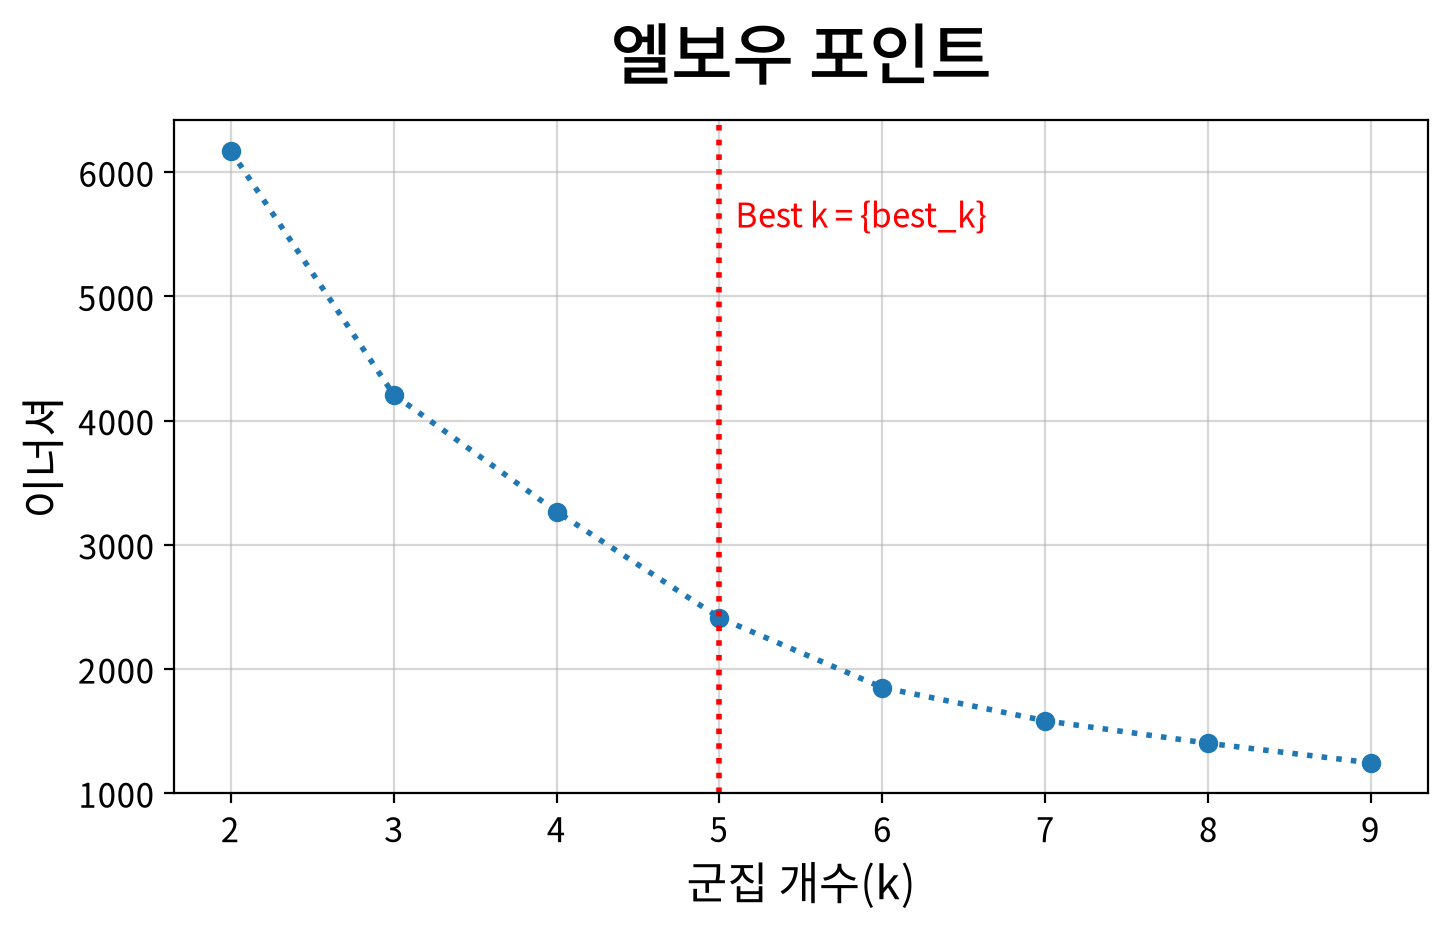

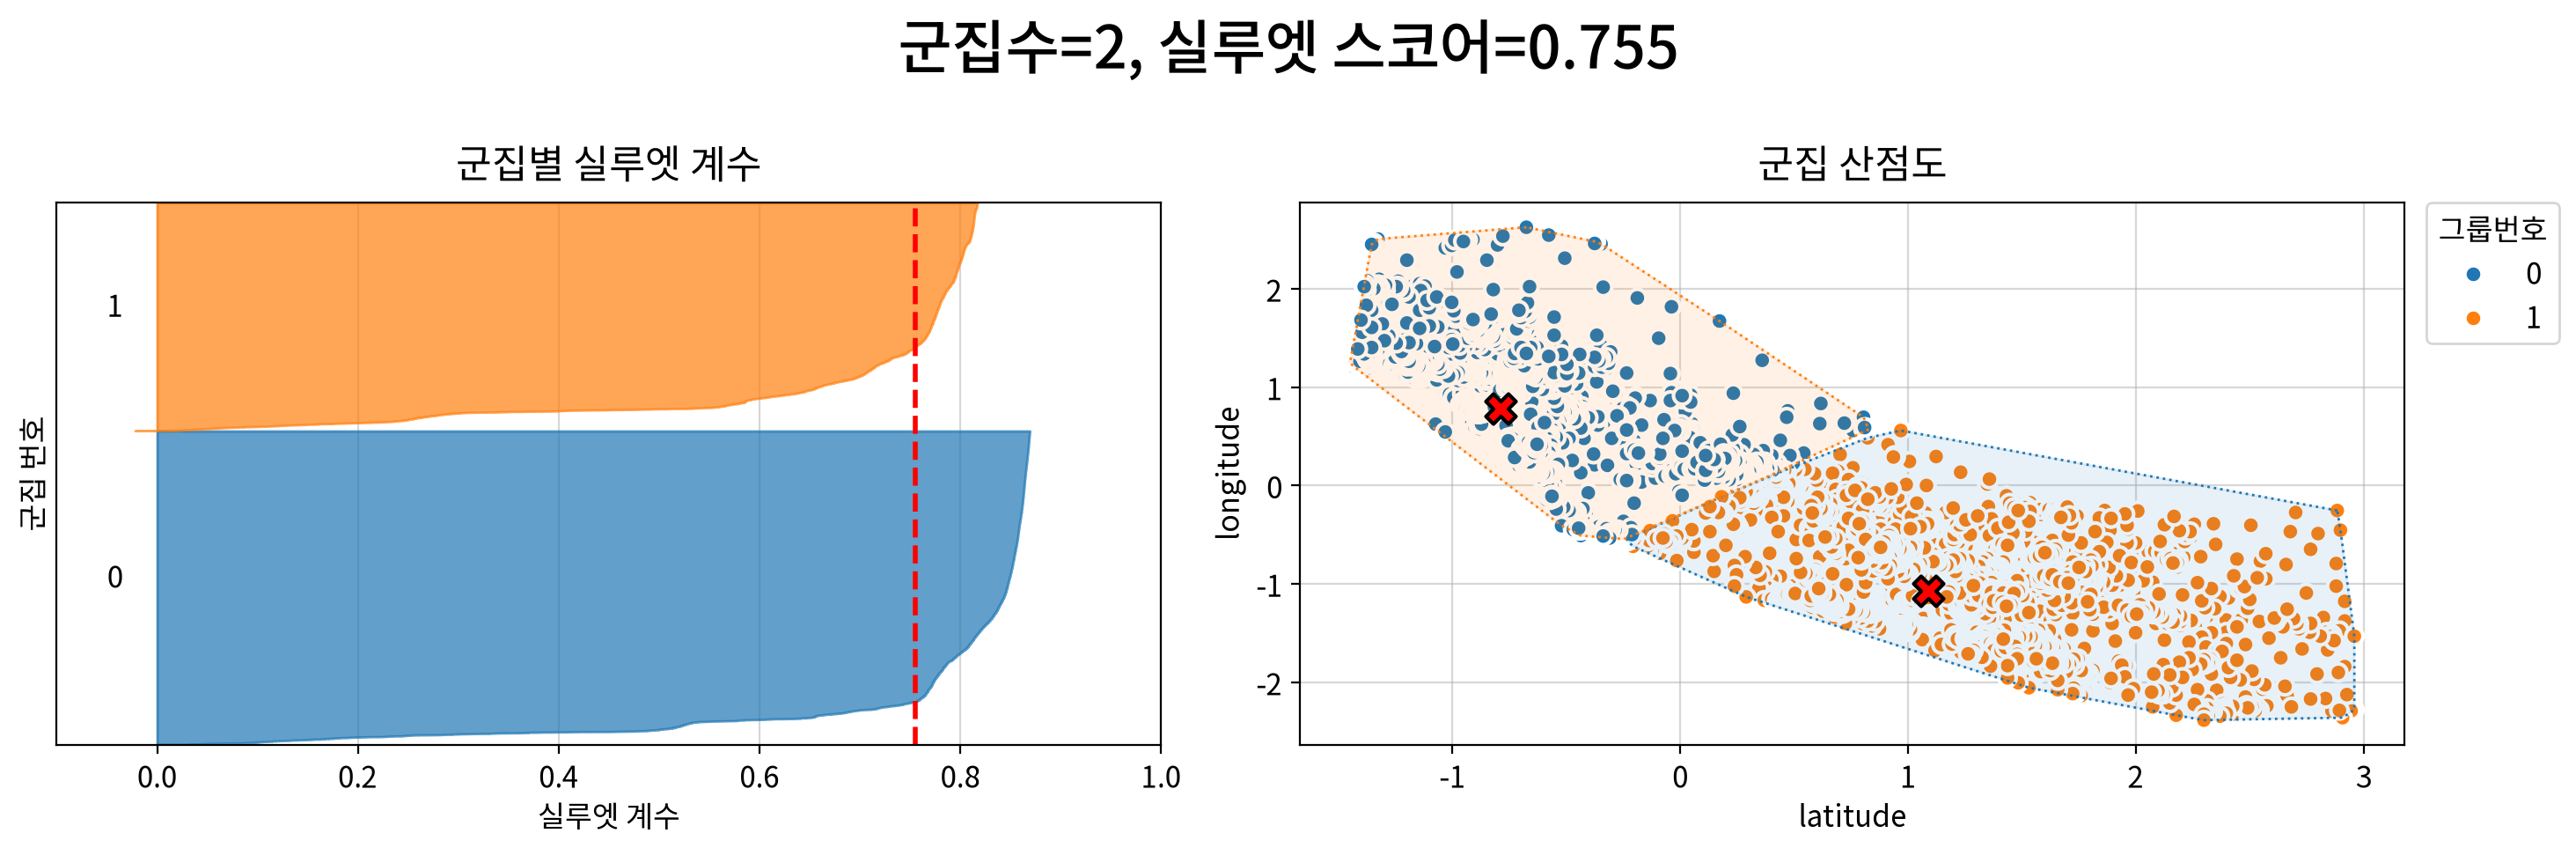

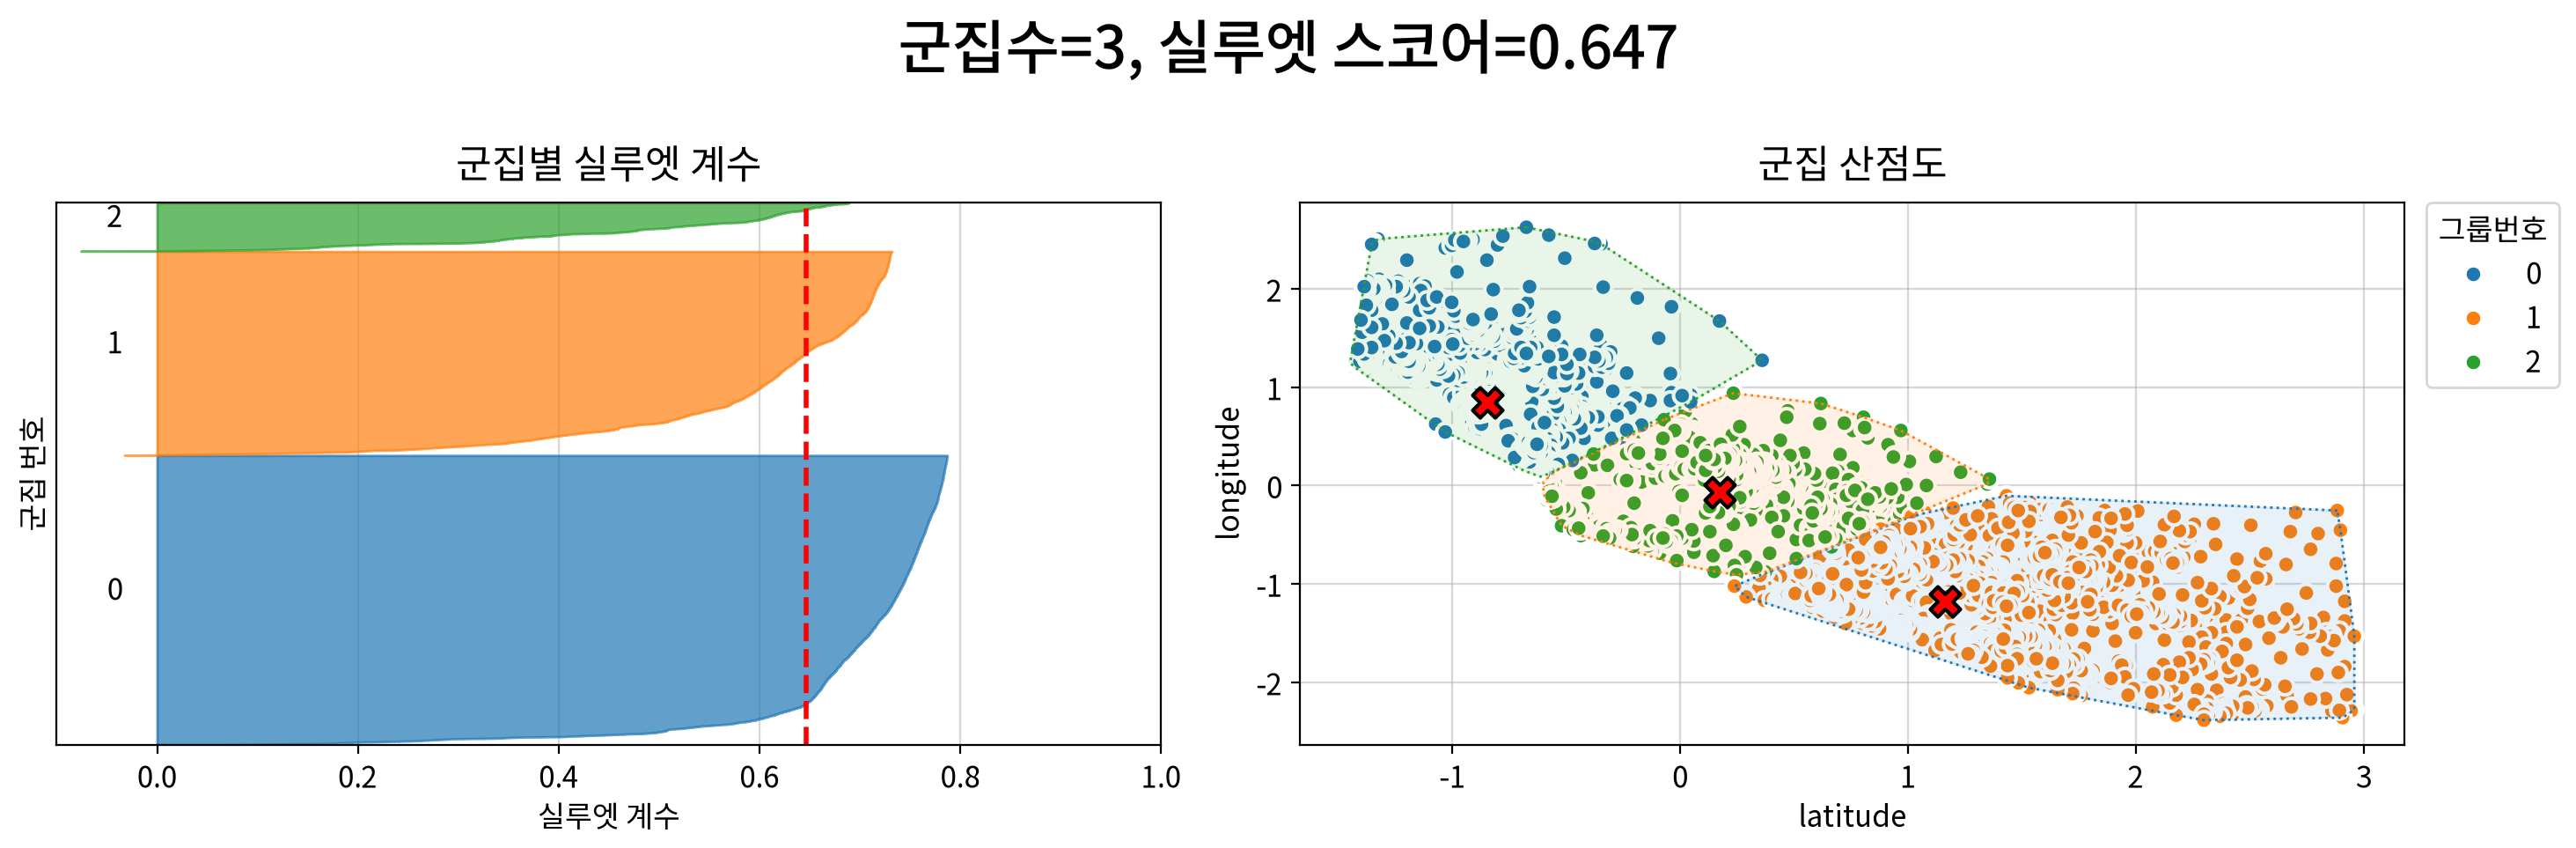

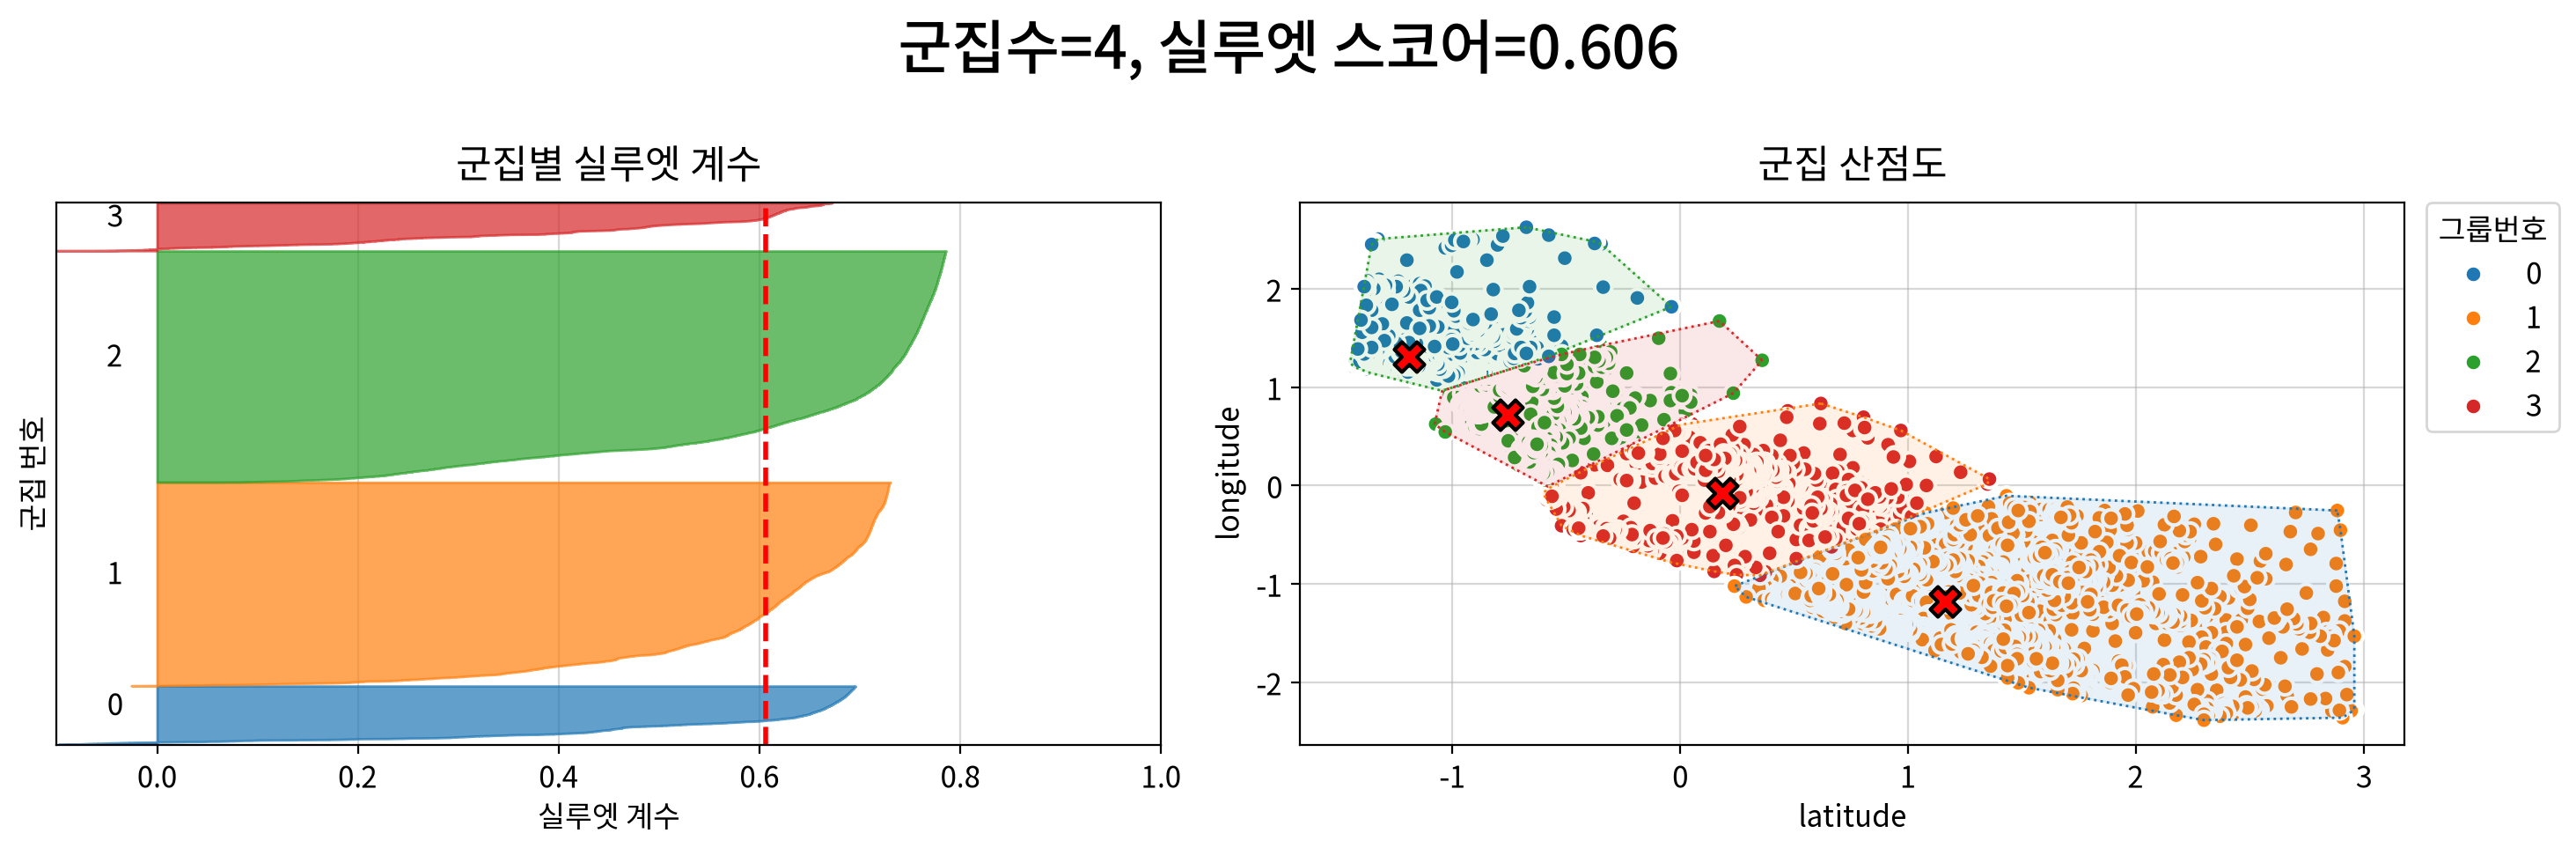

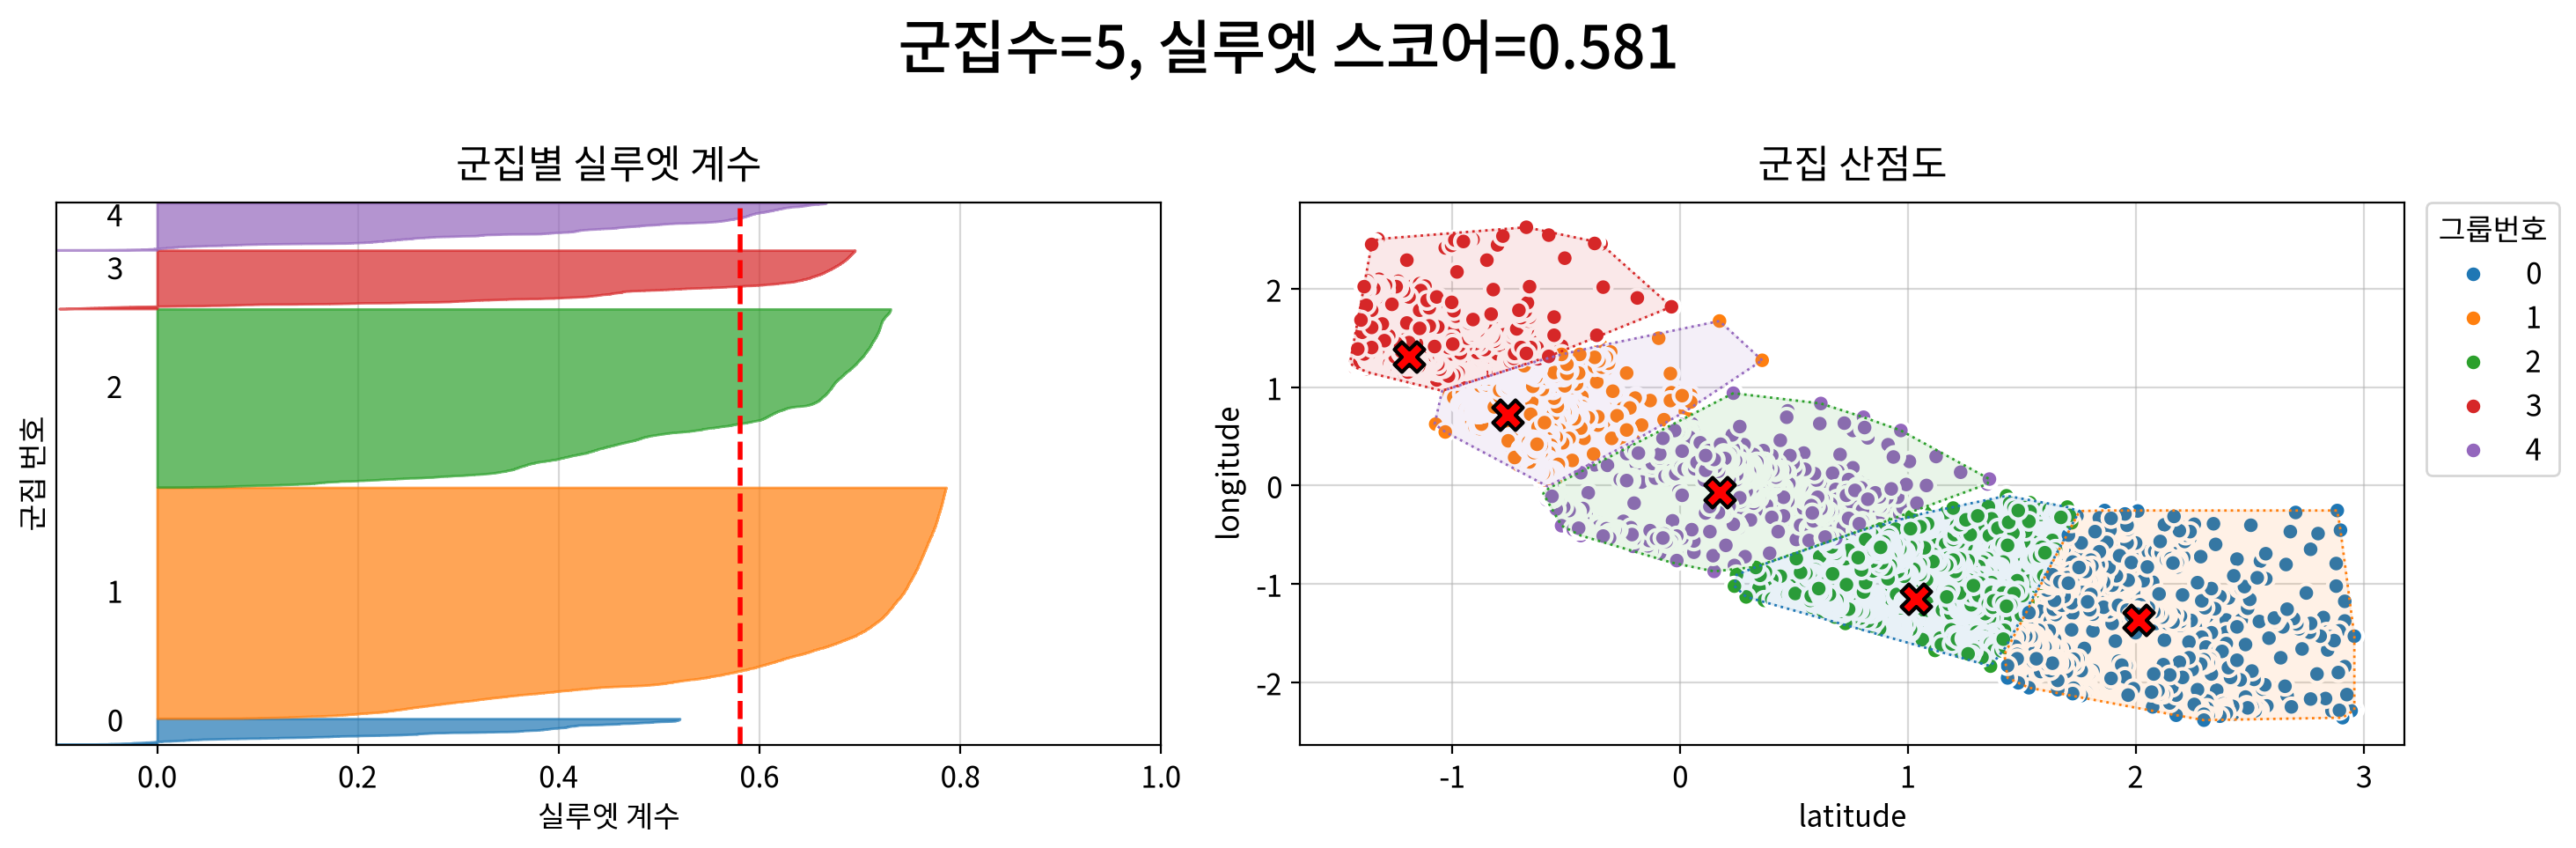

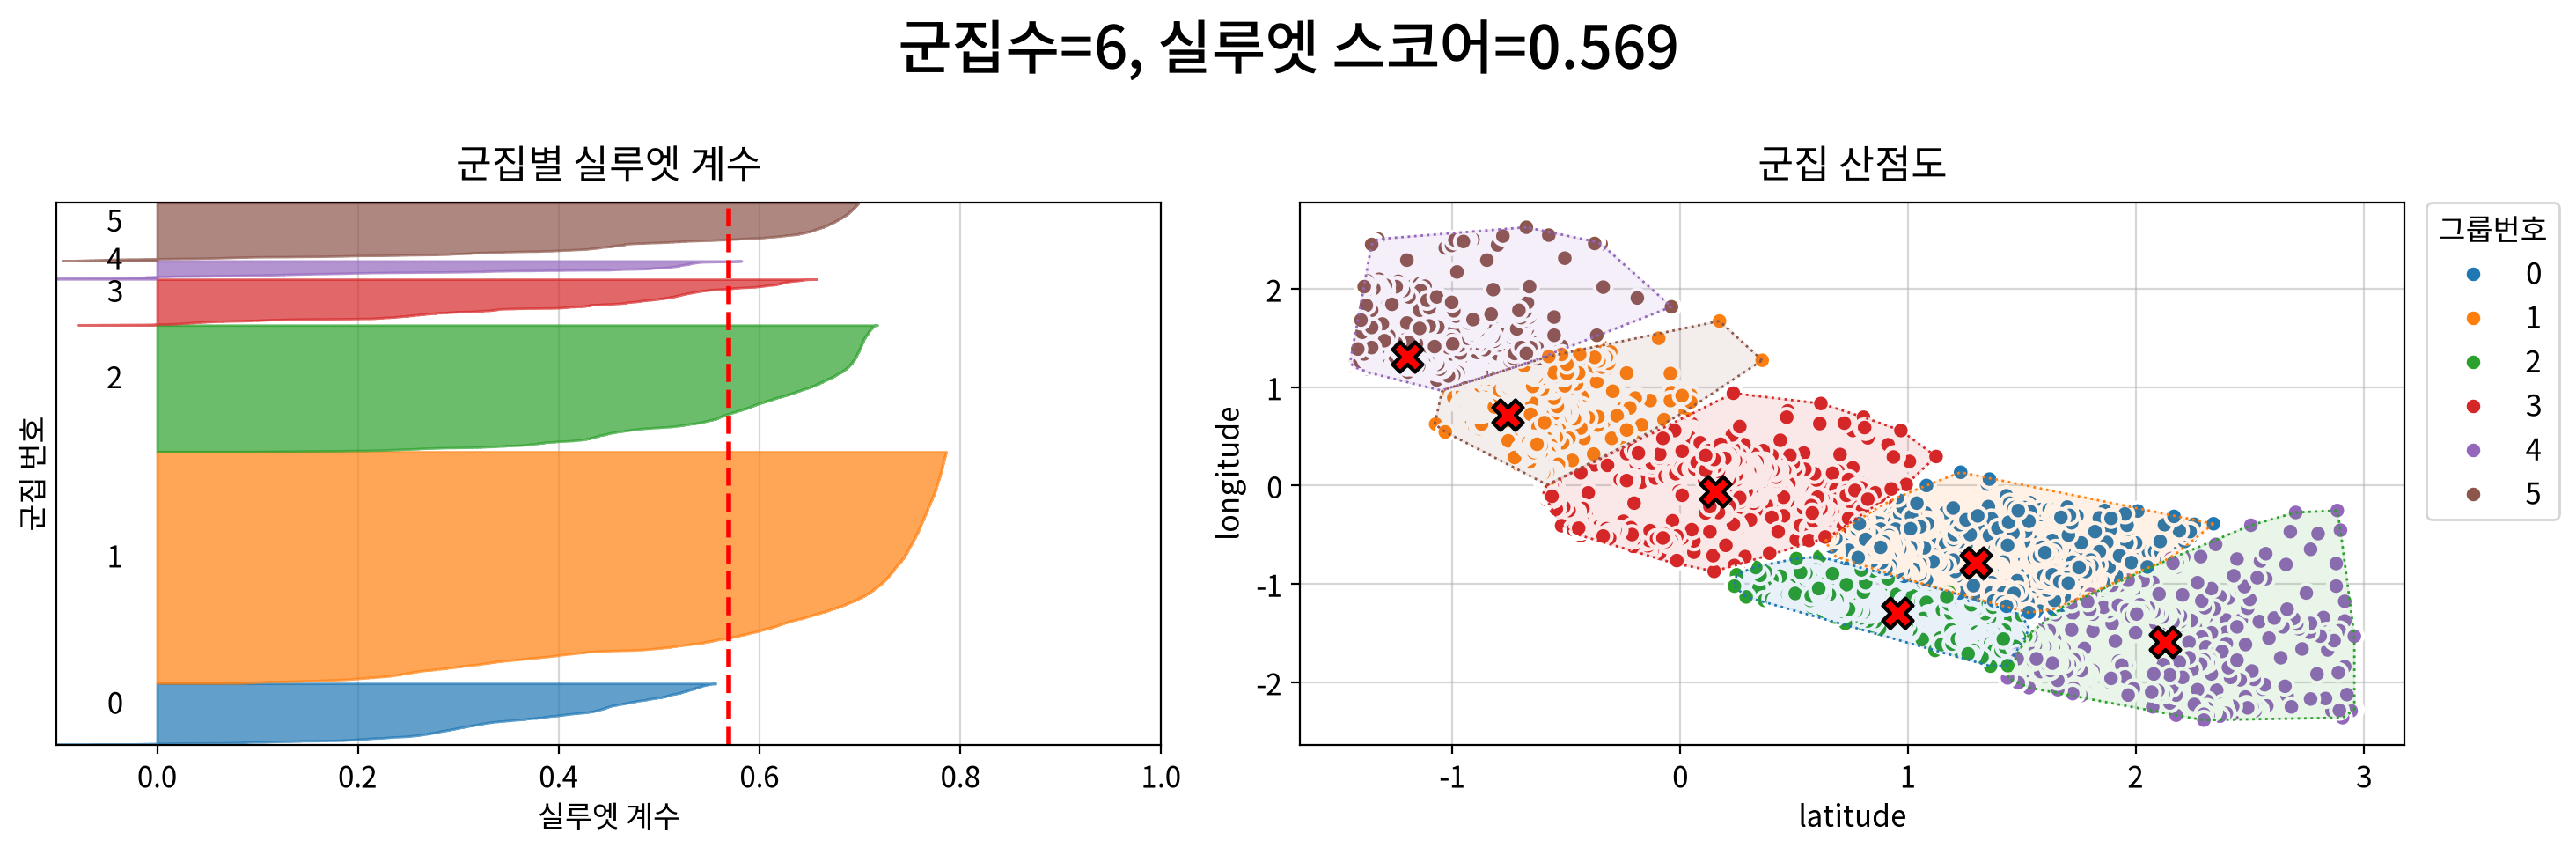

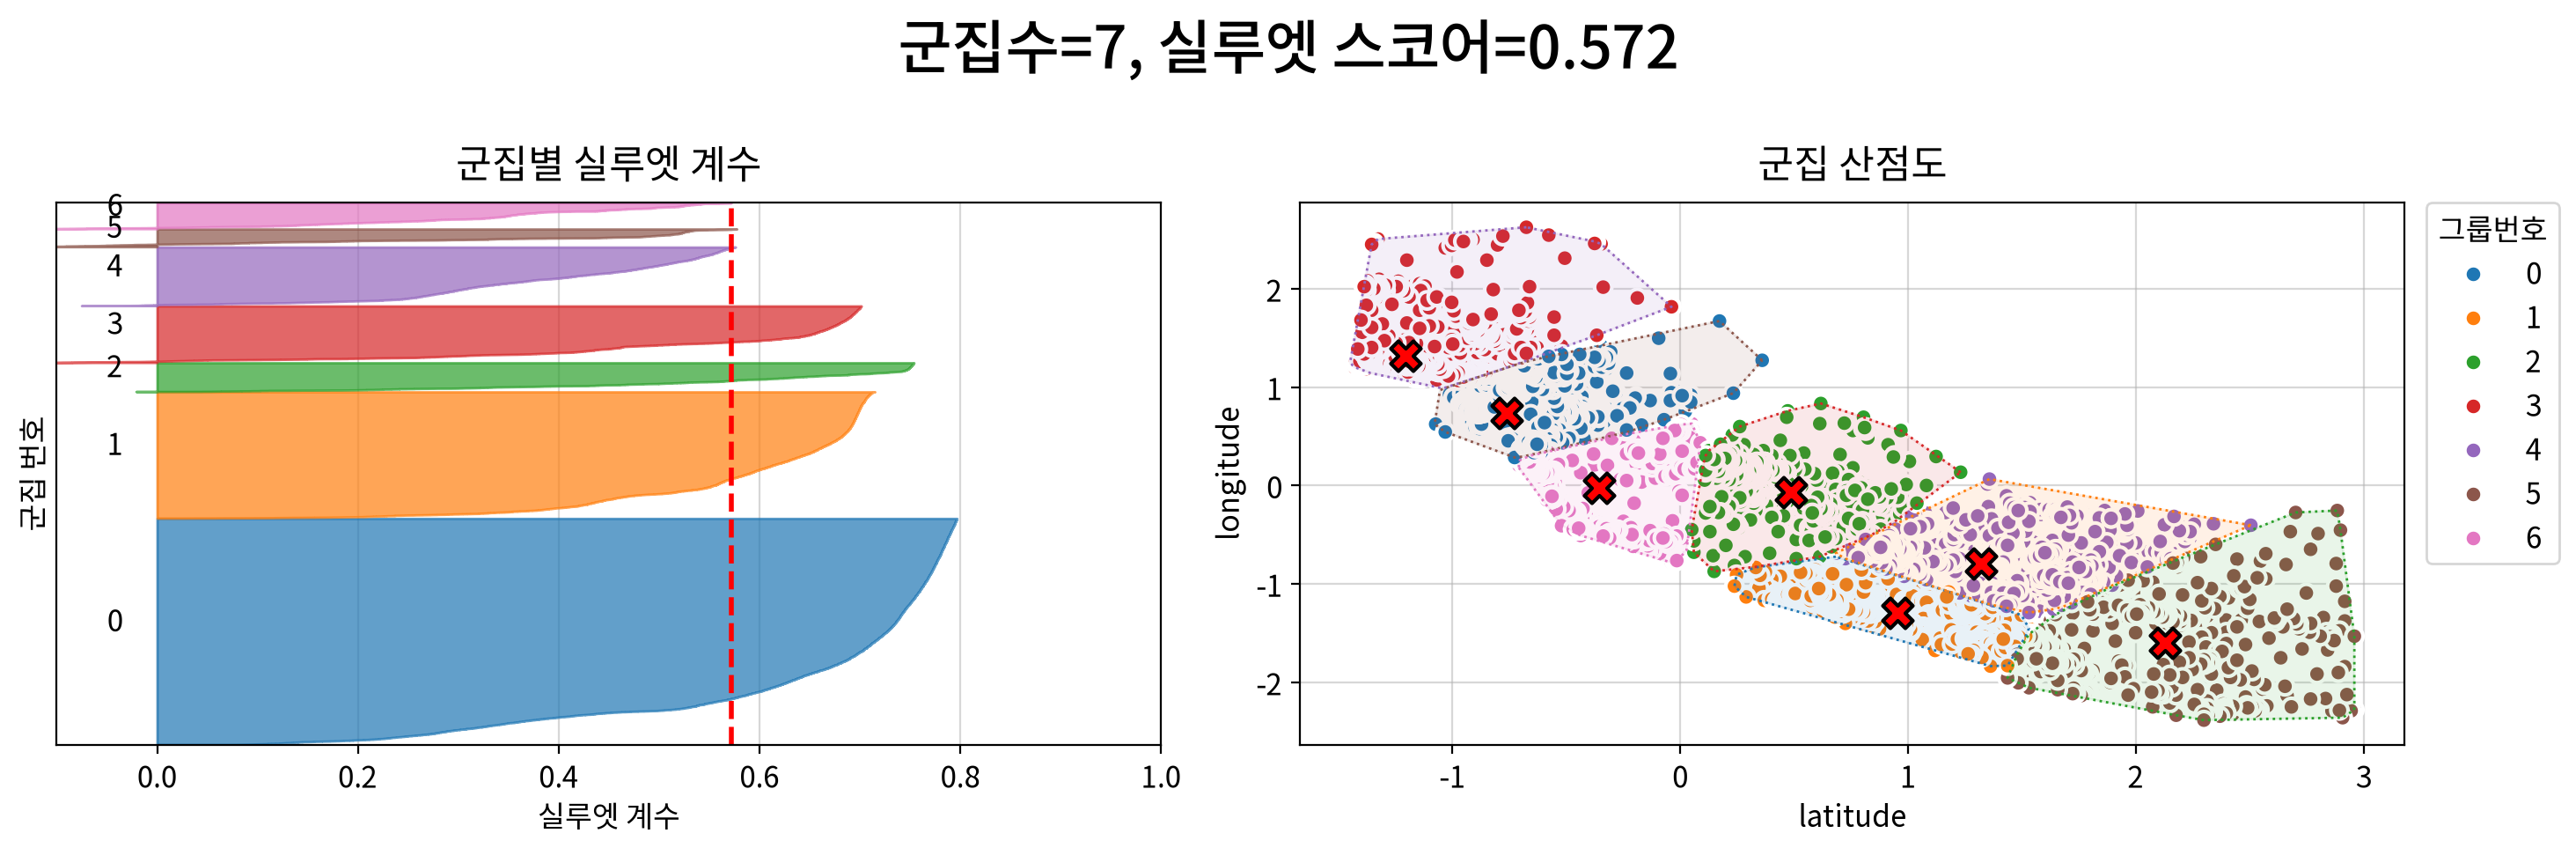

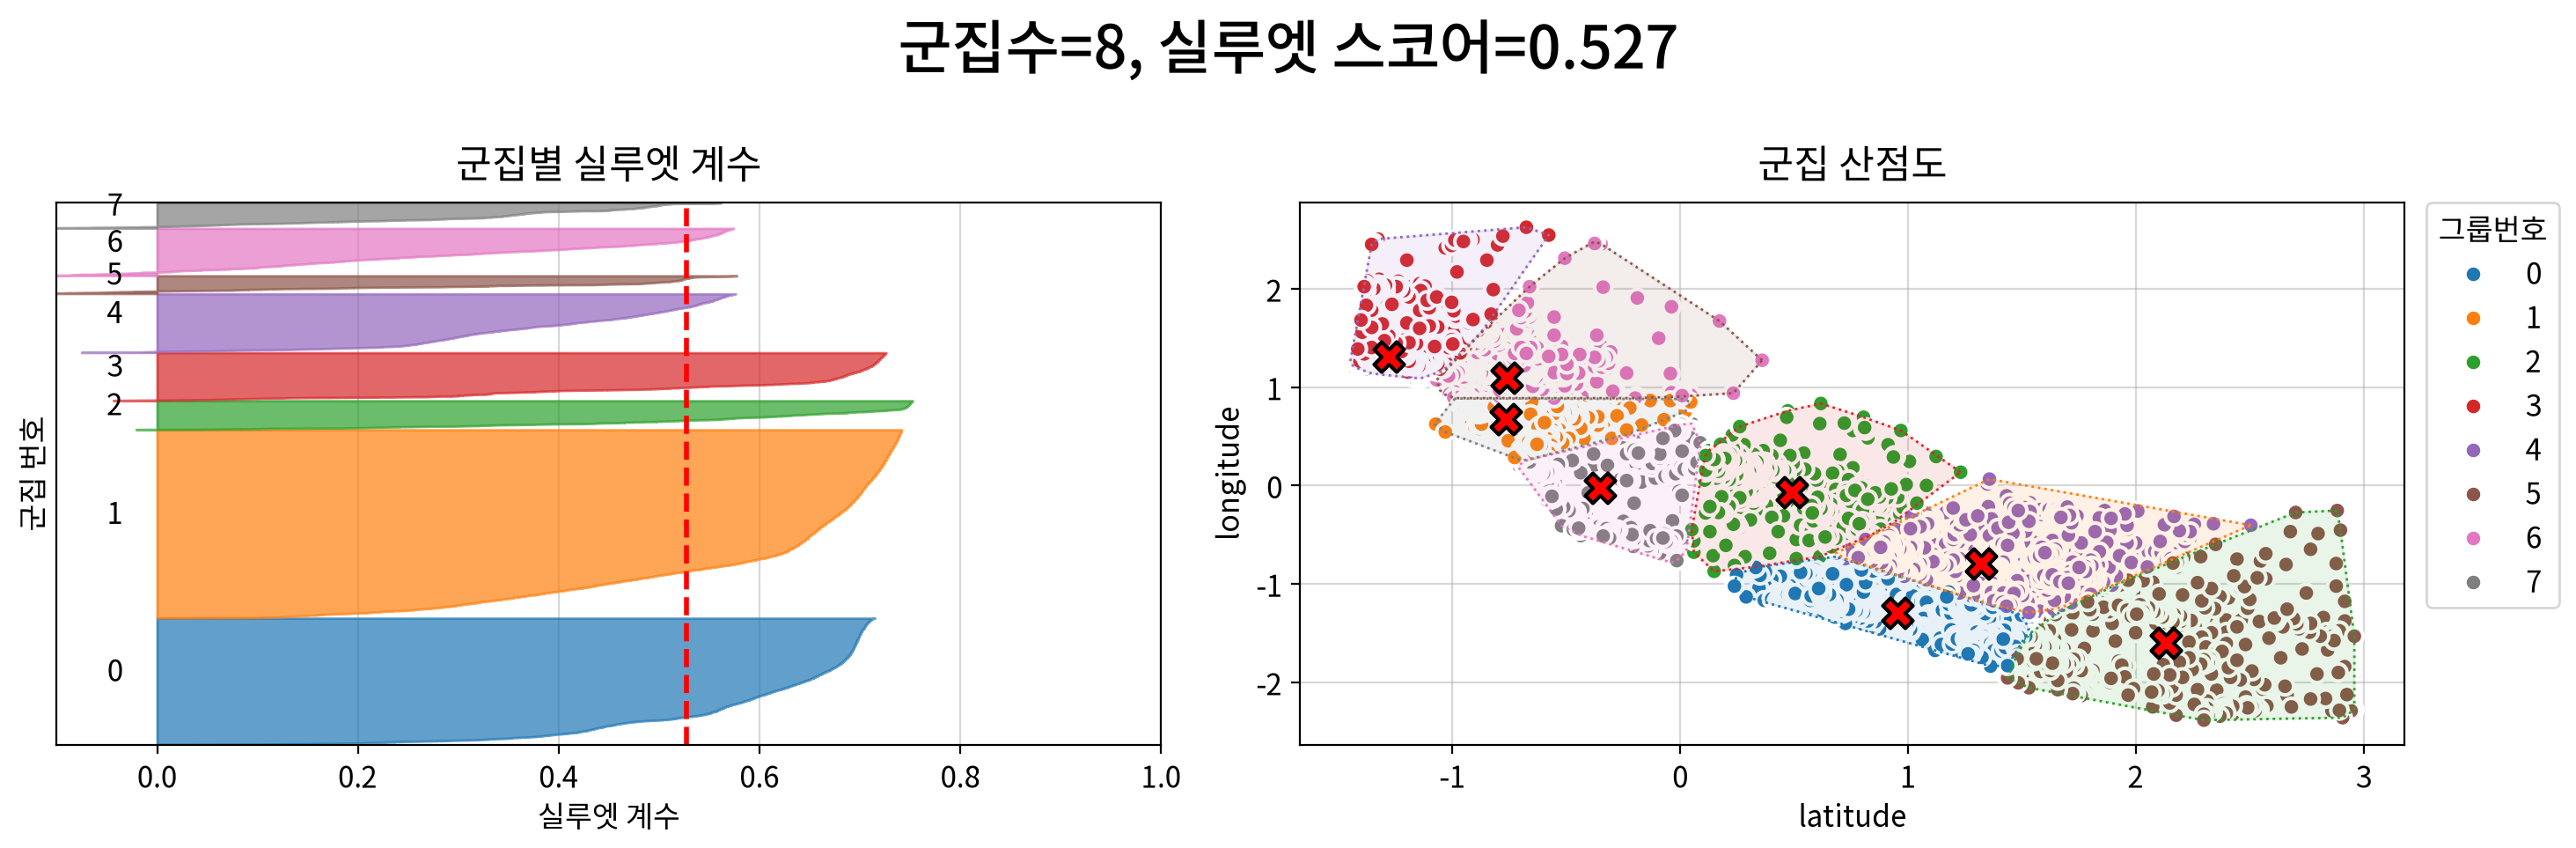

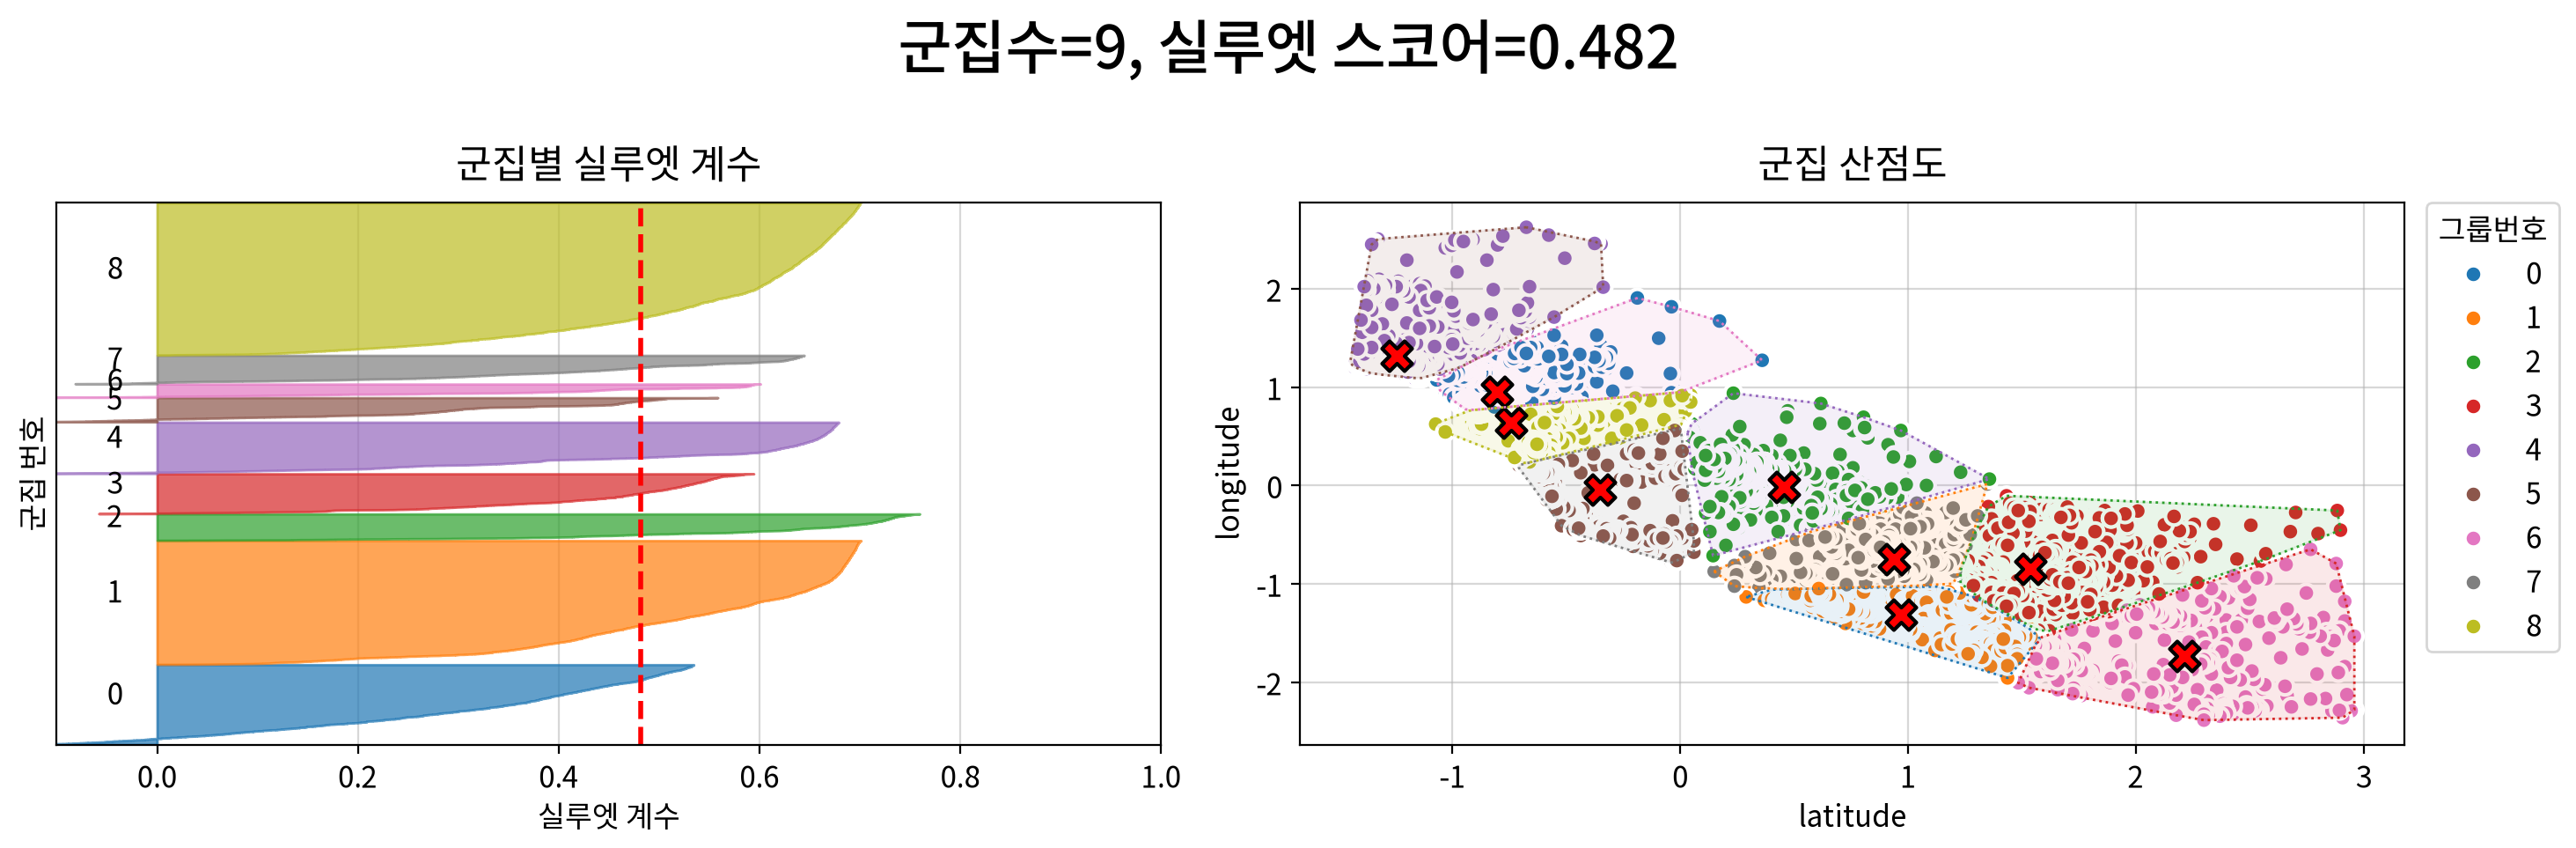

[1단계] 엘보우 포인트: k = 5 (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수: k = 2 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다
 . k = 5 : 균형지수 0.0075(스코어 0.5806, 두께비 8.9162)
 . k = 2 : 균형지수 0.4318(스코어 0.755, 두께비 1.3762)
------------------------------------------------------------
 >>> 최종선택 : k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한번 더 확인할 것)


In [18]:
final_k, _ = my_cluster.best_k(df, klist=list(range(2, 10)), 
                               columns=['latitude', 'longitude'],
                               plot_each=True, width=740, height=480)   


## #05. 공간특성 반영
> 분석가의 합리적인 판단이 필요합니다.

### 1. 군집 수(k) 결정 → 최종 군집 수 선정 (k=5)

**✗ k=2 양분화의 한계**
- 단순성 문제: 단 2개 군집 = "고가지역 vs 저가지역" 이분화에 불과
- 지역적 다양성 미반영: 검정/초록 두 덩어리만 나뉘어, 실제 캘리포니아 주택시장의 복잡한 지역 특성 반영 불가
- 파생변수 유용성 부족: 공간 특성 파생변수로 쓰기엔 정보량이 매우 제한적

**✓ k=5의 현실성**
- 엘보우 일치: 이너셔 감소 곡선의 꺾이는 지점과 일치 → "충분한 분할"
- 실루엣 점수 타당성: **0.581** (k=2의 0.755보다 낮지만, 0.5 이상으로 중간 이상 품질)
- 실질적 해석 가능성: 주택시장을 5개의 지리적·경제적 특성으로 분화 가능

### 📝 최종 선정: k=5 근거

| 절충점 | 도메인 타당성 | 파생변수 활용성 | 엘보우 일치 |
|---|---|---|---|
| 통계 품질(0.581)과 유용성 | 캘리포니아 지역 다양성 반영 | 정보손실 적고 해석 가능성 높음 | 통계적 근거 동시 확보 |

> "k=2는 너무 단순, k≥6은 점수 개선 미미 → **k=5가 가장 균형 잡힌 선택**"

### 2. 최종 군집 모형 적합 

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95            -1.45~2.96
longitude      -124.35 ~ -114.31            -2.39~2.63


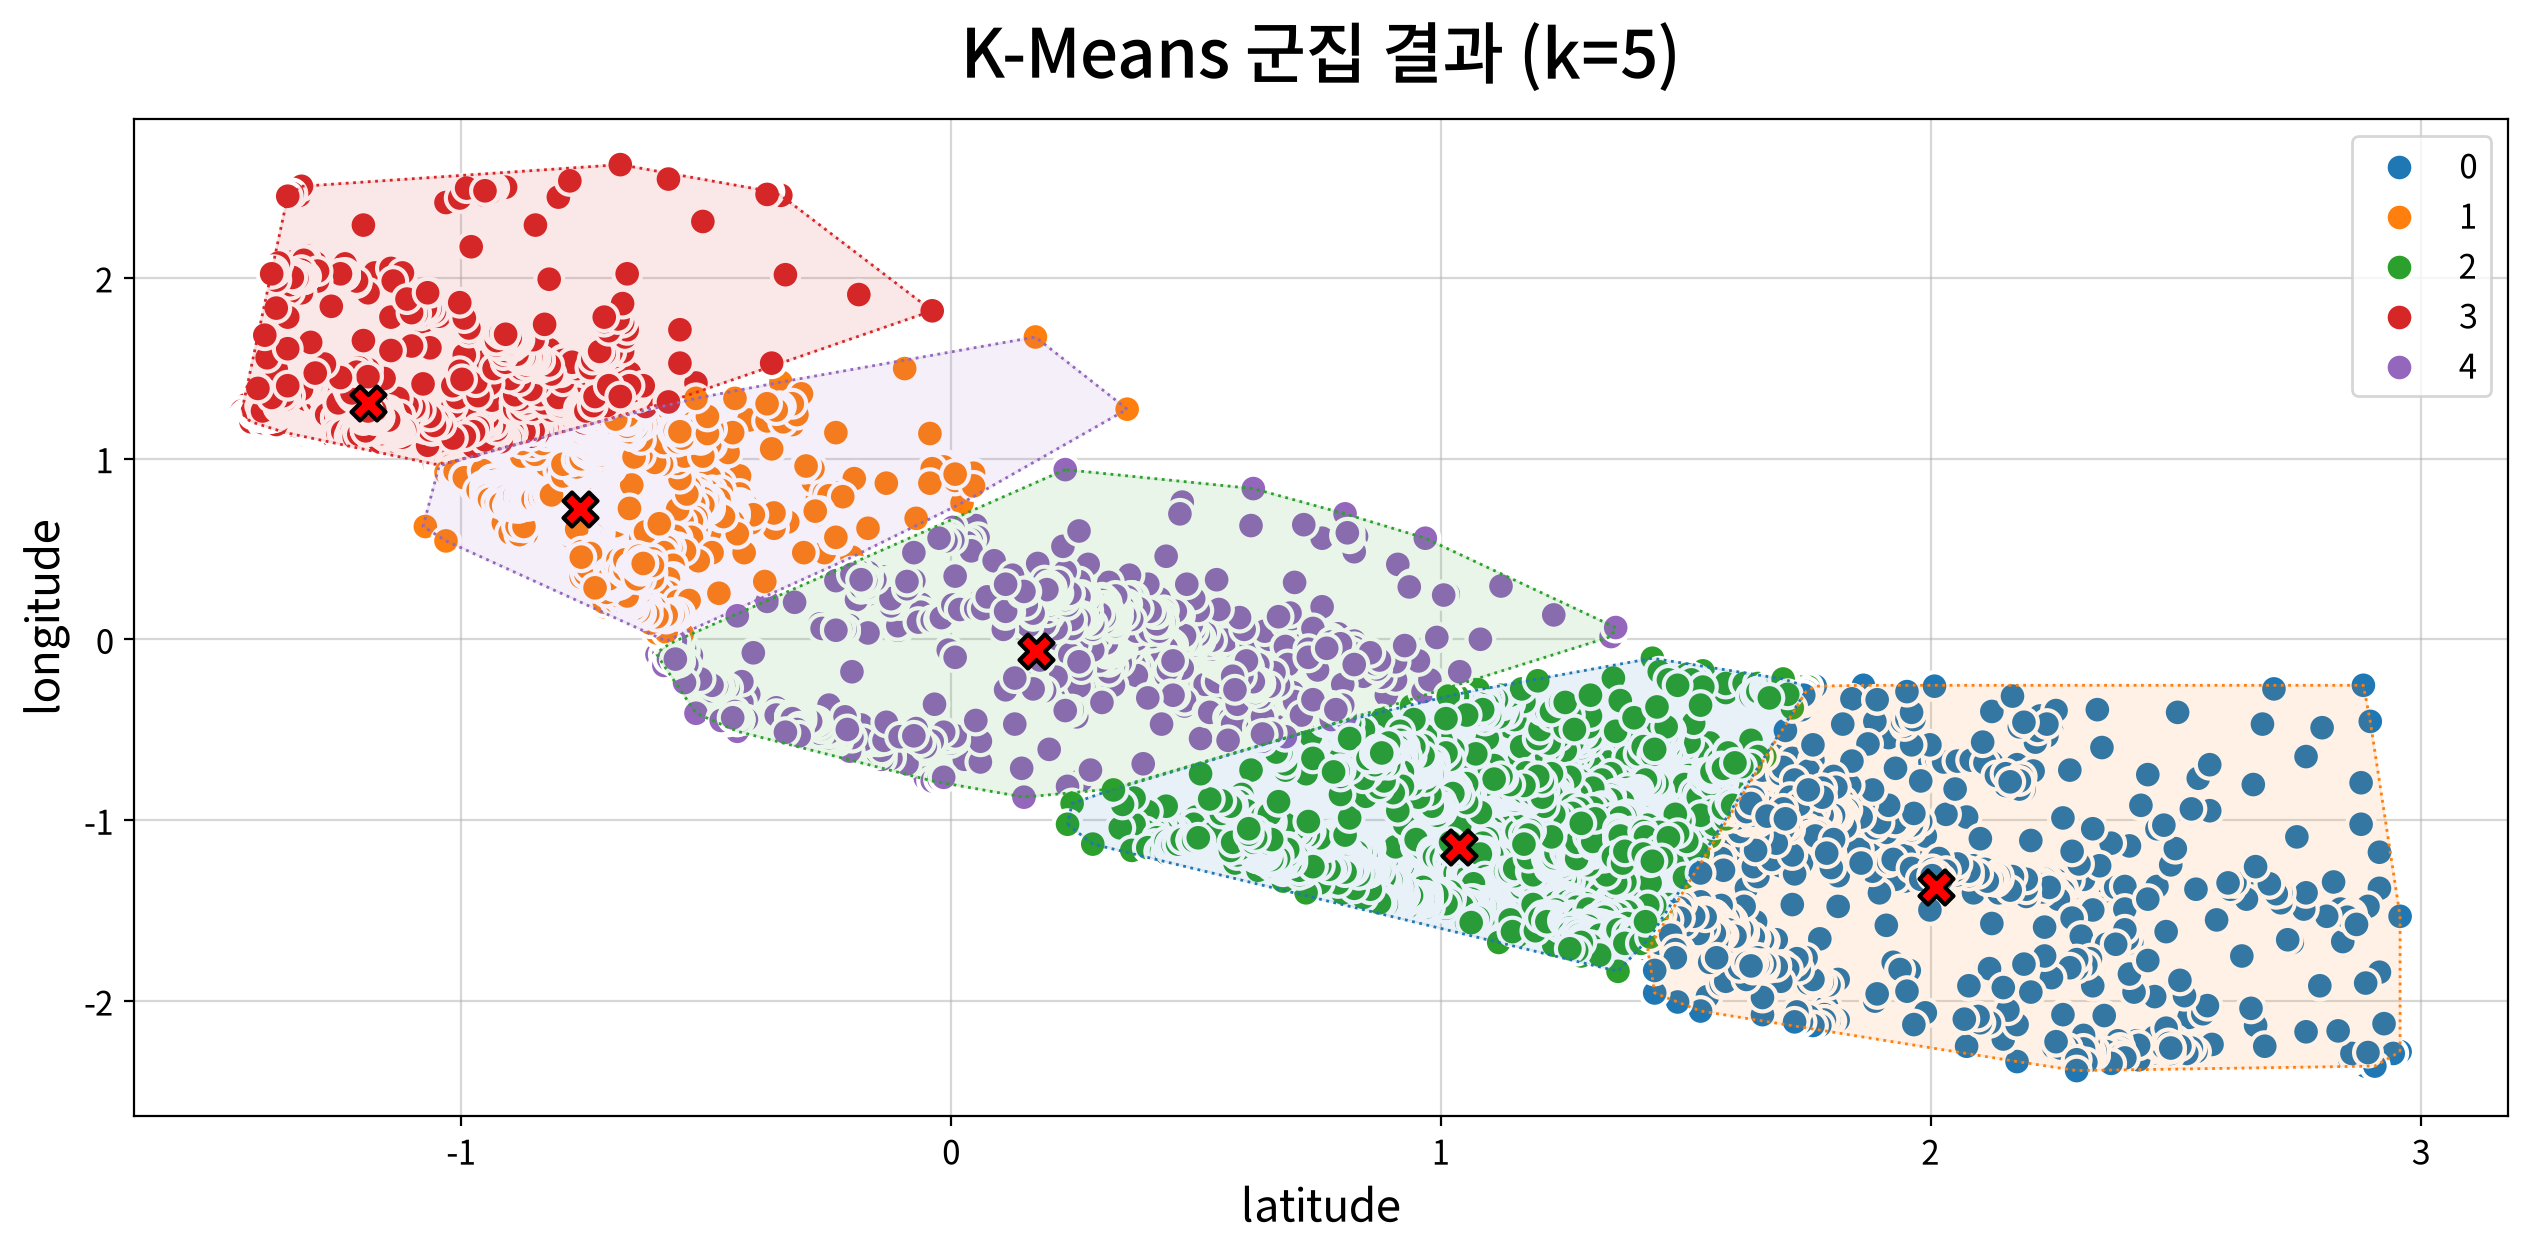

,latitude,longitude,그룹번호
0,1.052,-1.327,2
1,1.042,-1.322,2
2,1.038,-1.332,2
3,1.038,-1.337,2
4,1.038,-1.337,2
...,...,...,...
20428,1.801,-0.758,0
20429,1.805,-0.818,0
20430,1.777,-0.823,0
20431,1.777,-0.873,0


In [19]:
final_k = 5
estimator, cdf, _ = my_cluster.kmeans(df, k=final_k, 
                                      columns=['latitude', 'longitude'])    

cdf

### 3. 공간 특성 반영 파생변수 추가 


In [20]:
df["special_cluster"] = cdf["그룹번호"].astype("category")

# #02와 같은 규칙으로 의미를 등록하고 목록 이름을 붙인다
# -> #04의 검증 반복문이 이 이름을 그대로 받아 쓴다. 
column_means["special_cluster"] = "위경도 기반 공간 군집"
spatial_cols = ["special_cluster"]

df[['longitude', 'latitude', 'ocean_area', 'special_cluster']].head()

,longitude,latitude,ocean_area,special_cluster
0,-122.230,37.880,COASTAL,2
1,-122.220,37.860,COASTAL,2
2,-122.240,37.850,COASTAL,2
3,-122.250,37.850,COASTAL,2
4,-122.250,37.850,COASTAL,2


## #06. 공간자기상관 — 인접한 구역끼리 집값이 닮았다

### □ Moran's I 0.790 (p=0.001) — 강한 양의 공간자기상관

| 공간가중치 행렬 | Moran's I | p-value |
|---|---|---|
| Queen 인접 | 0.790 | 0.001 |
| Rook 인접 | 0.790 | 0.001 |

**이웃의 정의를 바꿔도 결론이 같다**
- Queen·Rook 두 기준이 소수점 셋째 자리까지 일치
- 특정 이웃 정의에 기댄 결과가 아니다

**좌표계 — 거리 계산이 가능한 좌표계로 변환**
- 위·경도(도 단위)는 거리 계산에 쓸 수 없다
- EPSG:5186으로 변환 후 인접 관계 산출

---

## #07. 공간 군집 — 좌표 2개가 5개 시장 권역이 된다

### □ 위·경도만으로 K-Means k=5 — 집값 분산의 12.6%를 단일 변수로 설명

| 군집 | 건수 | 평균 집값 | 해당 권역 |
|---|---|---|---|
| 1 | 8,729 | 230,623$ | 남부 (LA 권역) |
| 2 | 6,736 | 224,716$ | 중북부 (베이 권역) |
| 3 | 2,211 | 177,072$ | 최남부 (샌디에이고 권역) |
| 4 | 1,778 | 121,984$ | 중부 내륙 (센트럴밸리) |
| 0 | 979 | 93,639$ | 북부 내륙 |

**k=5 선정 — 점수가 아니라 쓸모**
- 실루엣 최고는 k=2(0.755)지만 "고가/저가" 이분화에 그침
- k=5는 엘보우와 일치하고 실루엣 0.581로 기준선(0.5) 위

**검정 결과**
- Welch F=2,299.2 (p<0.001), np2=0.126 (Medium)
- 사후검정 10쌍 전부 유의 — 5개 군집이 서로 다른 가격대

# 3-4. 파생변수 검증 

## # 검증 설계 — 원본과 같은 잣대

### □ 만들었다는 것과 쓸 만하다는 것은 다른 문제
◎ 원본 데이터와 같은 방식으로 검증 후 채택 여부를 결정해야 한다.

| 순서 | EDA 단계 | 검증 단계 |
|---|---|---|
| ① | 단변량 분석 — 분포·왜도·이상치 | 파생변수 분포 재점검 |
| ② | 이변량 분석 — 상관 / T-Test / ANOVA | 파생변수 설명력 검증 |
| ③ | 다변량 분석 (필요한 경우) | 상관분석 (+ 이원분산분석 및 사후검정) |
| ④ | 종합 판단 | 채택·후보·보류 판정 |

**검증 대상**
- 연속형 파생 5종
- 범주형 파생 4종

**원칙**
- 원본에 적용했던 잣대를 그대로 적용

> 새로 만든 변수에 검증을 생략하면 → 검증 없는 변수로 모델을 만드는 셈

## #06. 파생변수 검증 
### 1. 검증 대상 분류 
검증 대상은 새로 만든 파생변수 (원본 변수는 EDA에서 이미 확인함)

In [21]:
# 연속형 파생변수 
derived_continuous = ['rooms_per_person', 'rooms_per_household',
                      'bedrooms_per_room', 'population_per_household', 'income_per_person']

# 범주형 파생변수 
derived_nominal = ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']    

print("연속형 파생: ", derived_continuous)
print("범주형 파생: ", derived_nominal)

연속형 파생:  ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']
범주형 파생:  ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


### 2. 연속형 기술 통계량 

In [22]:
derived_num_desc = my_qtcheck.numerical_summary(df, columns=derived_continuous)
derived_num_desc.T

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
count,20433.000,20433.000,20433.000,20433.000,20433.000
mean,1.978,5.431,0.213,3.072,1.409
std,1.150,2.483,0.058,10.438,0.755
min,0.003,0.846,0.100,0.692,0.008
25%,1.524,4.441,0.175,2.429,0.870
50%,1.938,5.231,0.203,2.818,1.296
75%,2.297,6.052,0.240,3.282,1.777
max,55.222,141.909,1.000,1243.333,7.550
rel_diff,0.021,0.038,0.049,0.090,0.087
rdiff_flag,similar,similar,similar,similar,similar


In [ ]:
# 전체 이상치 비율은 5% 미만으로 무시 가능한 수준 
# 로그 변환 필요 -> 이상치 완화 기대 가능 

### 3. 범주형 기술 통계량 
플래그와 병합된 범주, 군집분석 결과는 값의 종류가 2개인 범주형이므로 category 타입응로 변환해 요약한다. 

In [23]:
df = my_qtcheck.set_type(df, as_category=derived_nominal)

derived_cat_desc = my_qtcheck.categorical_summary(df, 
                                                  columns=derived_nominal, value_counts=False)
derived_cat_desc

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 20433 non-null  float64 
 1   latitude                  20433 non-null  float64 
 2   housing_median_age        20433 non-null  int64   
 3   total_rooms               20433 non-null  int64   
 4   total_bedrooms            20433 non-null  float64 
 5   population                20433 non-null  int64   
 6   households                20433 non-null  int64   
 7   median_income             20433 non-null  float64 
 8   median_house_value        20433 non-null  int64   
 9   ocean_proximity           20433 non-null  category
 10  rooms_per_person          20433 non-null  float64 
 11  rooms_per_household       20433 non-null  float64 
 12  bedrooms_per_room         20433 non-null  float64 
 13  population_per_household  20433 non-null  float64 
 14  i

,is_age_capped,is_income_capped,ocean_area,special_cluster
count,20433,20433,20433,20433
unique,2,2,2,5
top,0,0,COASTAL,1
freq,19168,20383,13937,8729


### 4. 단변량 분석 (연속형 파생변수)
원본 변수에 대한 EDA 과정과 마찬가지로 분포 모양과 로그 변환 여부를 판정한다. 

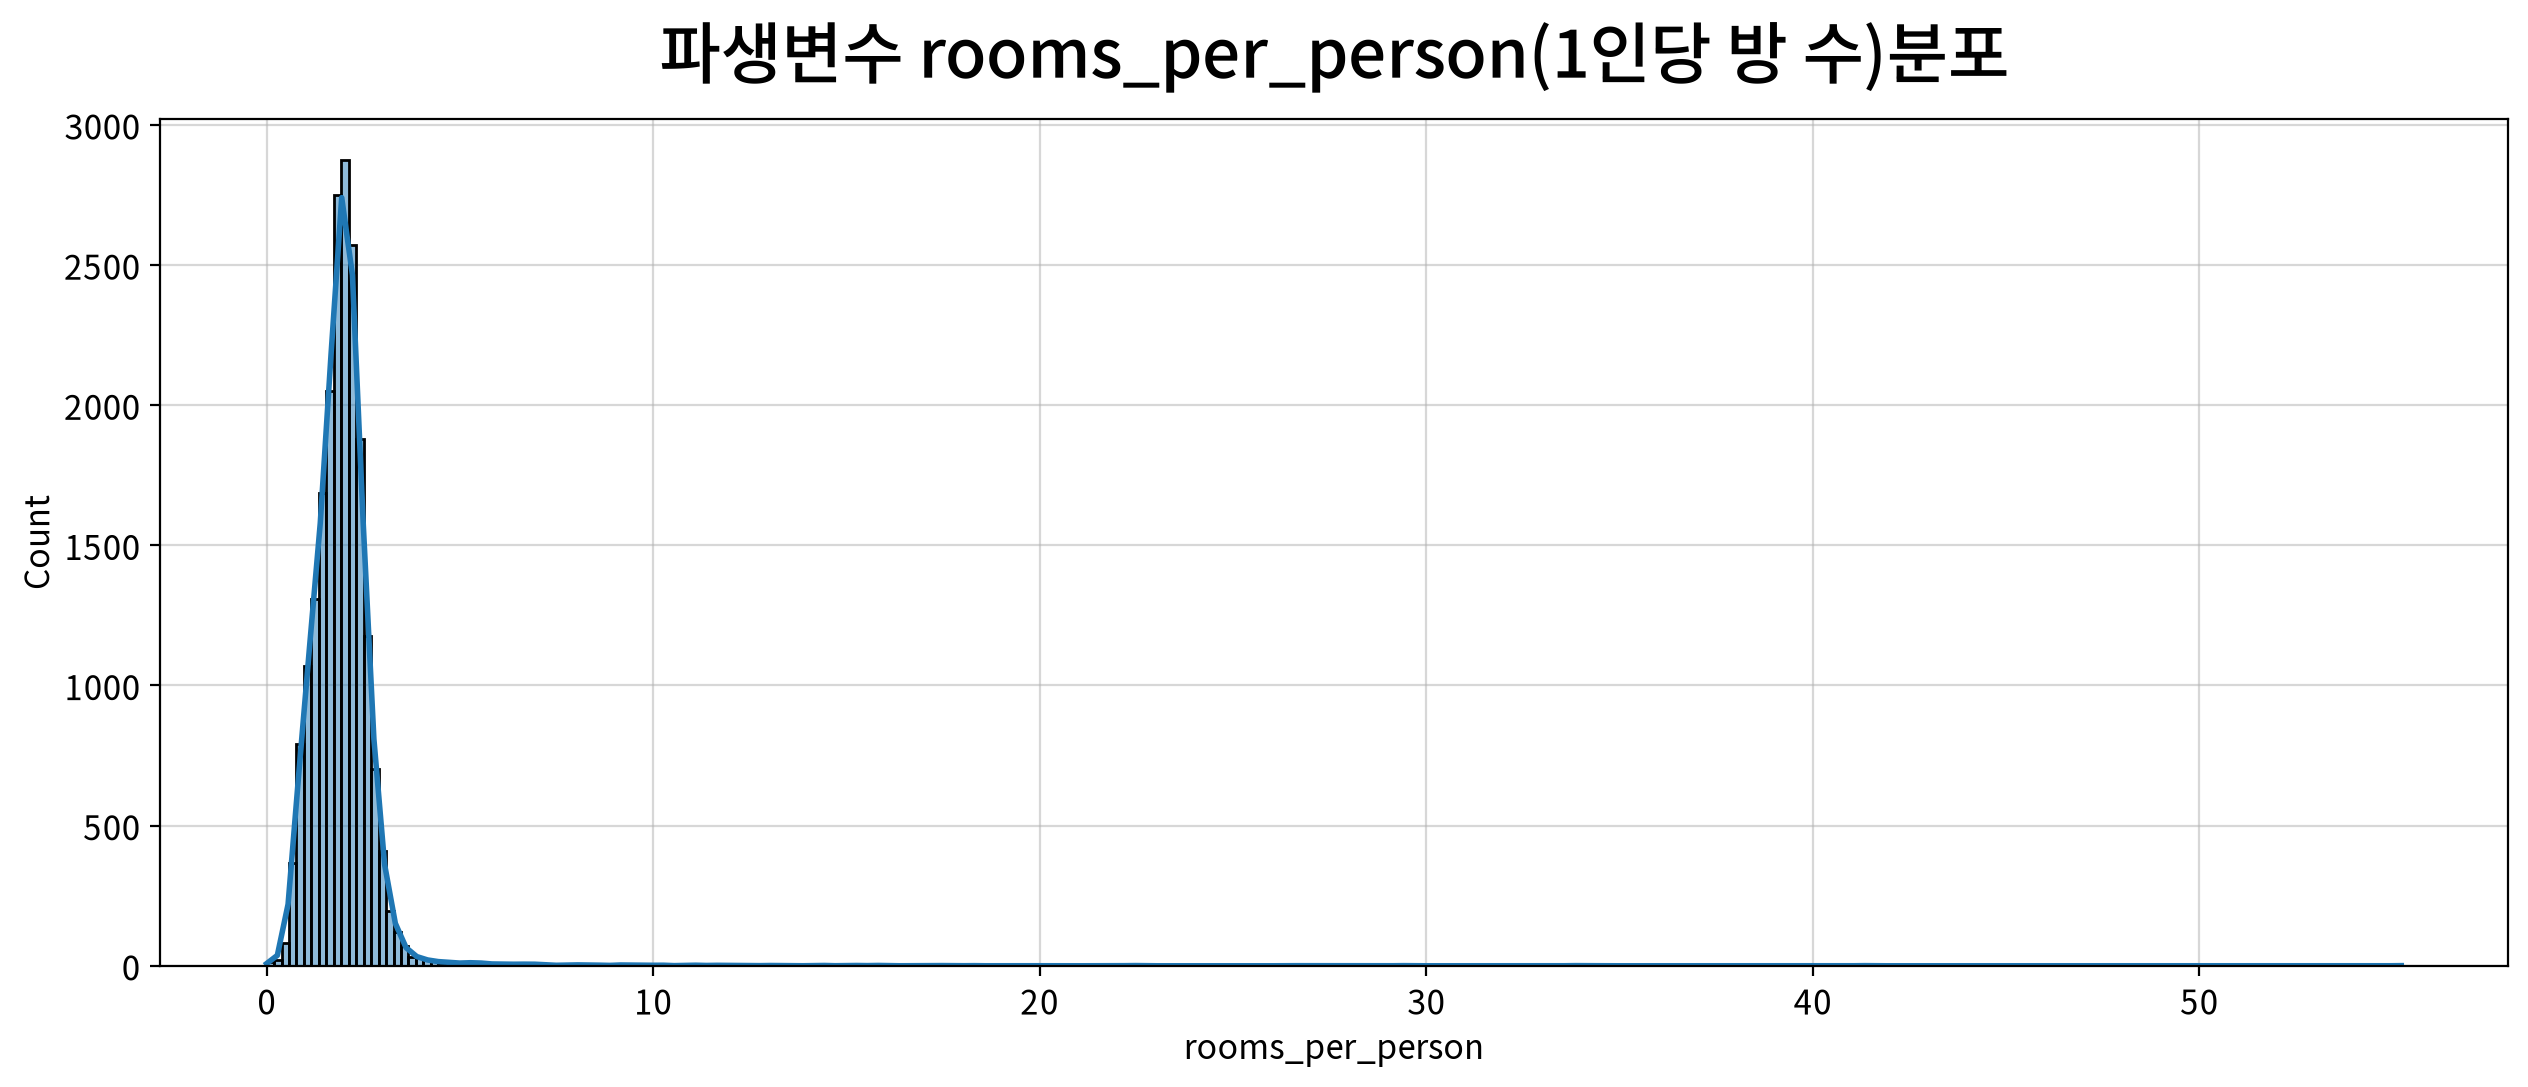

,rooms_per_person
count,20433.000
mean,1.978
std,1.150
min,0.003
25%,1.524
50%,1.938
75%,2.297
max,55.222
rel_diff,0.021
rdiff_flag,similar


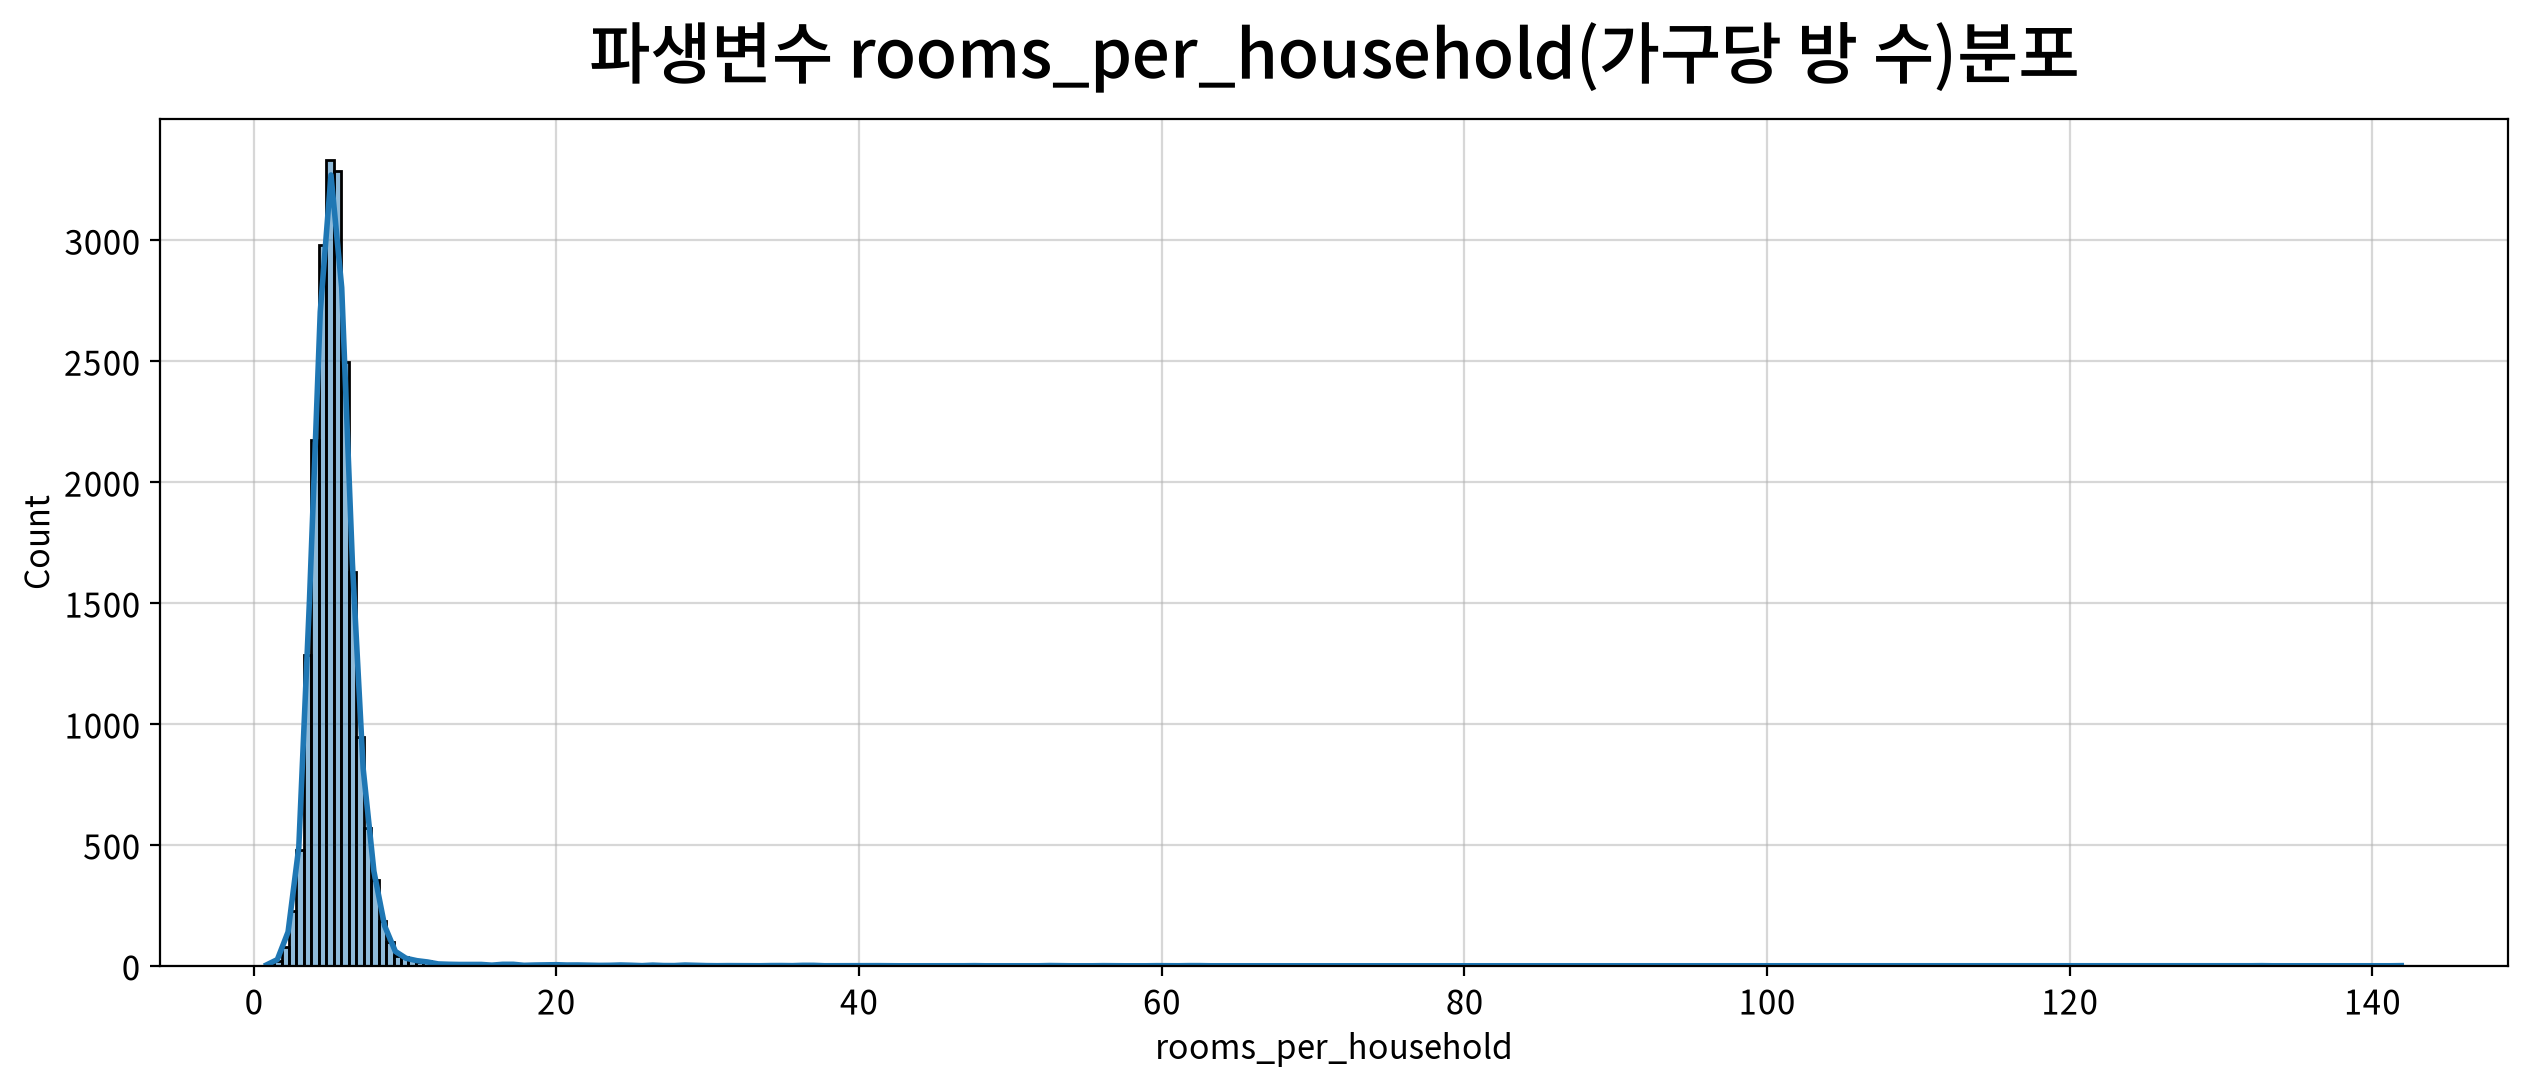

,rooms_per_household
count,20433.000
mean,5.431
std,2.483
min,0.846
25%,4.441
50%,5.231
75%,6.052
max,141.909
rel_diff,0.038
rdiff_flag,similar


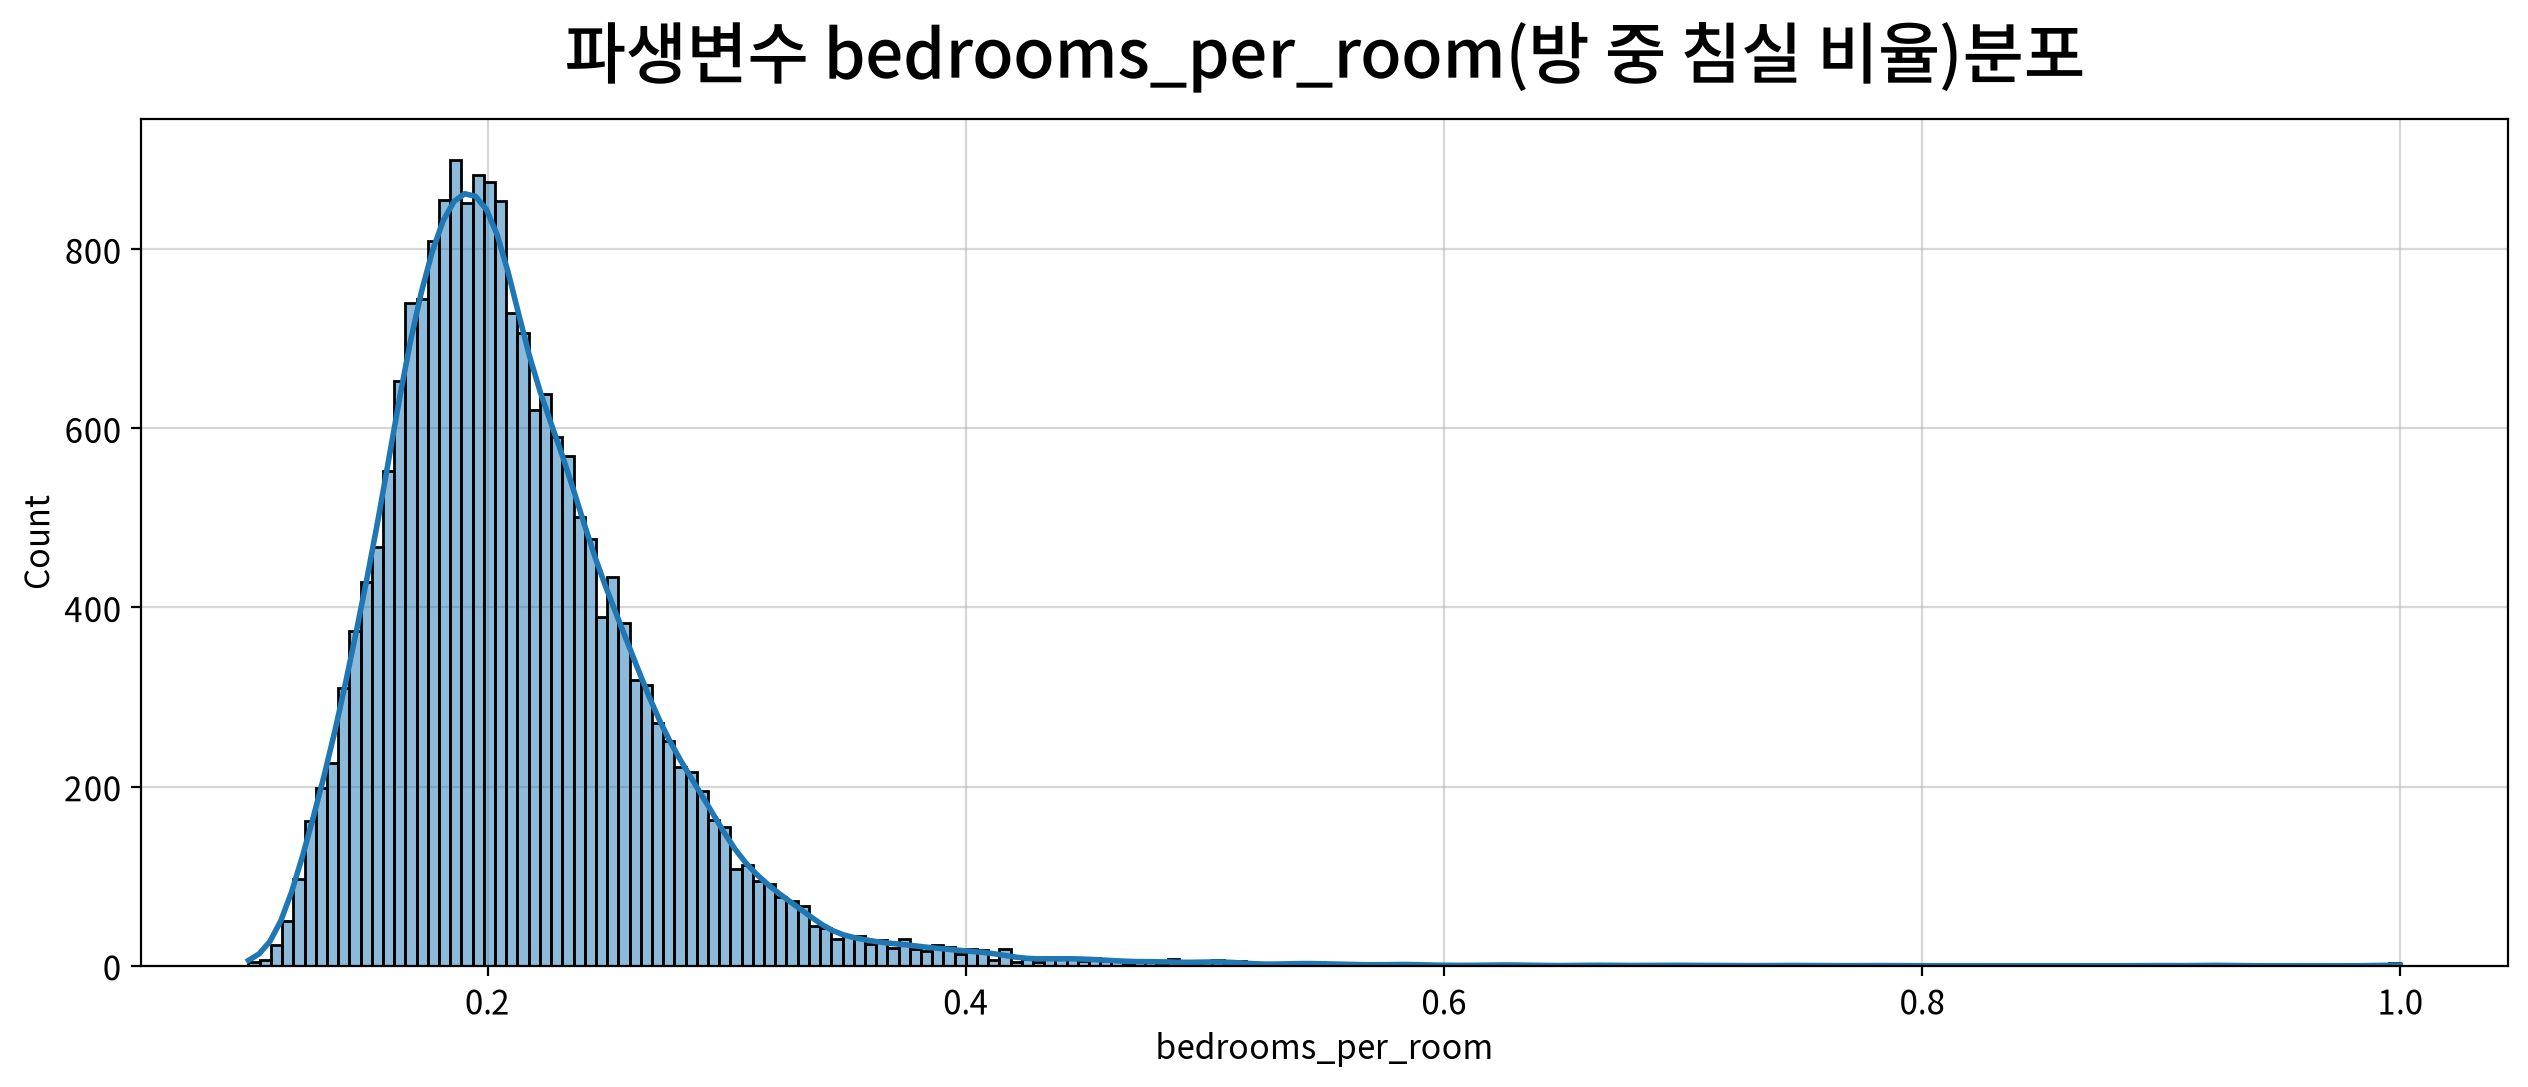

,bedrooms_per_room
count,20433.000
mean,0.213
std,0.058
min,0.100
25%,0.175
50%,0.203
75%,0.240
max,1.000
rel_diff,0.049
rdiff_flag,similar


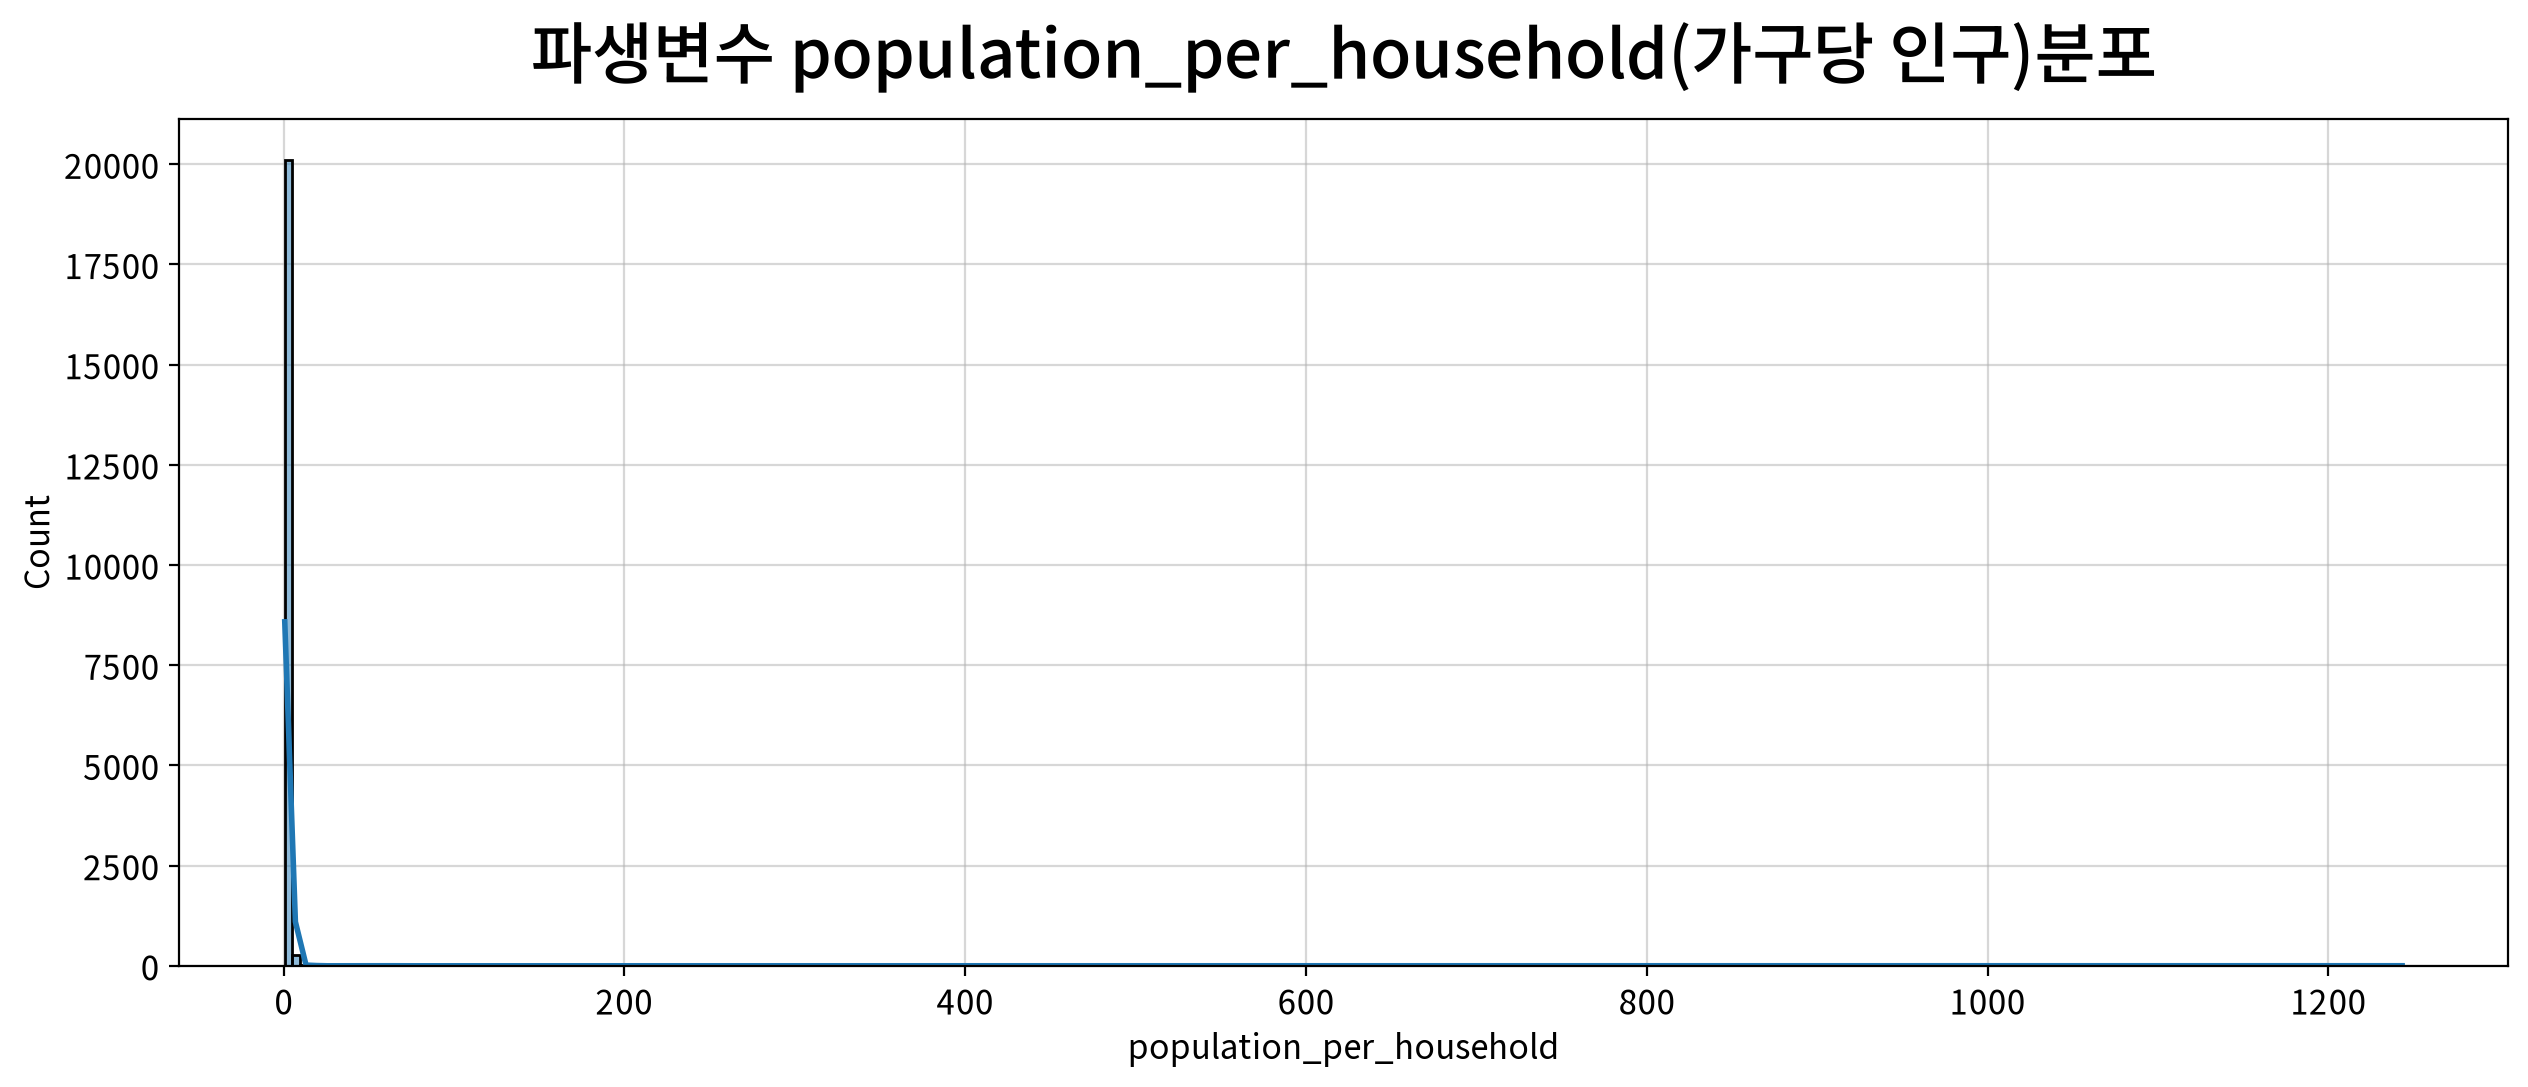

,population_per_household
count,20433.000
mean,3.072
std,10.438
min,0.692
25%,2.429
50%,2.818
75%,3.282
max,1243.333
rel_diff,0.090
rdiff_flag,similar


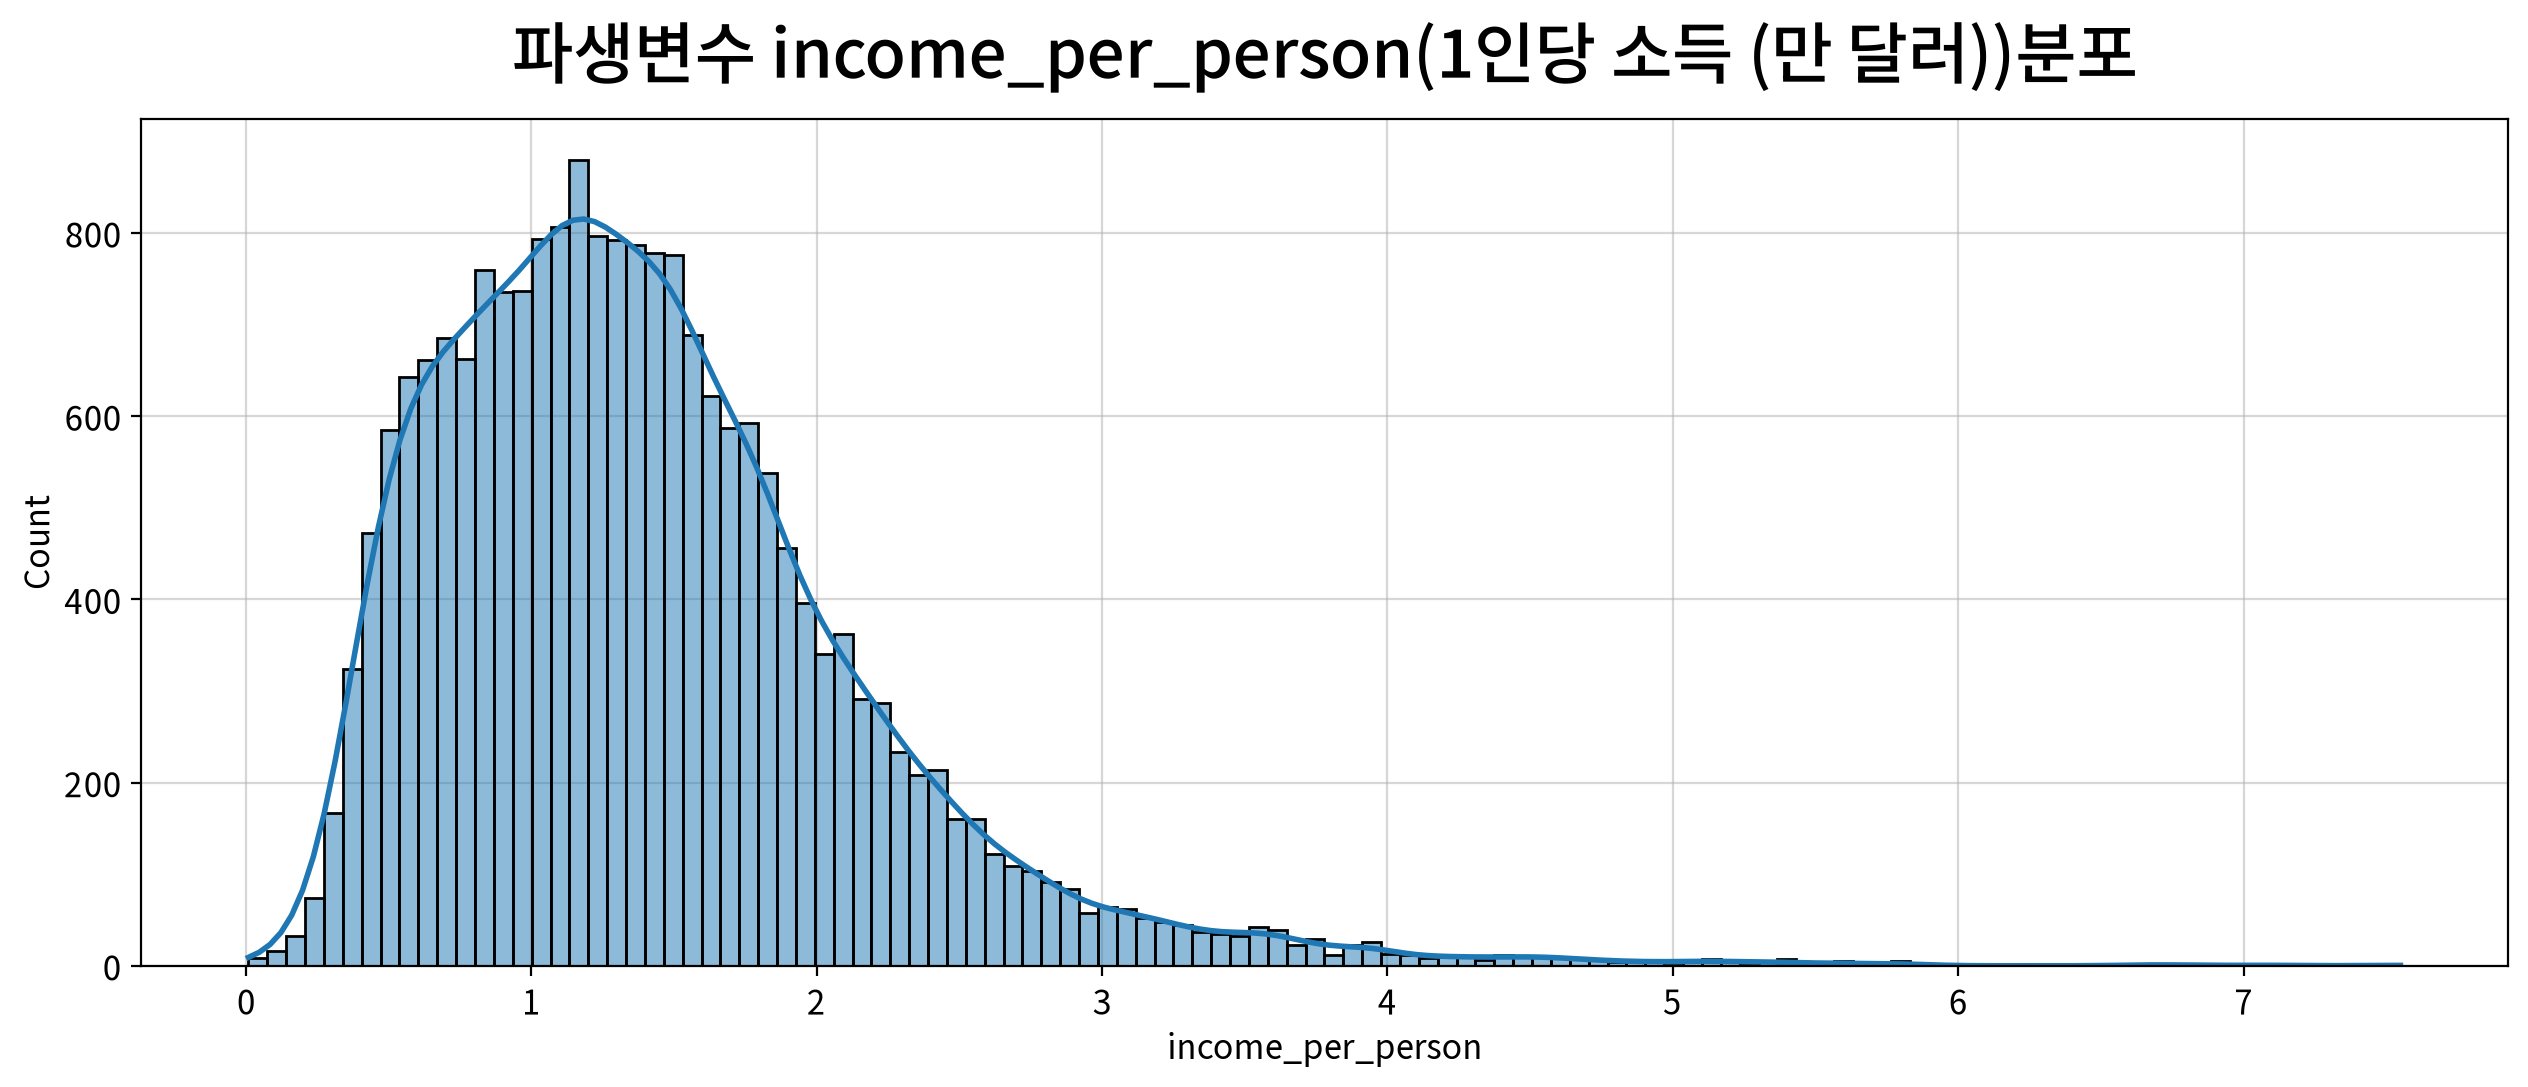

,income_per_person
count,20433.000
mean,1.409
std,0.755
min,0.008
25%,0.870
50%,1.296
75%,1.777
max,7.550
rel_diff,0.087
rdiff_flag,similar


In [24]:
for f in derived_continuous:
    # 히스토그램만 그리는 경우 
    my_plot.histplot(data=df, x=f, kde=True, width=1280, height=560, 
                     title=f"파생변수 {f}({column_means[f]})분포")

    display(derived_num_desc[derived_num_desc.index ==f].T)

### 5. 단변량 분석 (범주형 파생변수)

C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


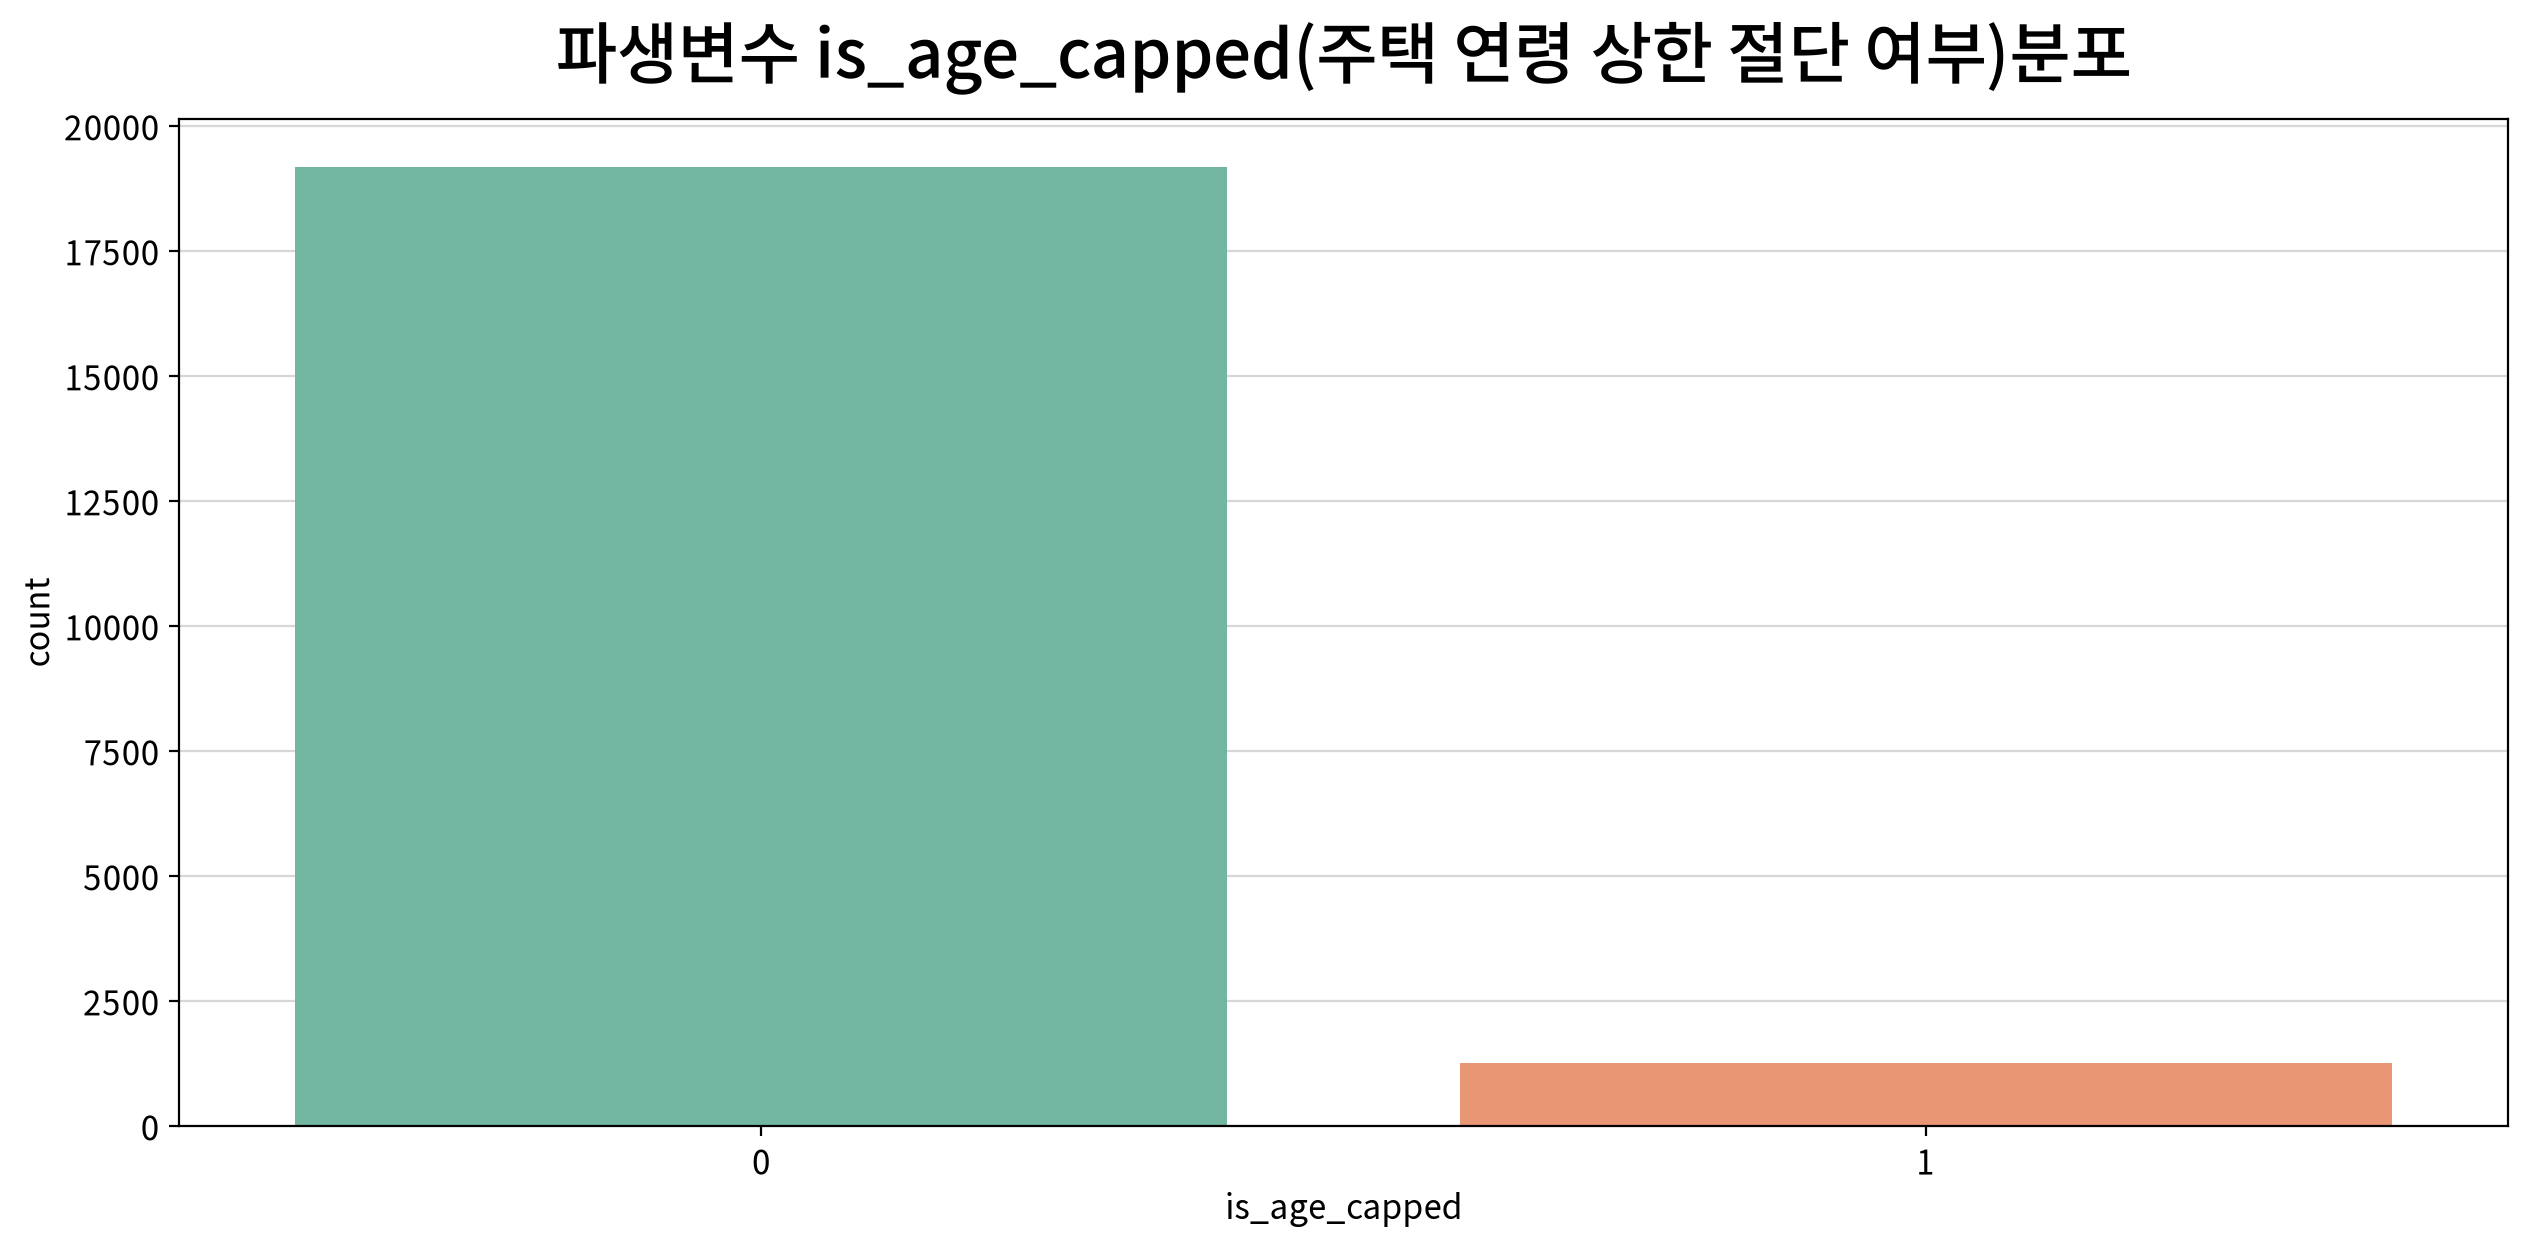

,count,unique,top,freq
is_age_capped,20433,2,0,19168


,빈도,비율
is_age_capped,,
0,19168,0.938
1,1265,0.062


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


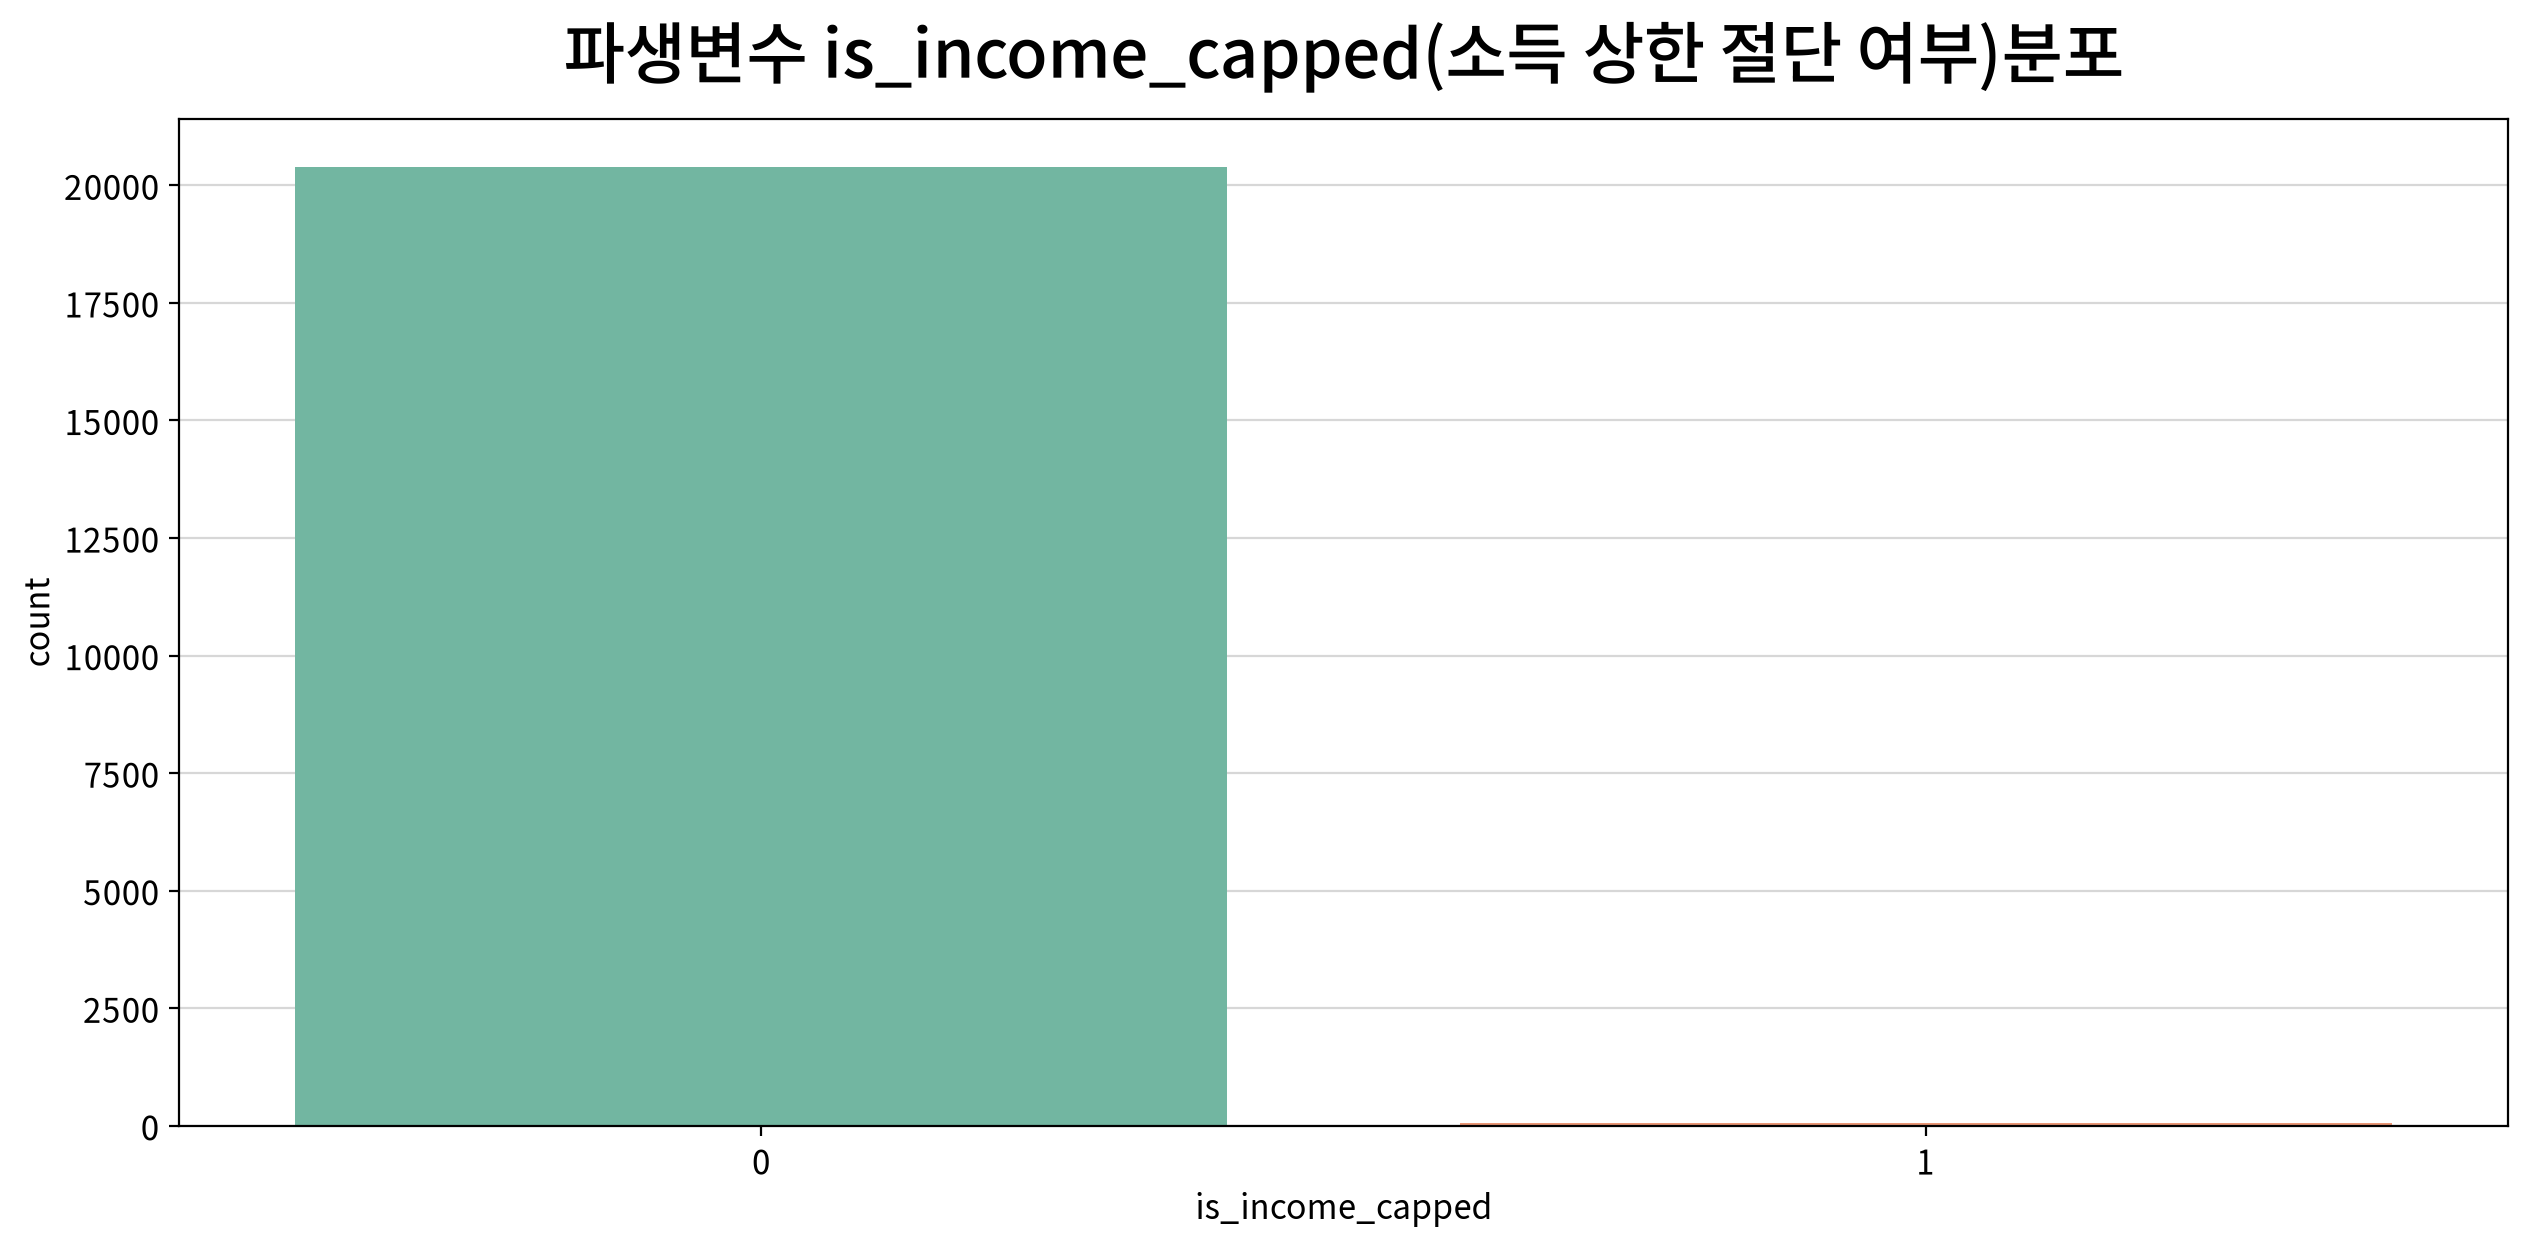

,count,unique,top,freq
is_income_capped,20433,2,0,20383


,빈도,비율
is_income_capped,,
0,20383,0.998
1,50,0.002


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


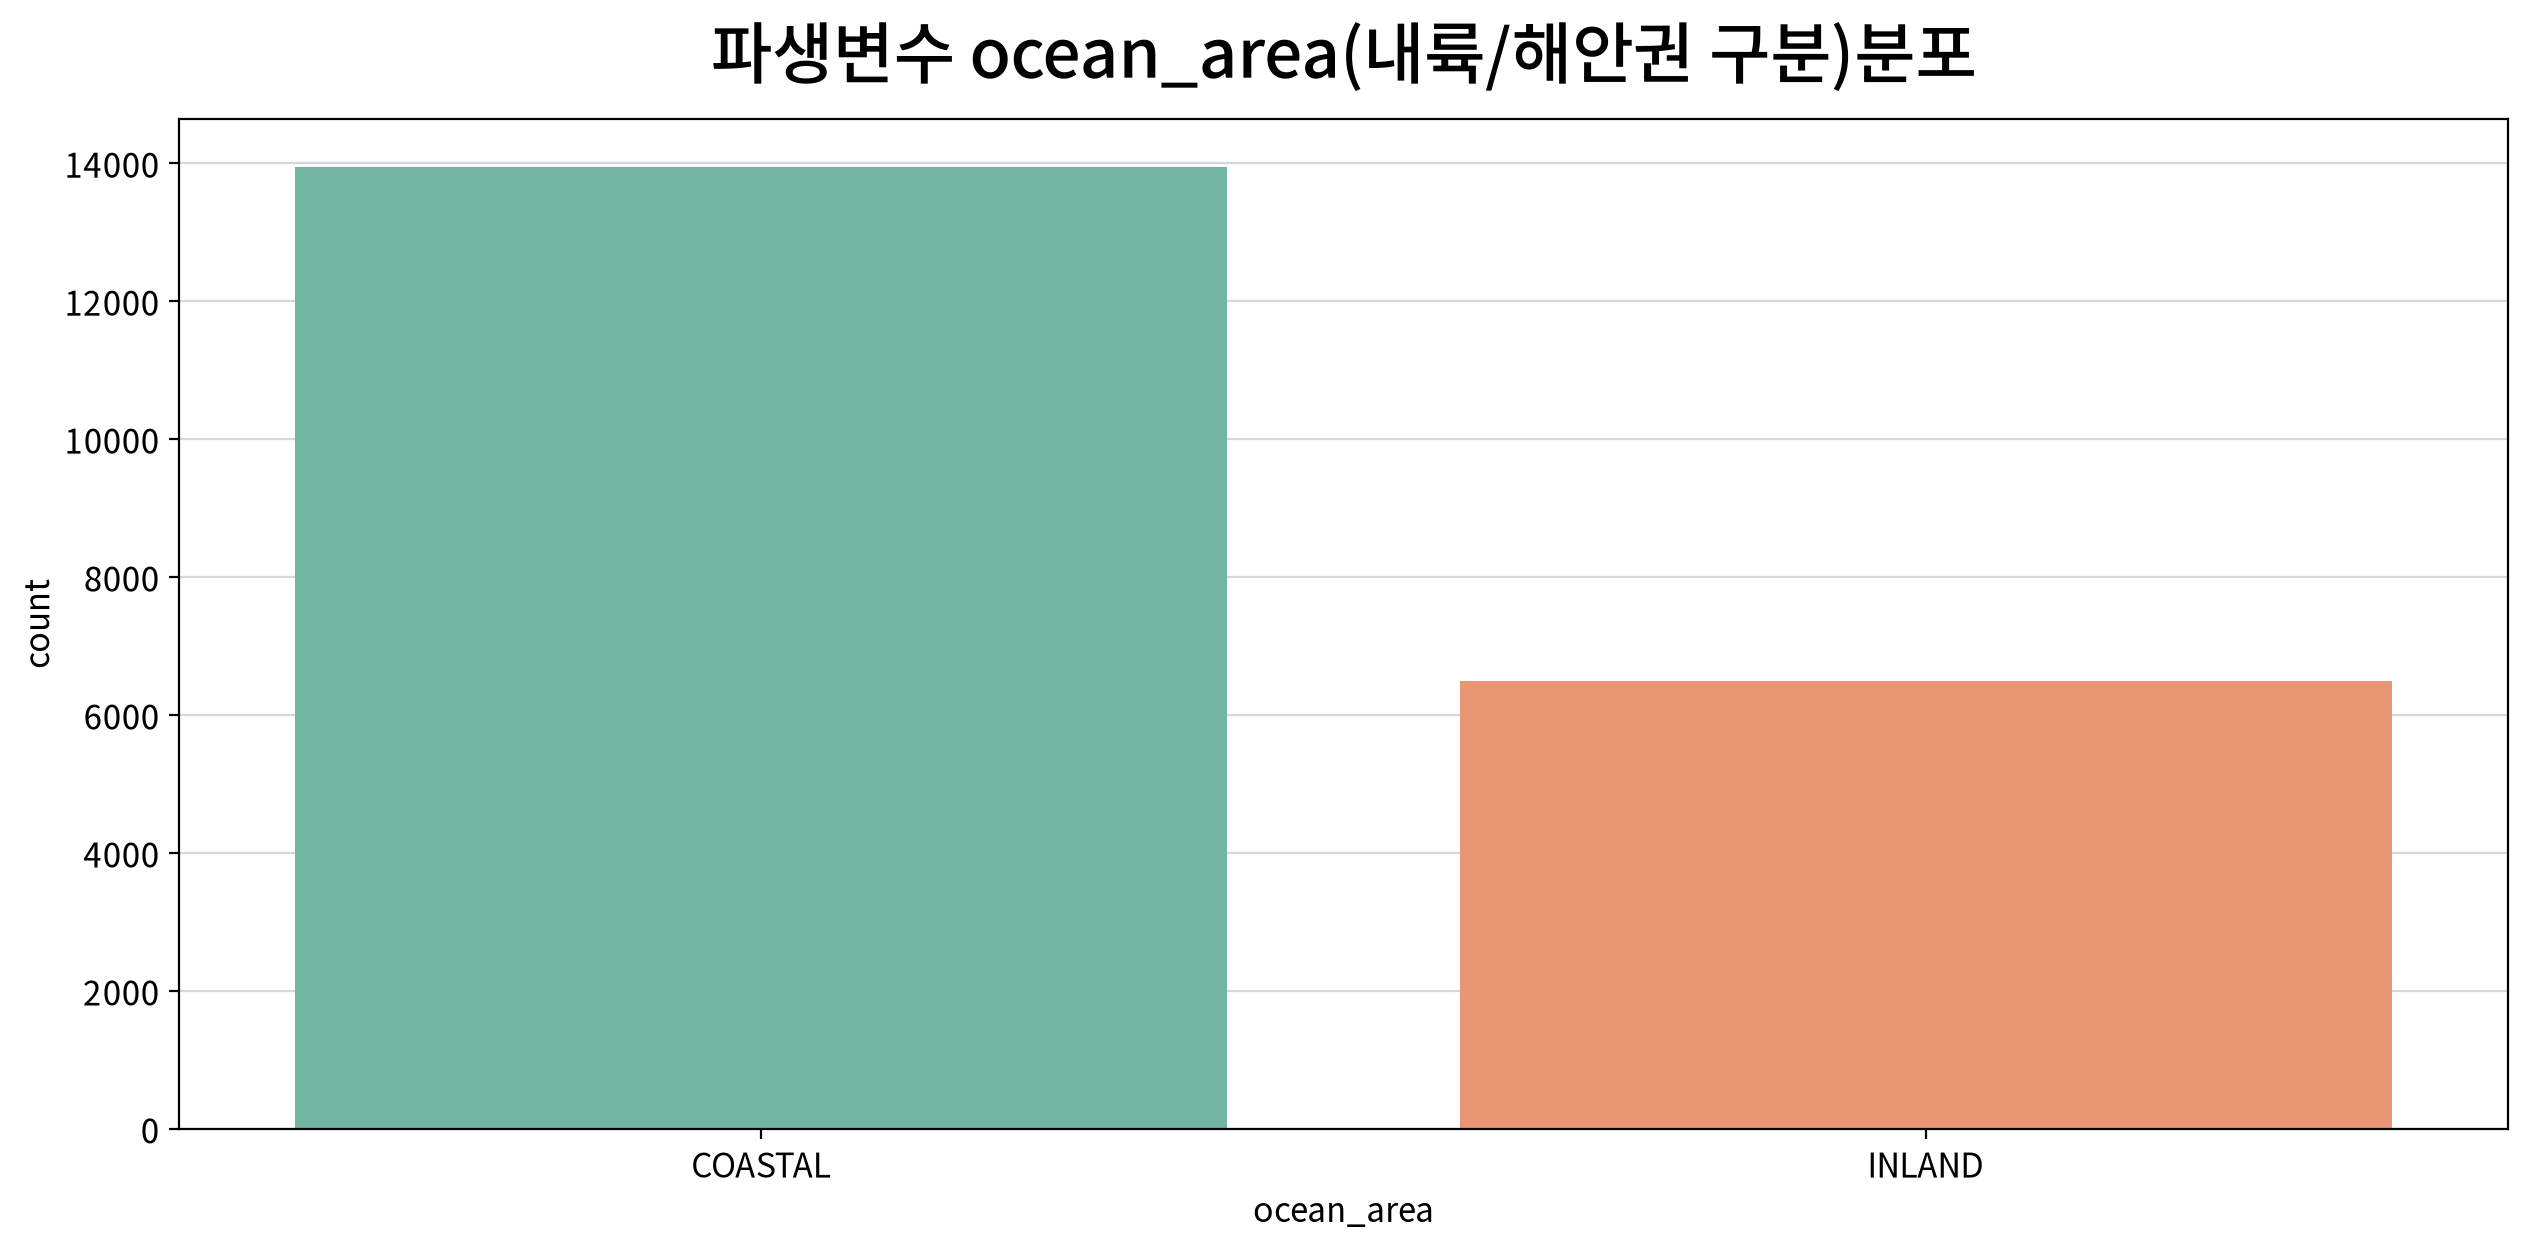

,count,unique,top,freq
ocean_area,20433,2,COASTAL,13937


,빈도,비율
ocean_area,,
COASTAL,13937,0.682
INLAND,6496,0.318


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


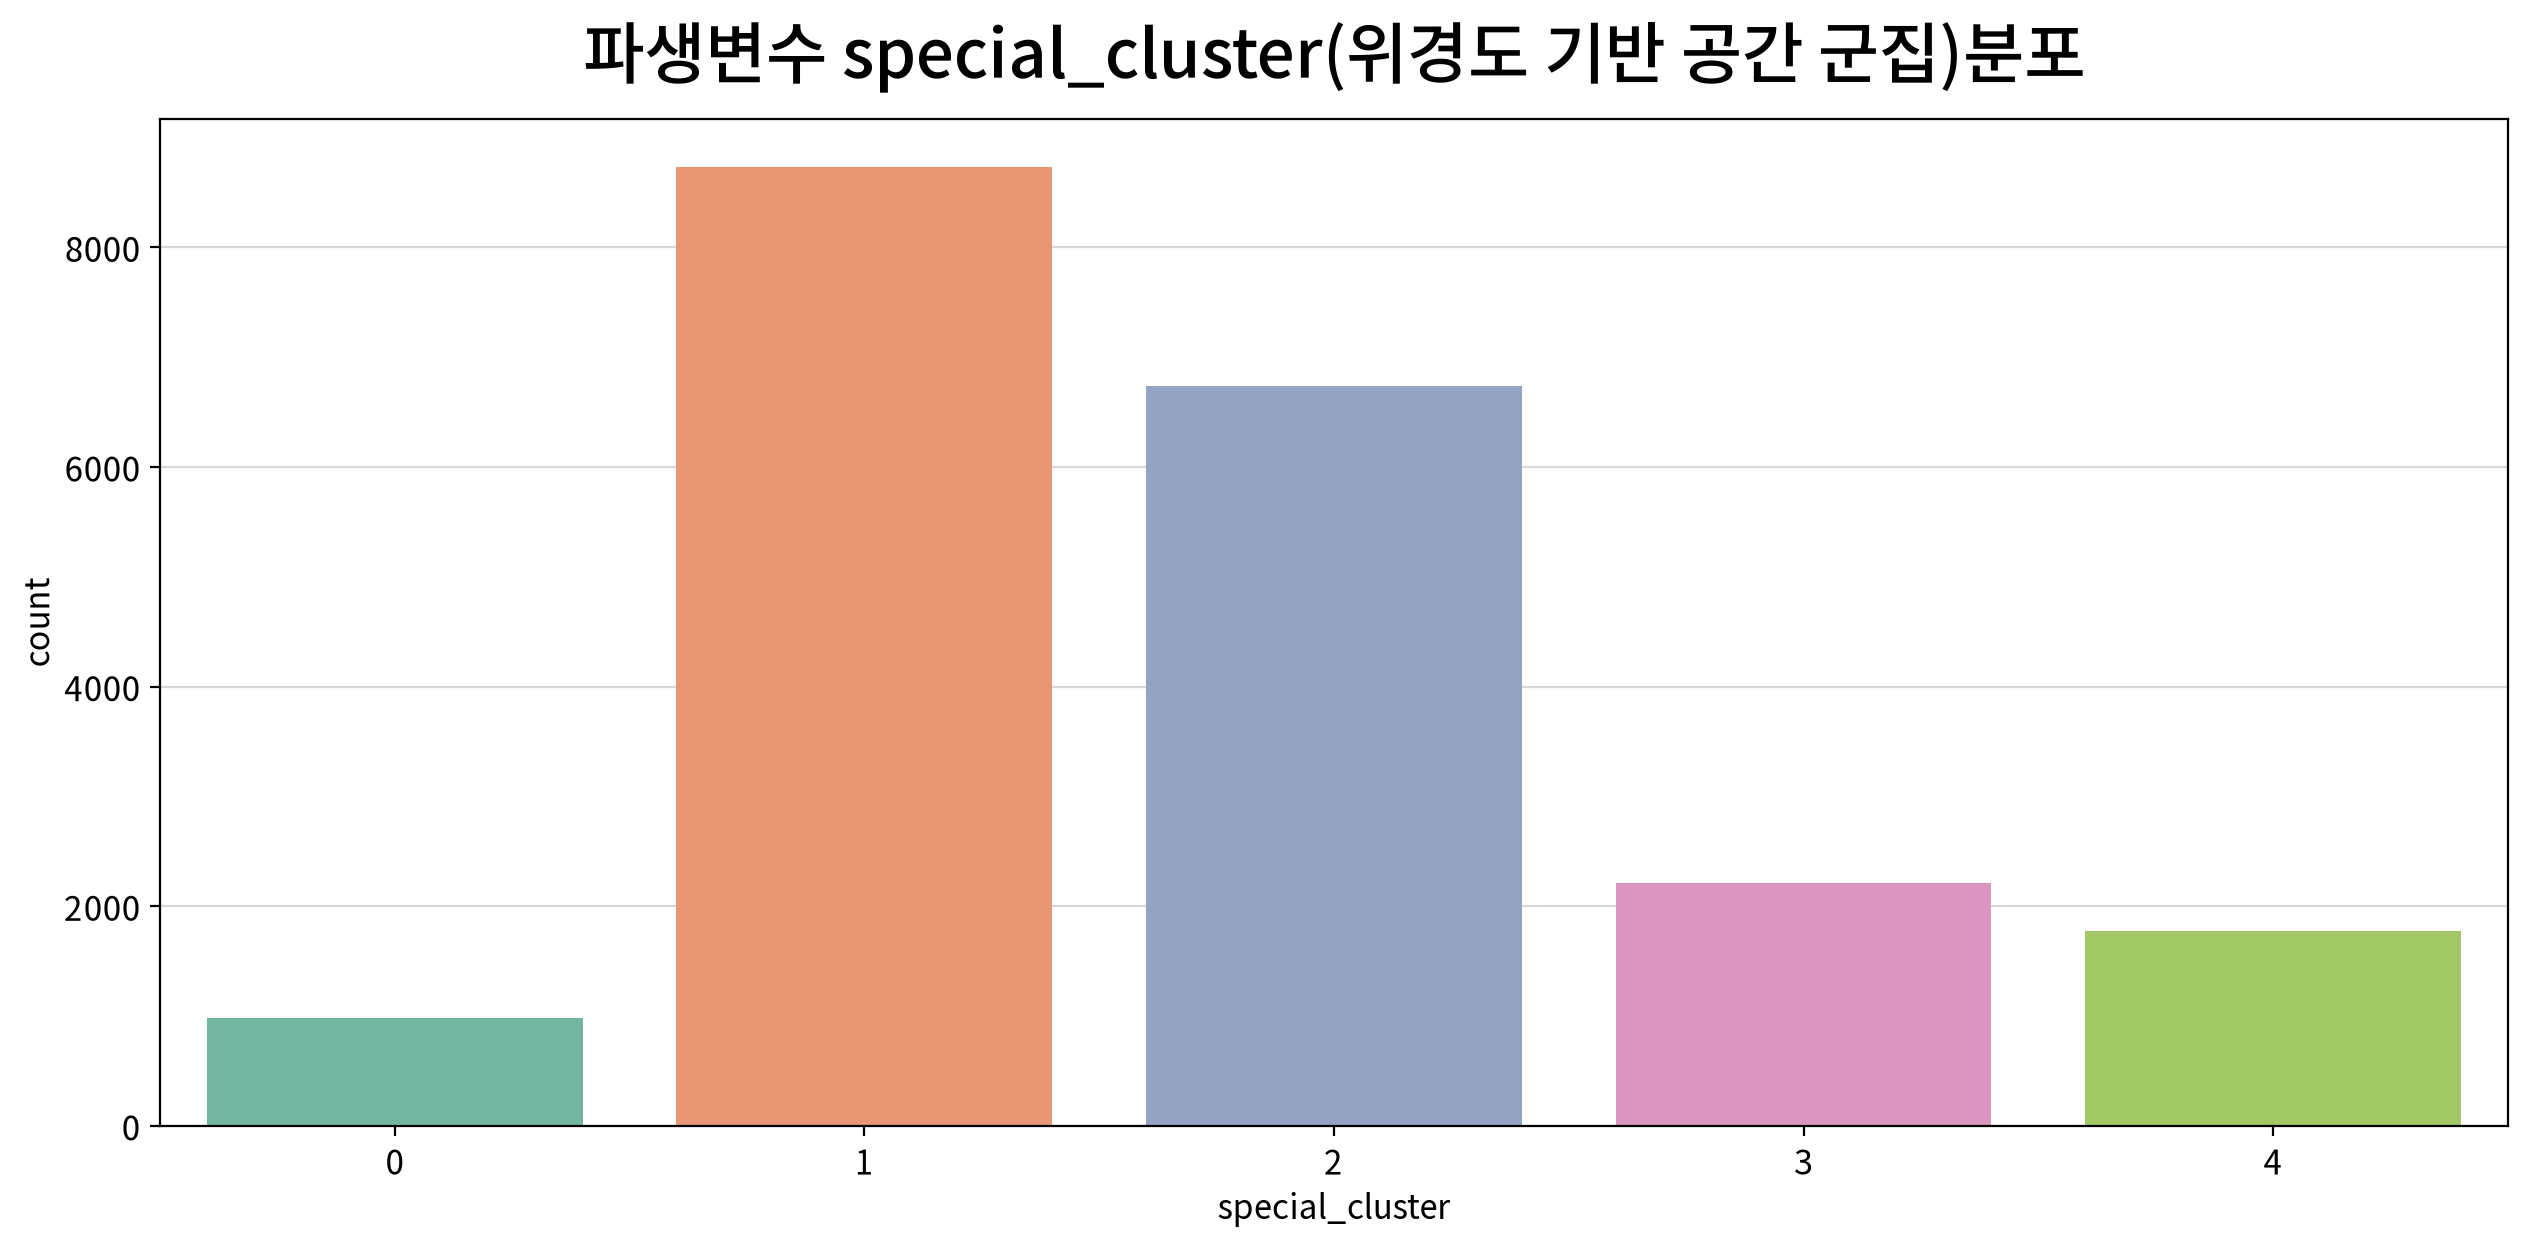

,count,unique,top,freq
special_cluster,20433,5,1,8729


,빈도,비율
special_cluster,,
1,8729,0.427
2,6736,0.330
3,2211,0.108
4,1778,0.087
0,979,0.048


In [25]:
for n in derived_nominal:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, palette="Set2", 
                      title=f"파생변수 {n}({column_means[n]})분포")

    # 범주형 기술통계량 
    display(derived_cat_desc[[n]].T)

    # 추가적으로 빈도표 생성 
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

### 6. 상관분석 (x:연속형 파생변수 -> y:연속형 종속변수)

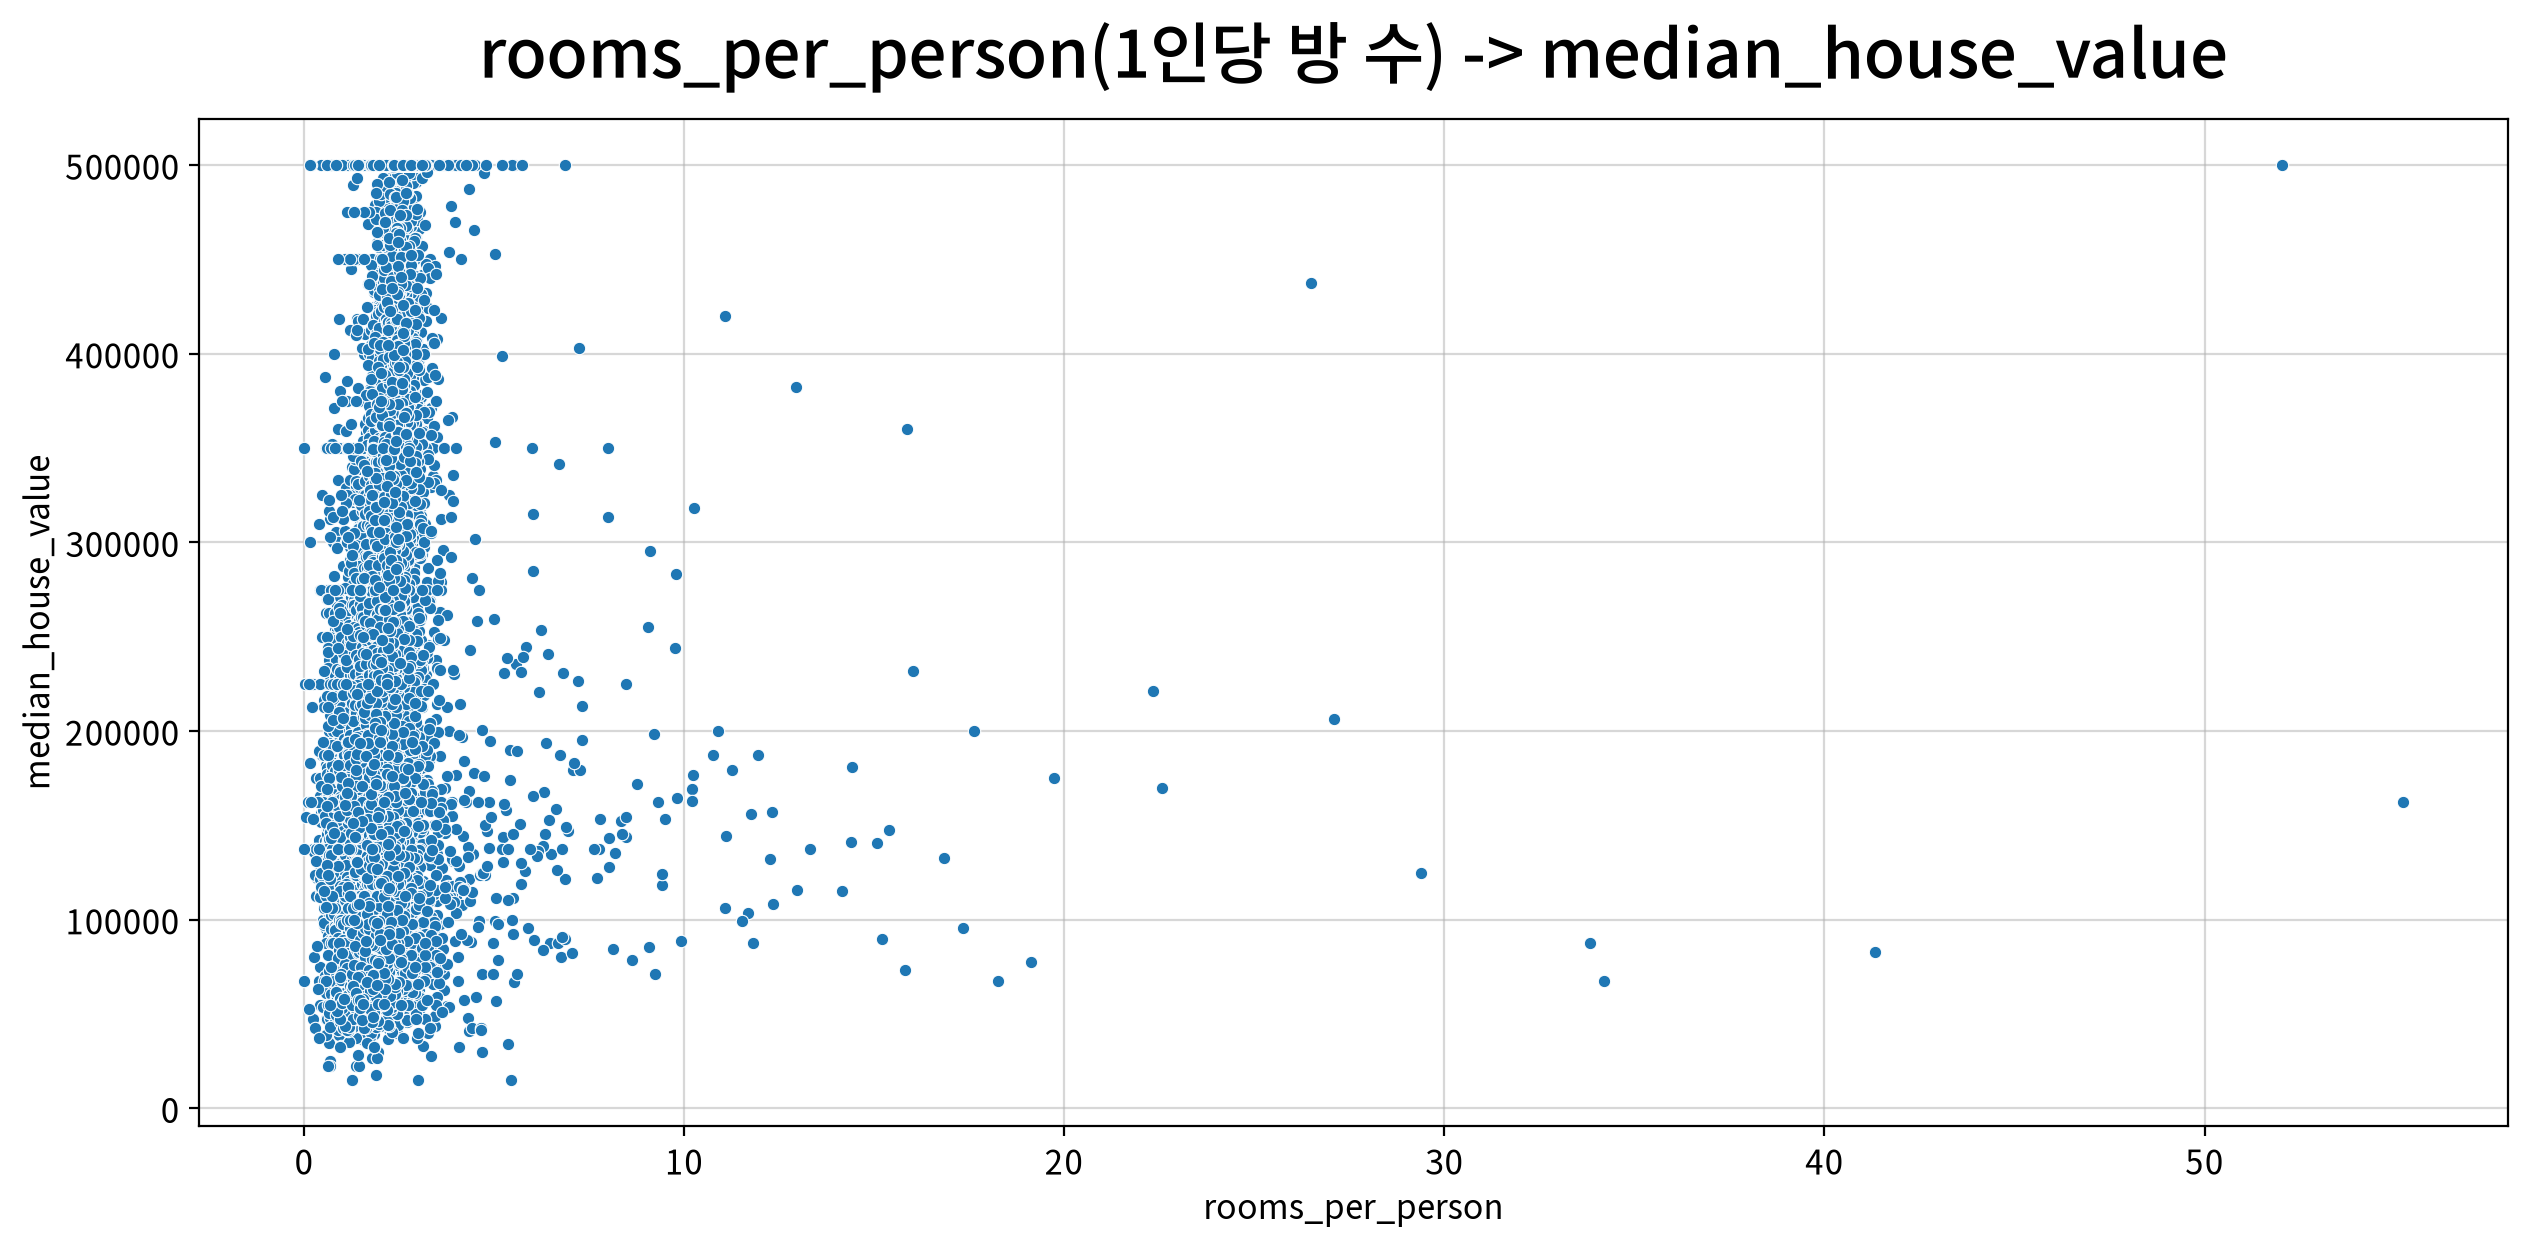

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_person,median_house_value,Spearman,0.400,0.000,Moderate,True,False,False,False,True,True


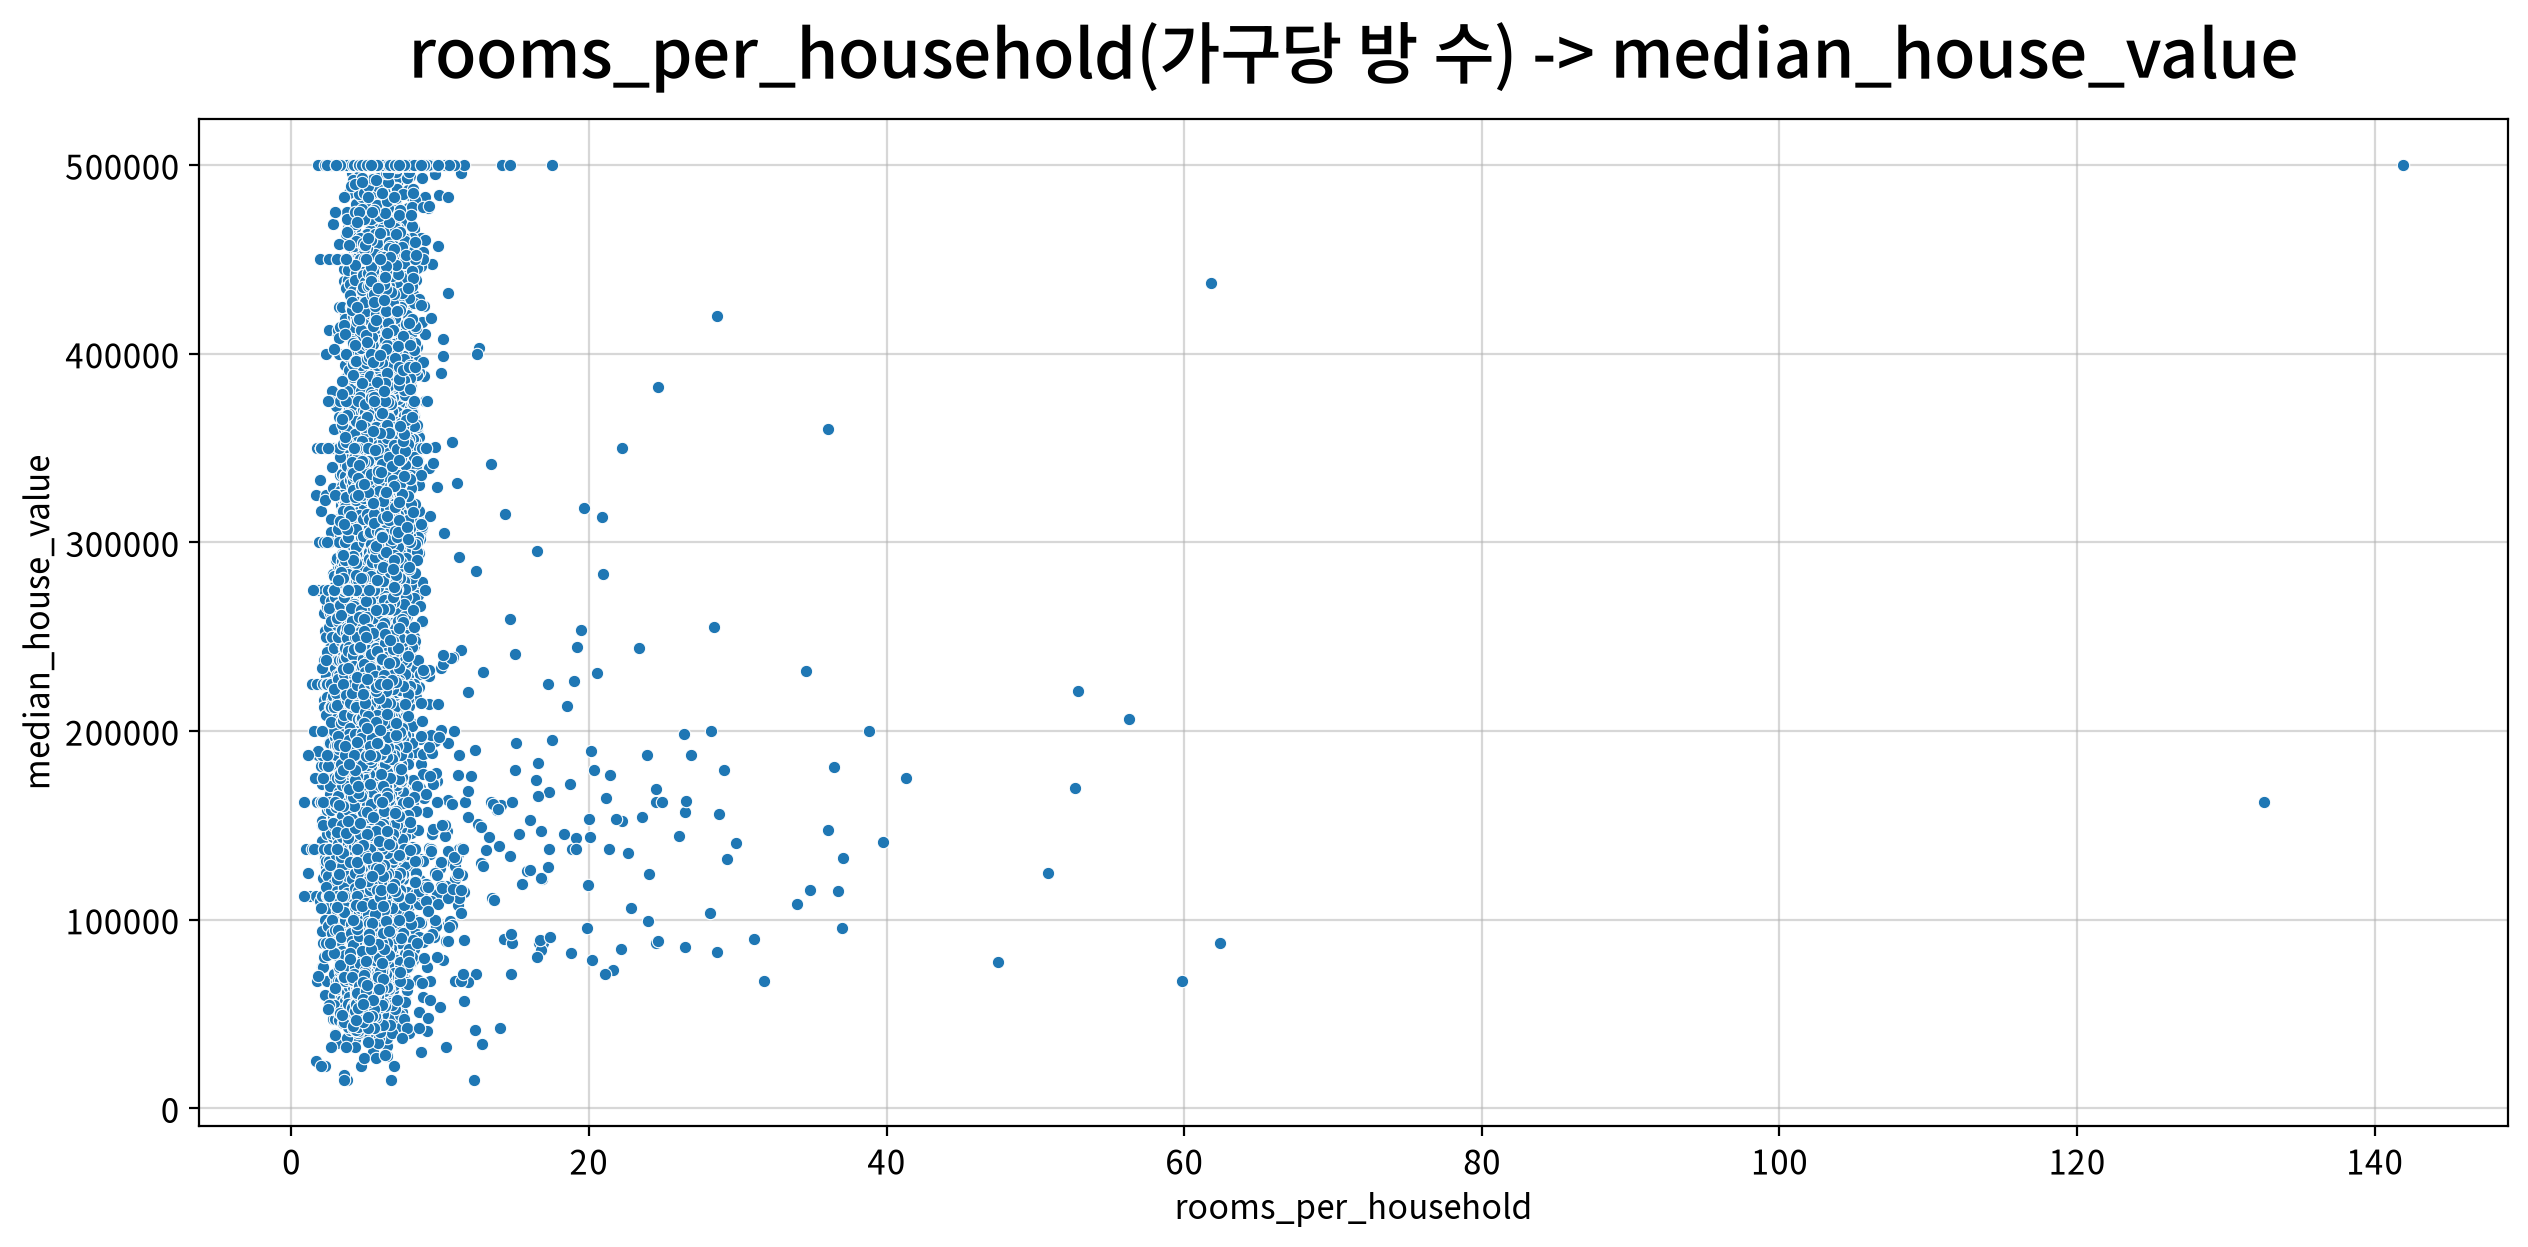

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_household,median_house_value,Spearman,0.263,0.000,Weak,True,False,False,False,True,True


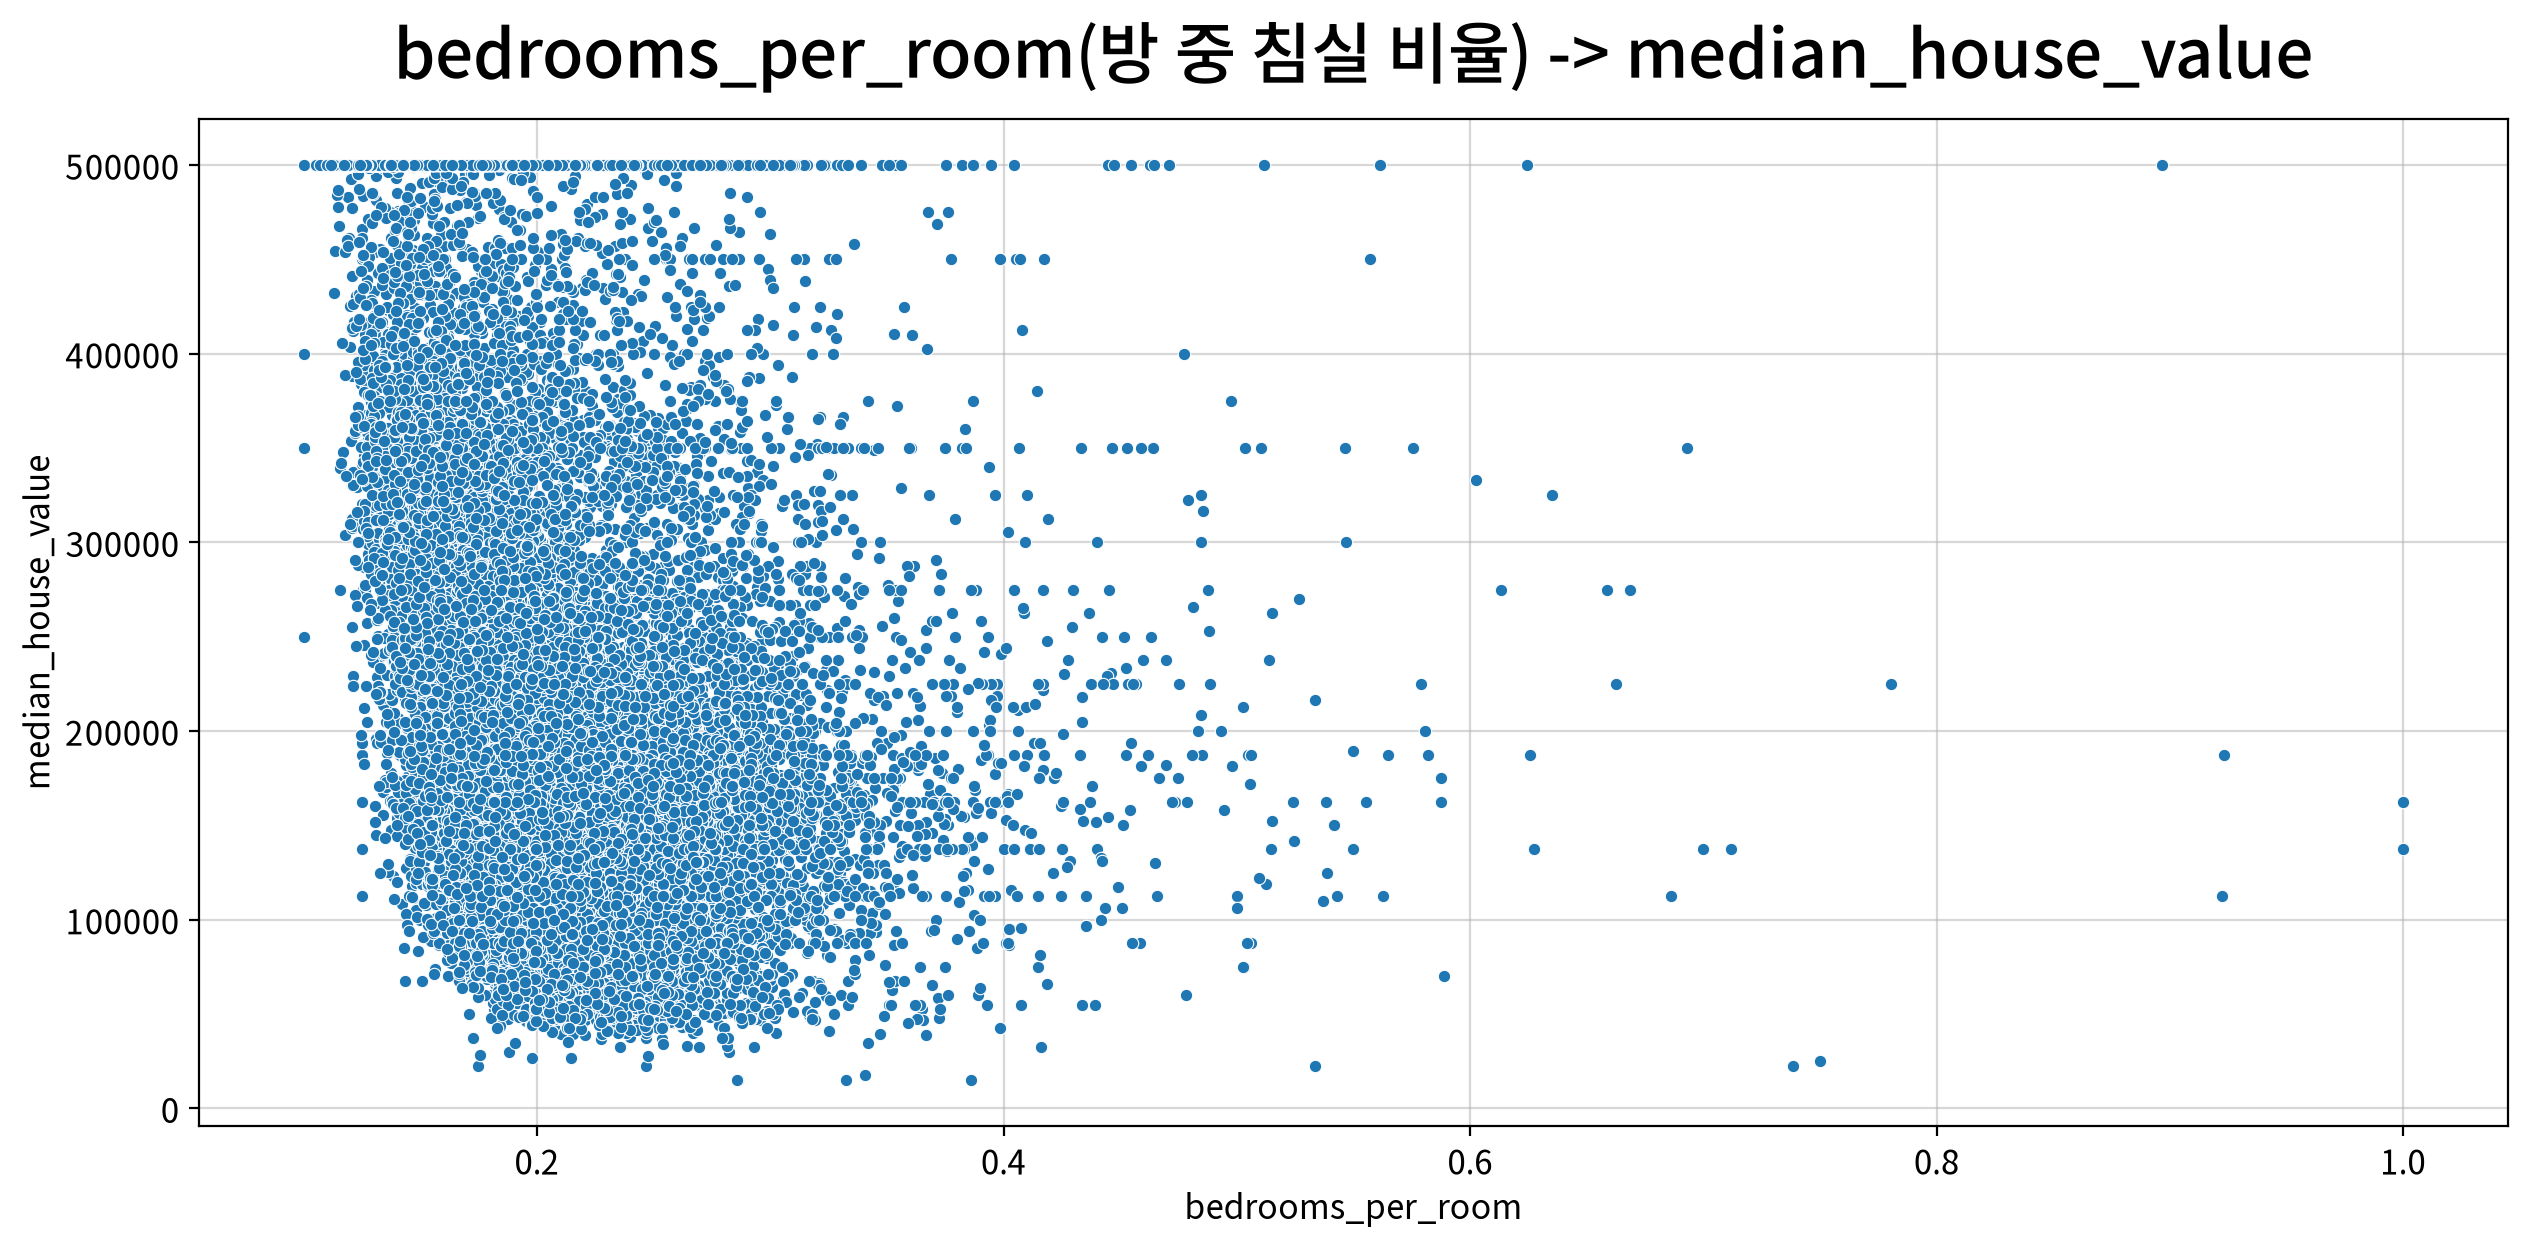

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bedrooms_per_room,median_house_value,Spearman,-0.332,0.000,Moderate,True,False,False,False,False,True


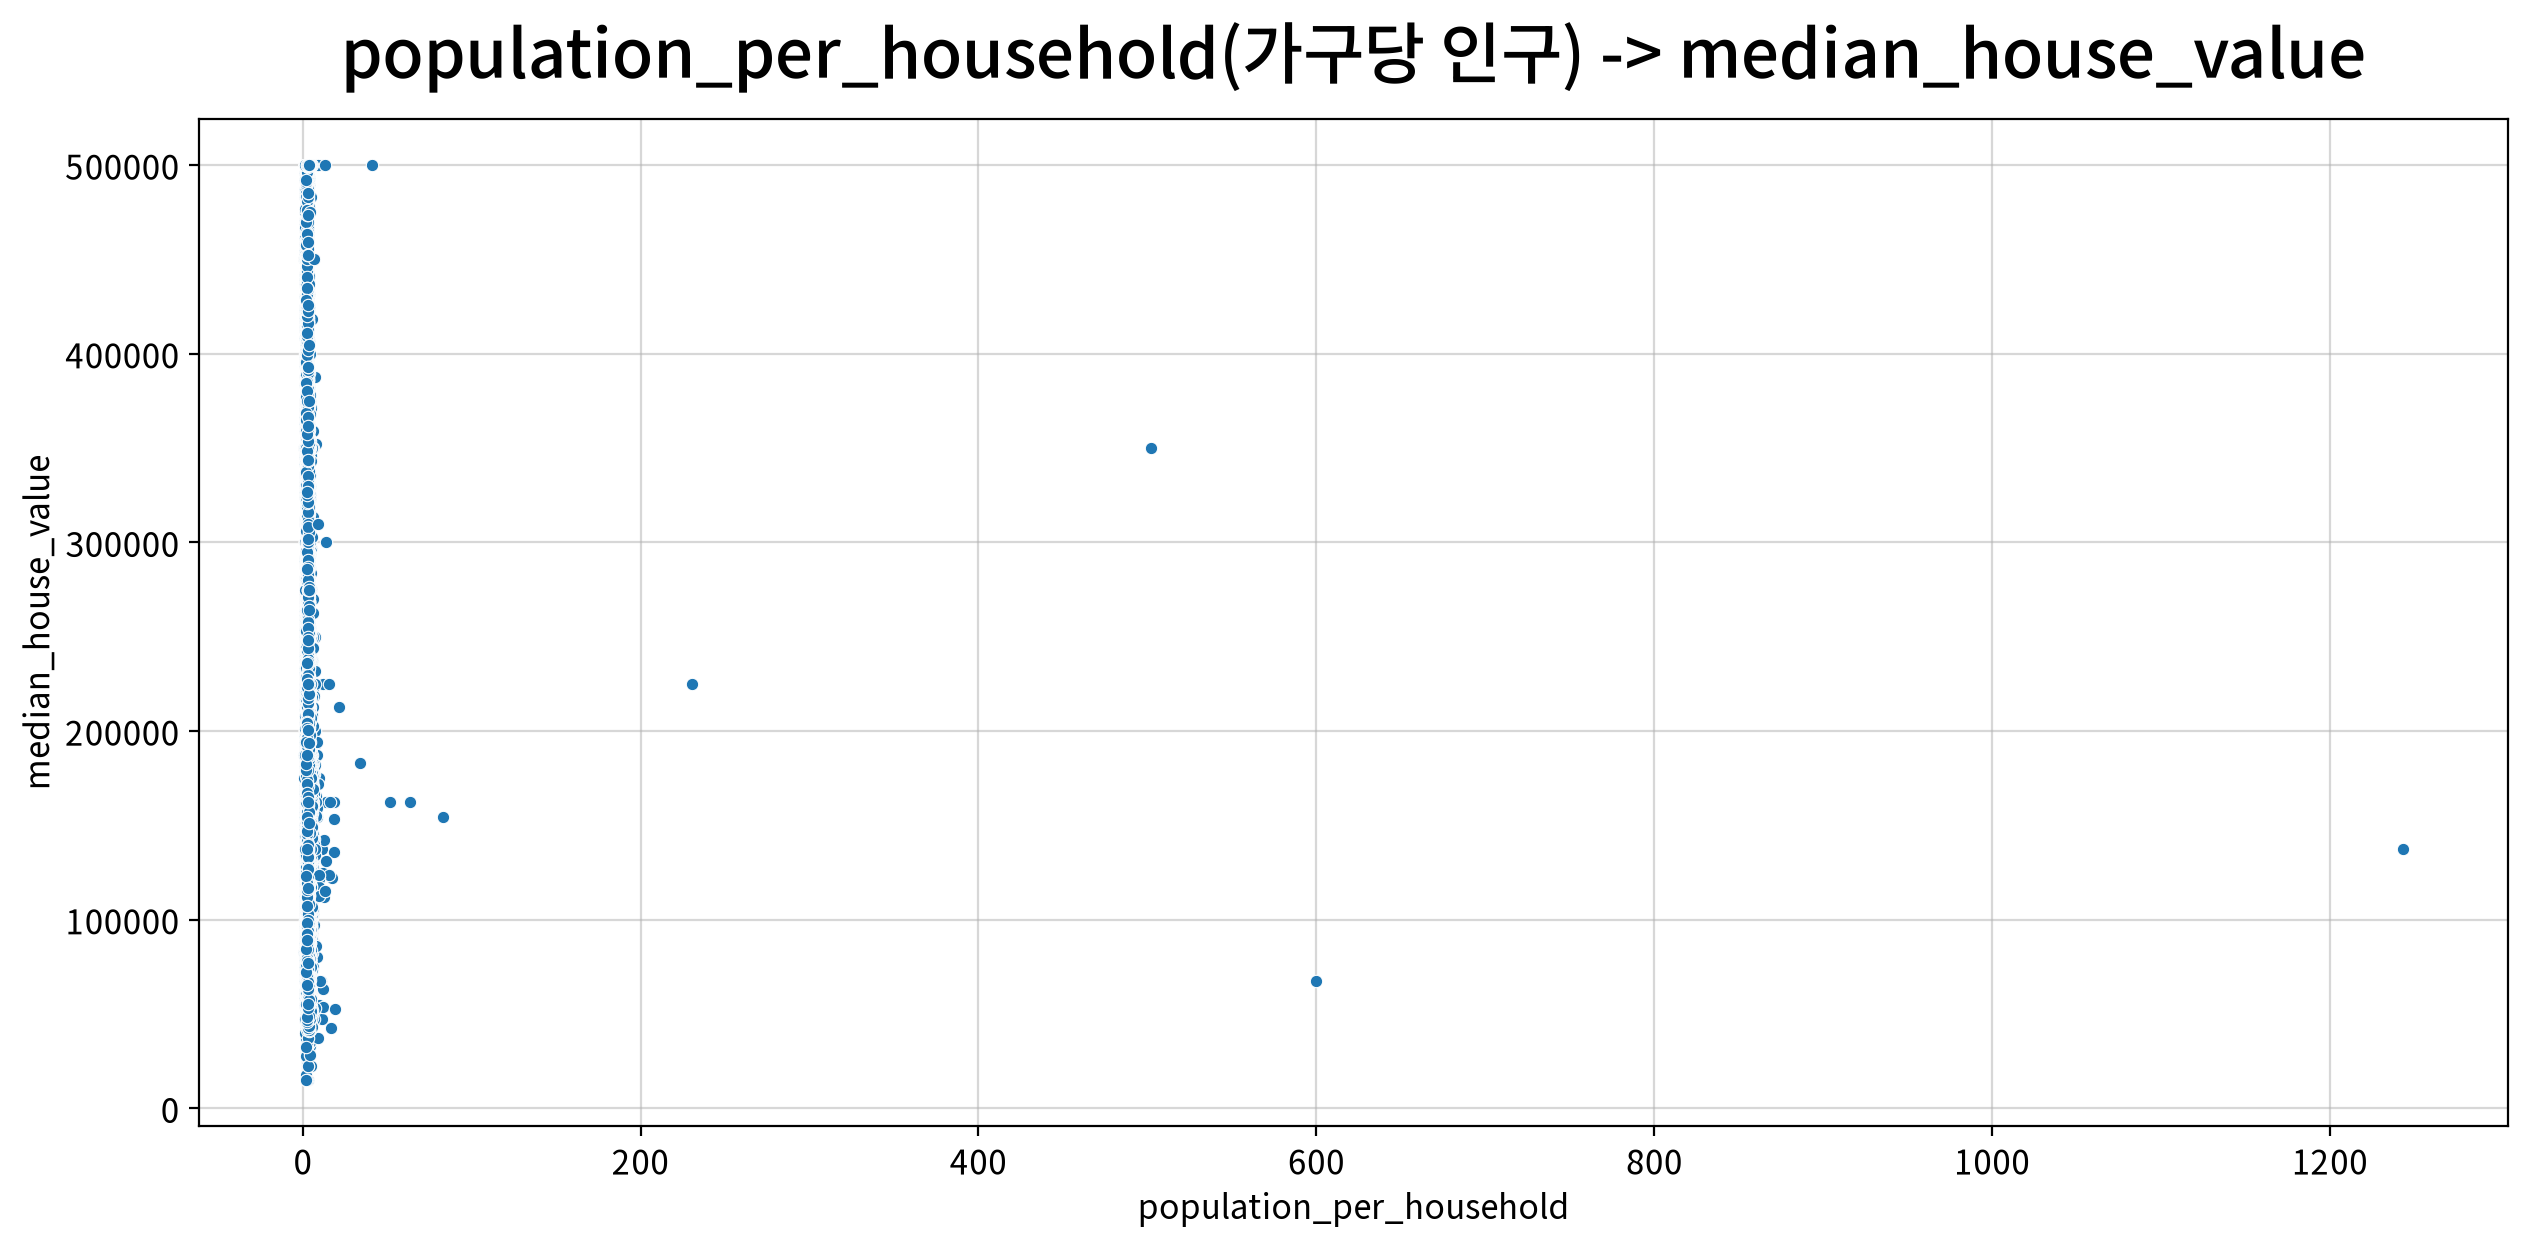

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population_per_household,median_house_value,Spearman,-0.256,0.000,Weak,True,False,False,False,True,True


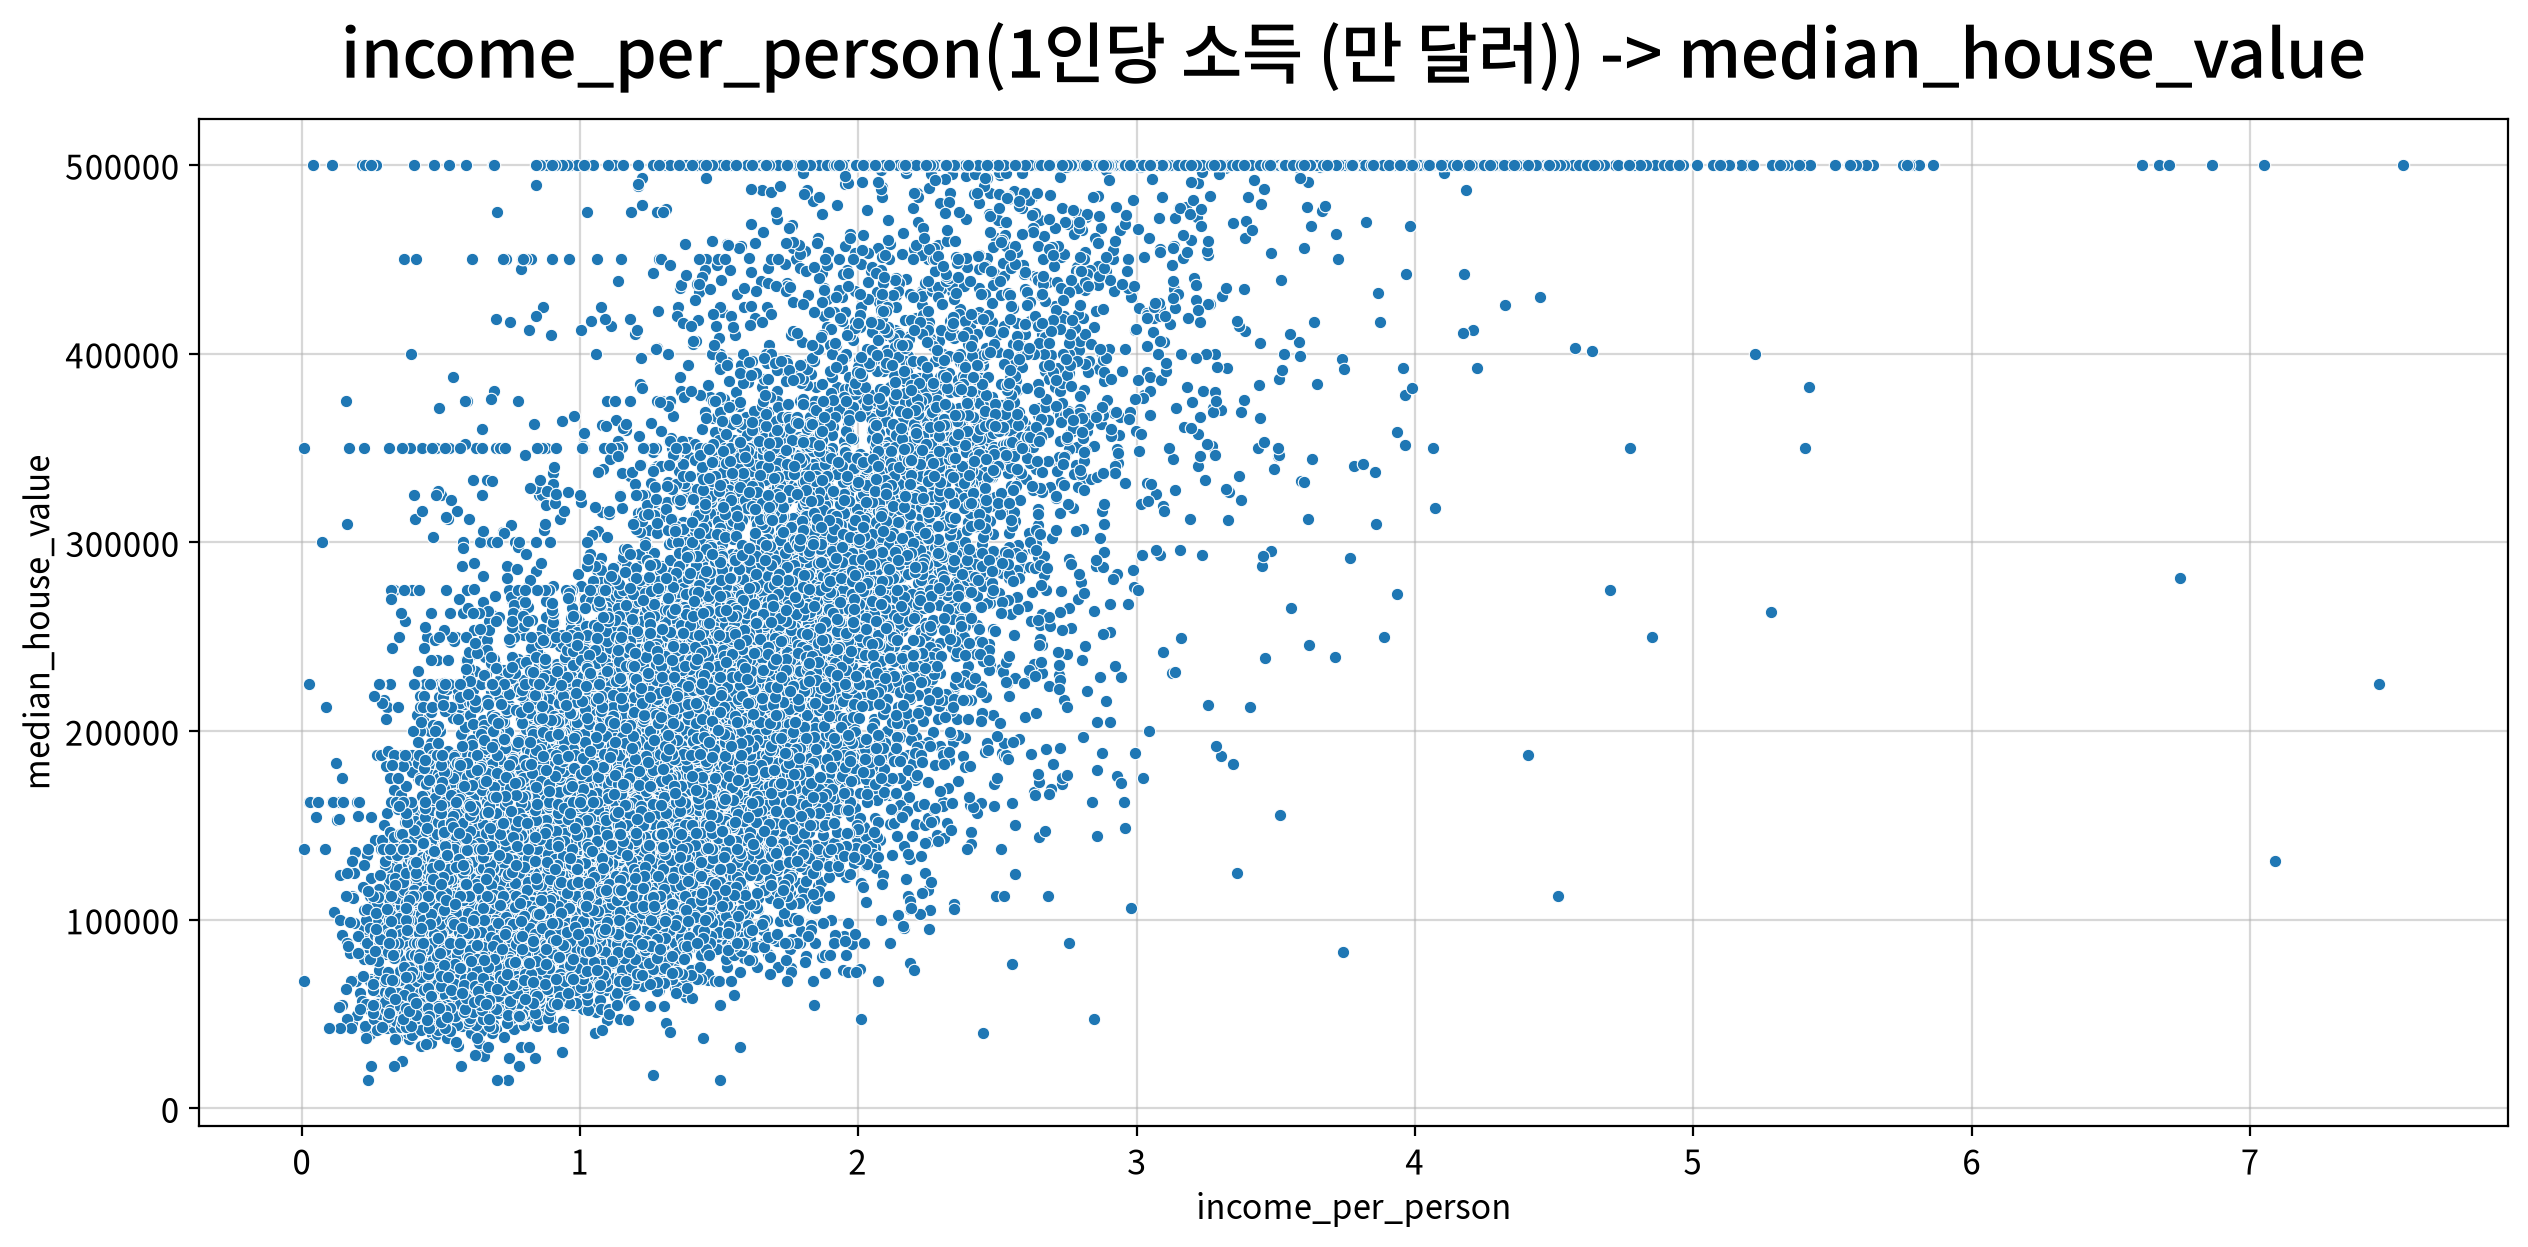

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
income_per_person,median_house_value,Spearman,0.722,0.000,Strong,True,False,False,False,False,True


In [27]:
# 연속형 파생변수 이름을 탐색하면서 반복 
for f in derived_continuous:
    # 시각화 
    my_plot.scatterplot(data=df, x=f, y=target, outline=False, 
                        linewidth=0.4, size=20, 
                        title=f"{f}({column_means[f]}) -> {target}")

    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))    

### 7. T-Test (x: 2집단 범주형 파생변수 -> y:종속변수)
범주형 파생변수 중 **2집단인 것만** 여기서 검정한다. 

#### -> is_age_capped(주택 연령 상한 절단 여부) -> median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.136e-75 U_stat=8.384e+06


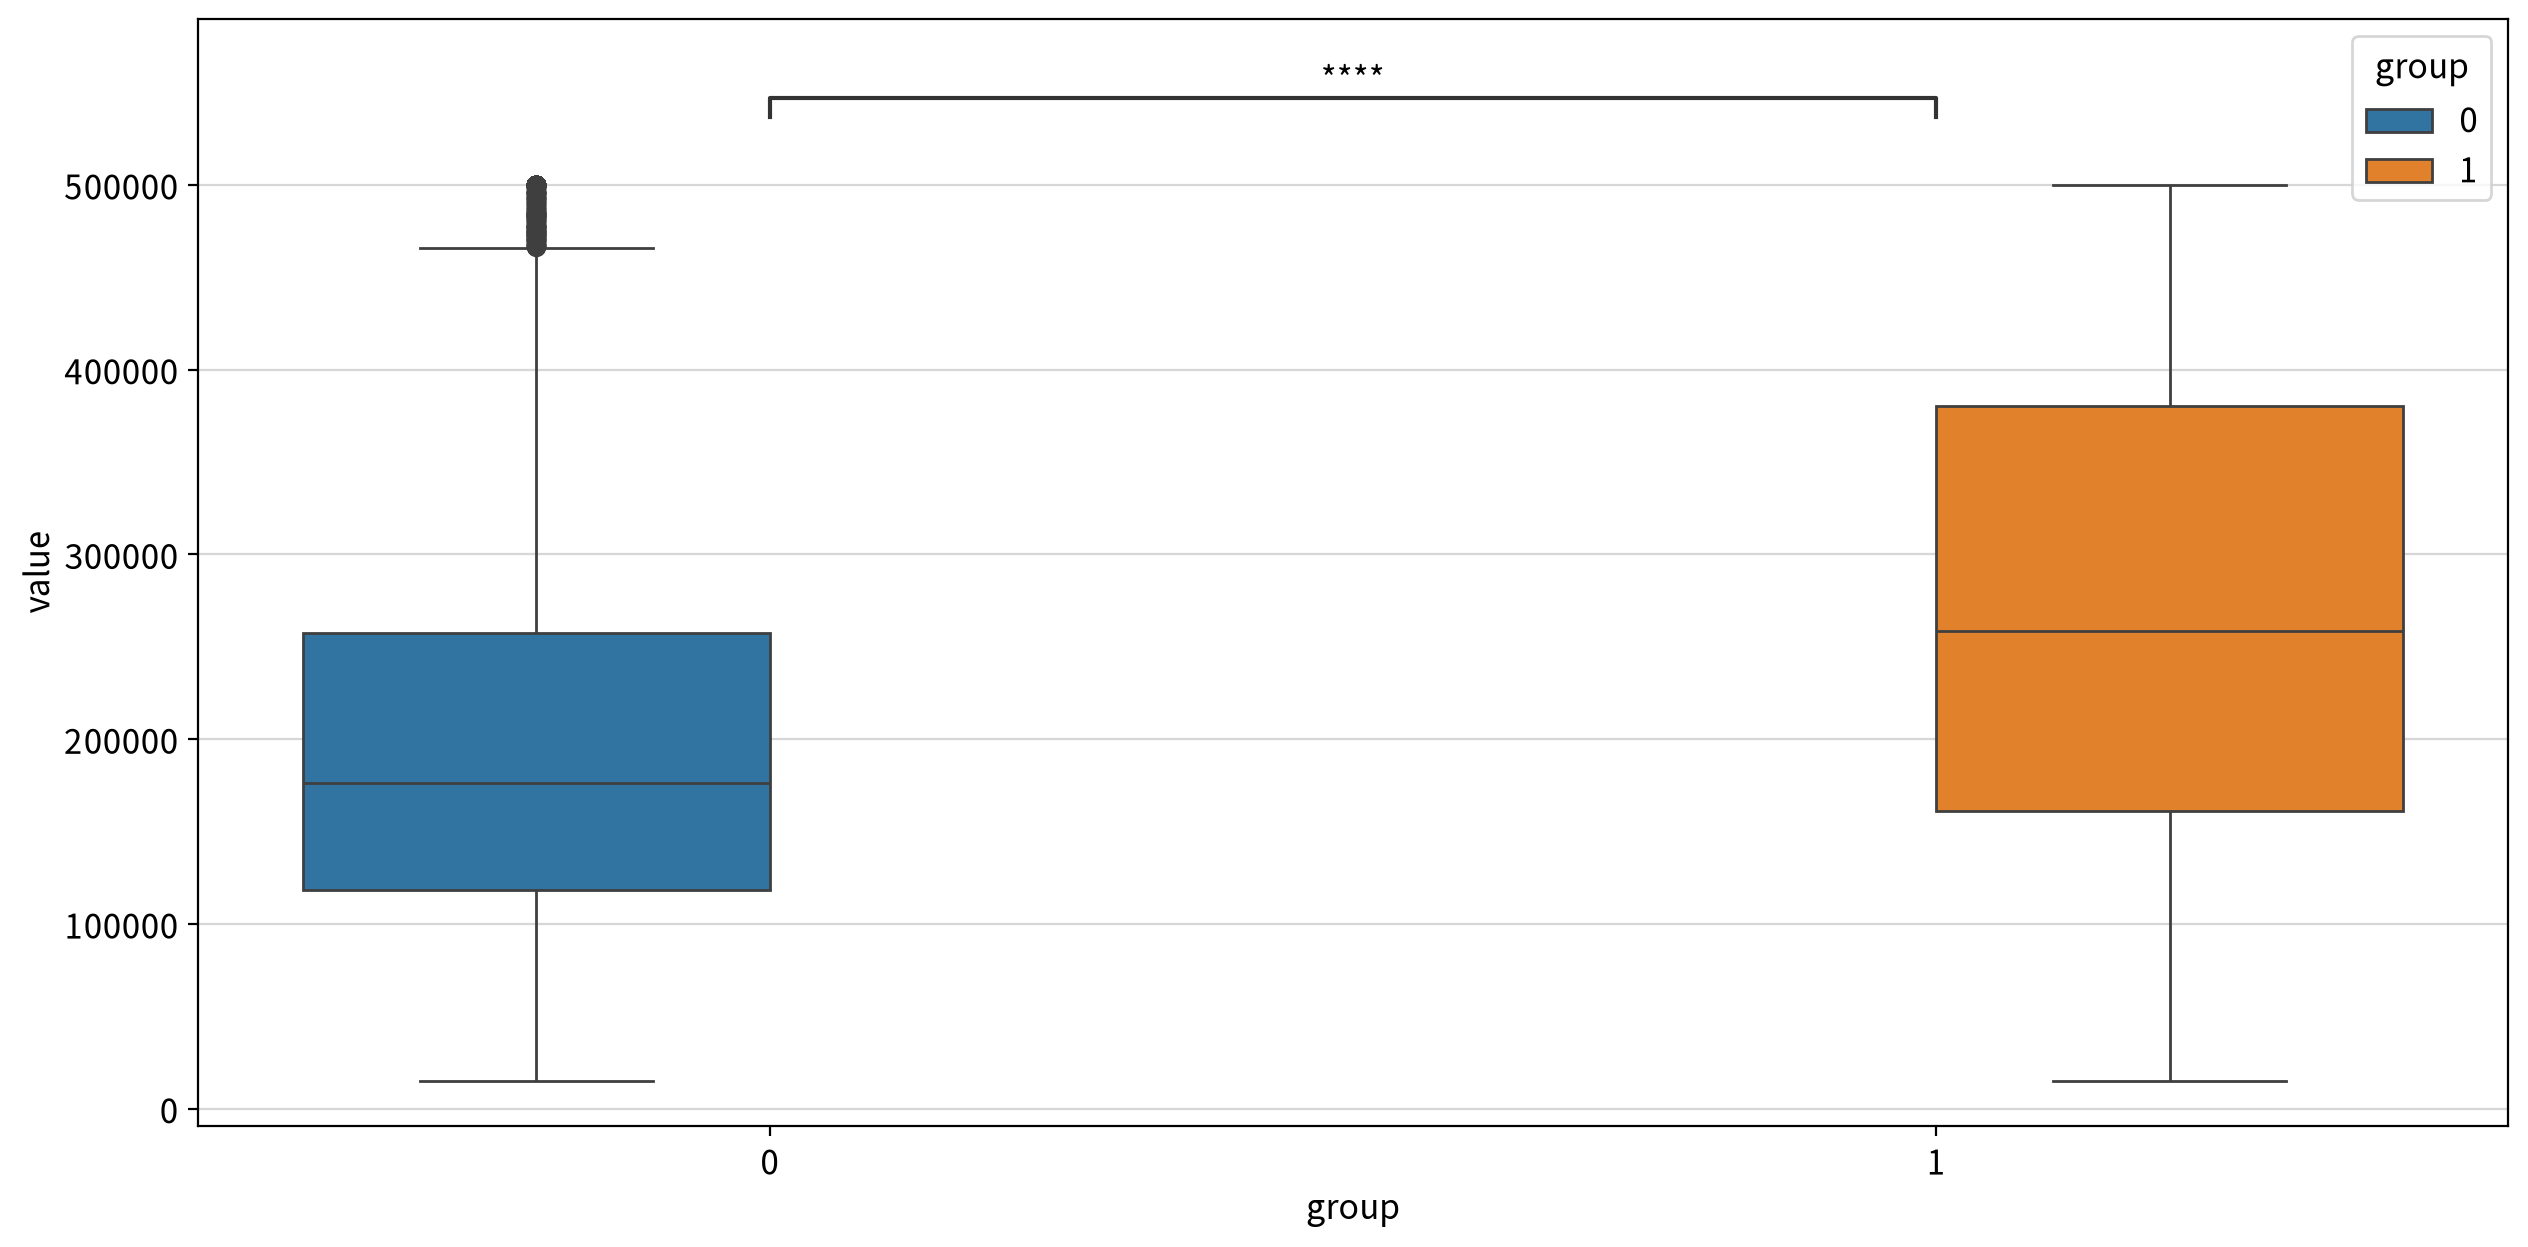

statistic  p-value  significant   result
test                alternative                                           
Mann-Whitney U test two-sided   8383512.000    0.000         True  0 =/= 1
                    less        8383512.000    0.000         True    0 < 1
                    greater     8383512.000    1.000        False   0 <= 1

#### -> is_income_capped(소득 상한 절단 여부) -> median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.829e-29 U_stat=4.007e+04


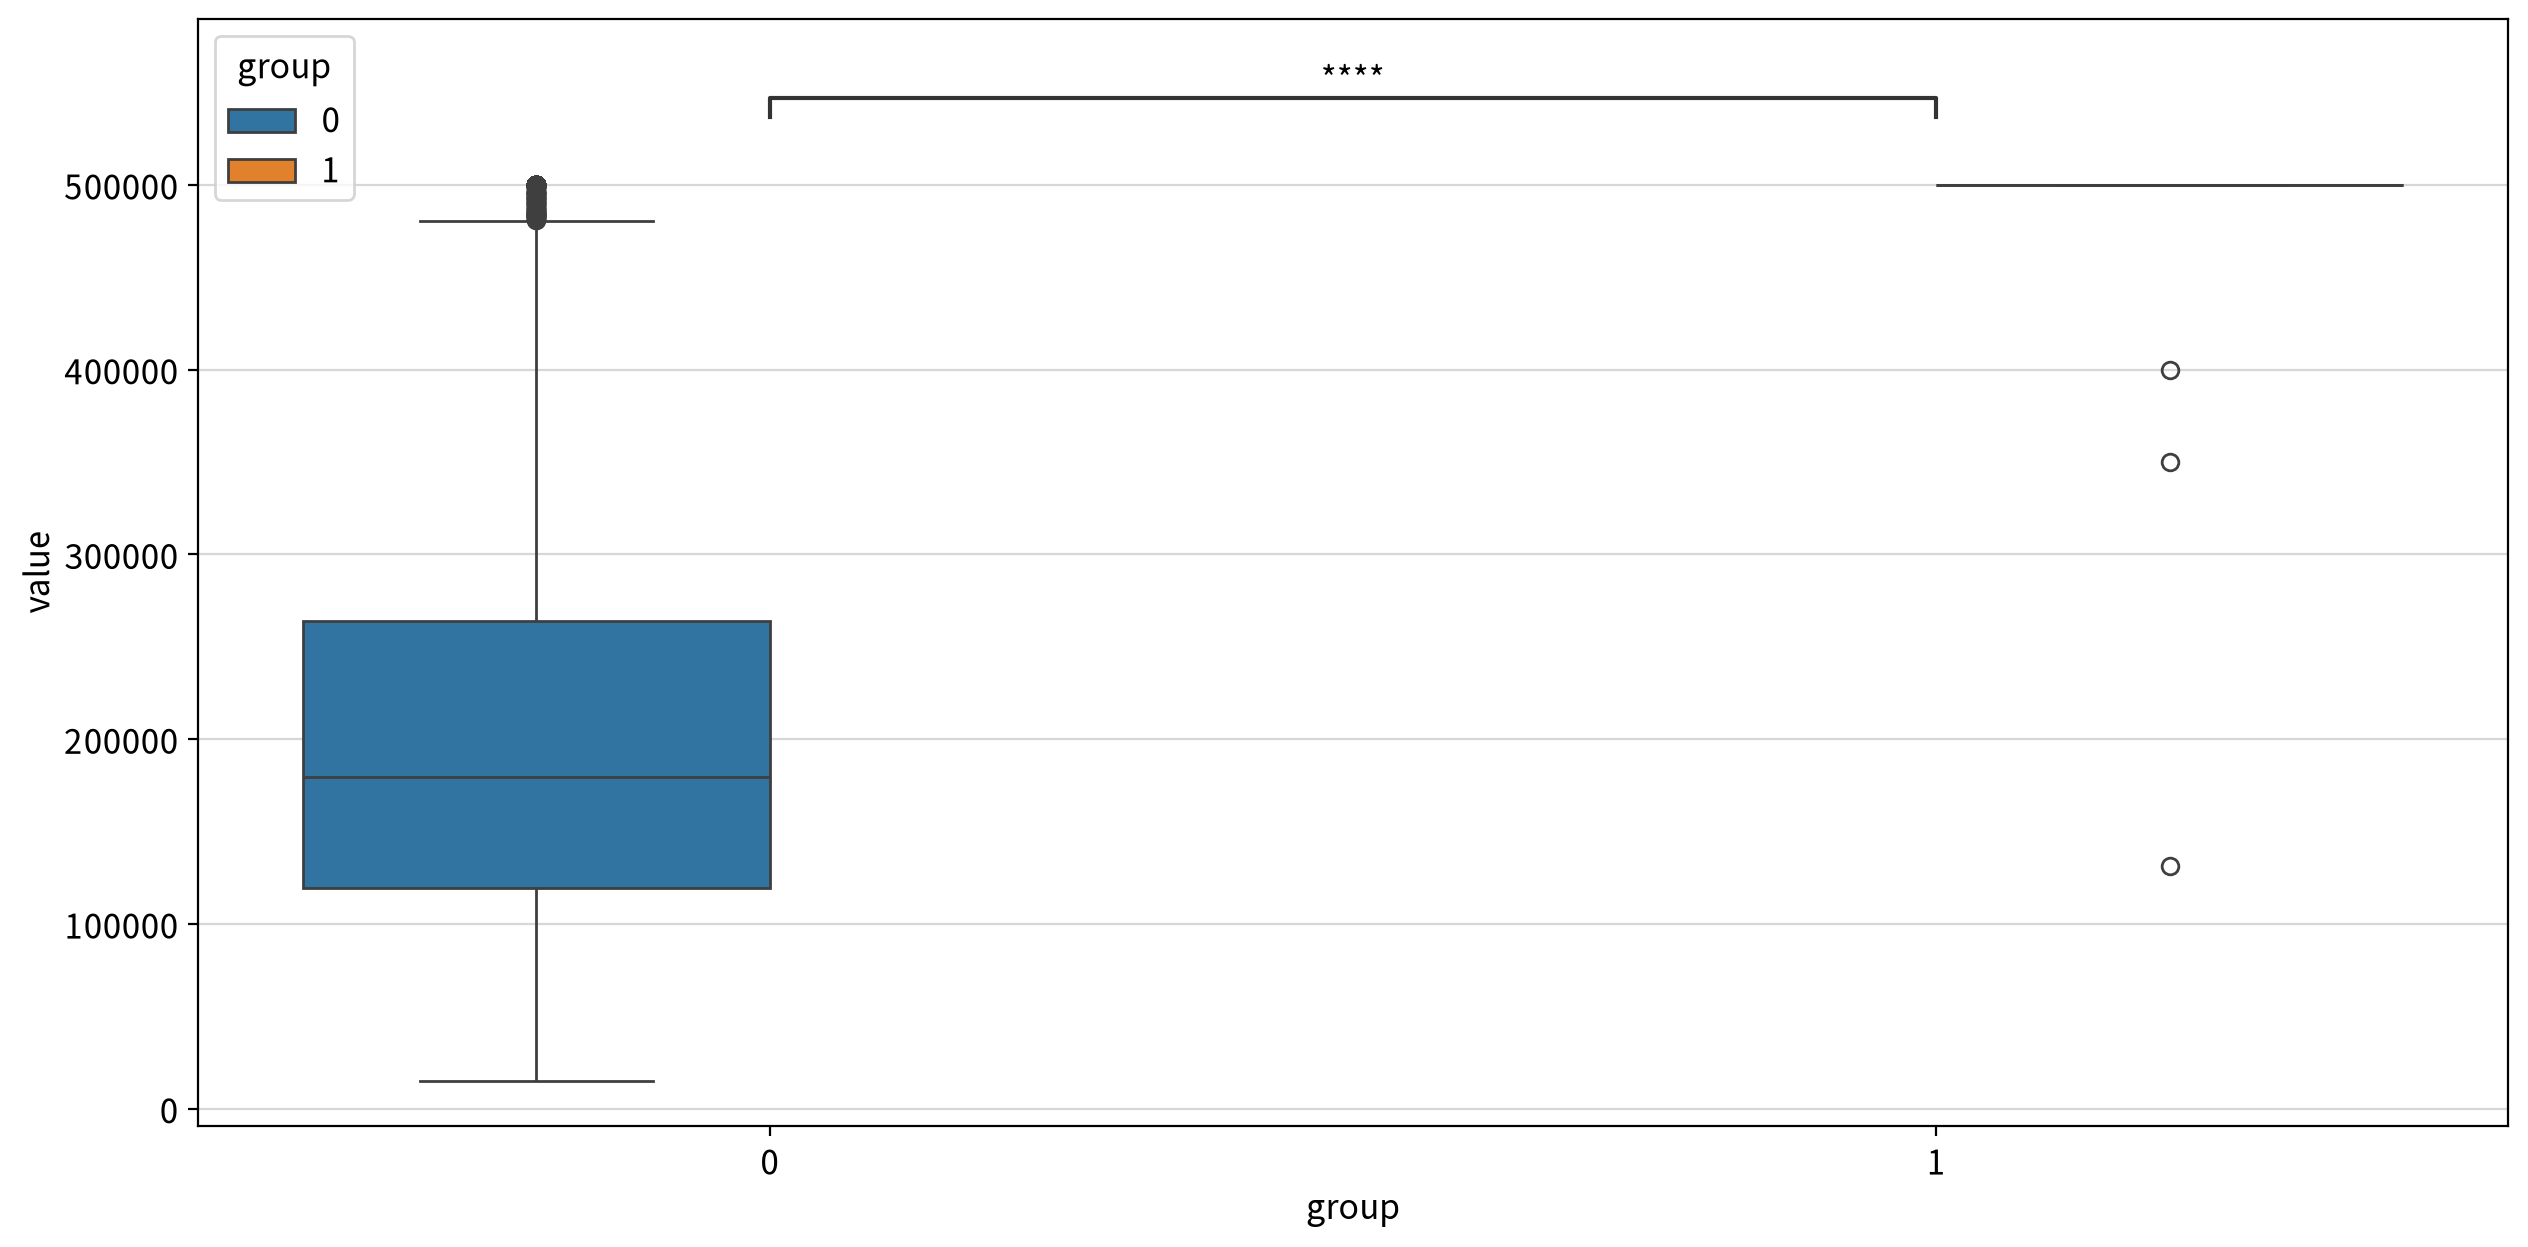

statistic  p-value  significant   result
test                alternative                                          
Mann-Whitney U test two-sided    40072.000    0.000         True  0 =/= 1
                    less         40072.000    0.000         True    0 < 1
                    greater      40072.000    1.000        False   0 <= 1

#### -> ocean_area(내륙/해안권 구분) -> median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

COASTAL vs. INLAND: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=7.704e+07


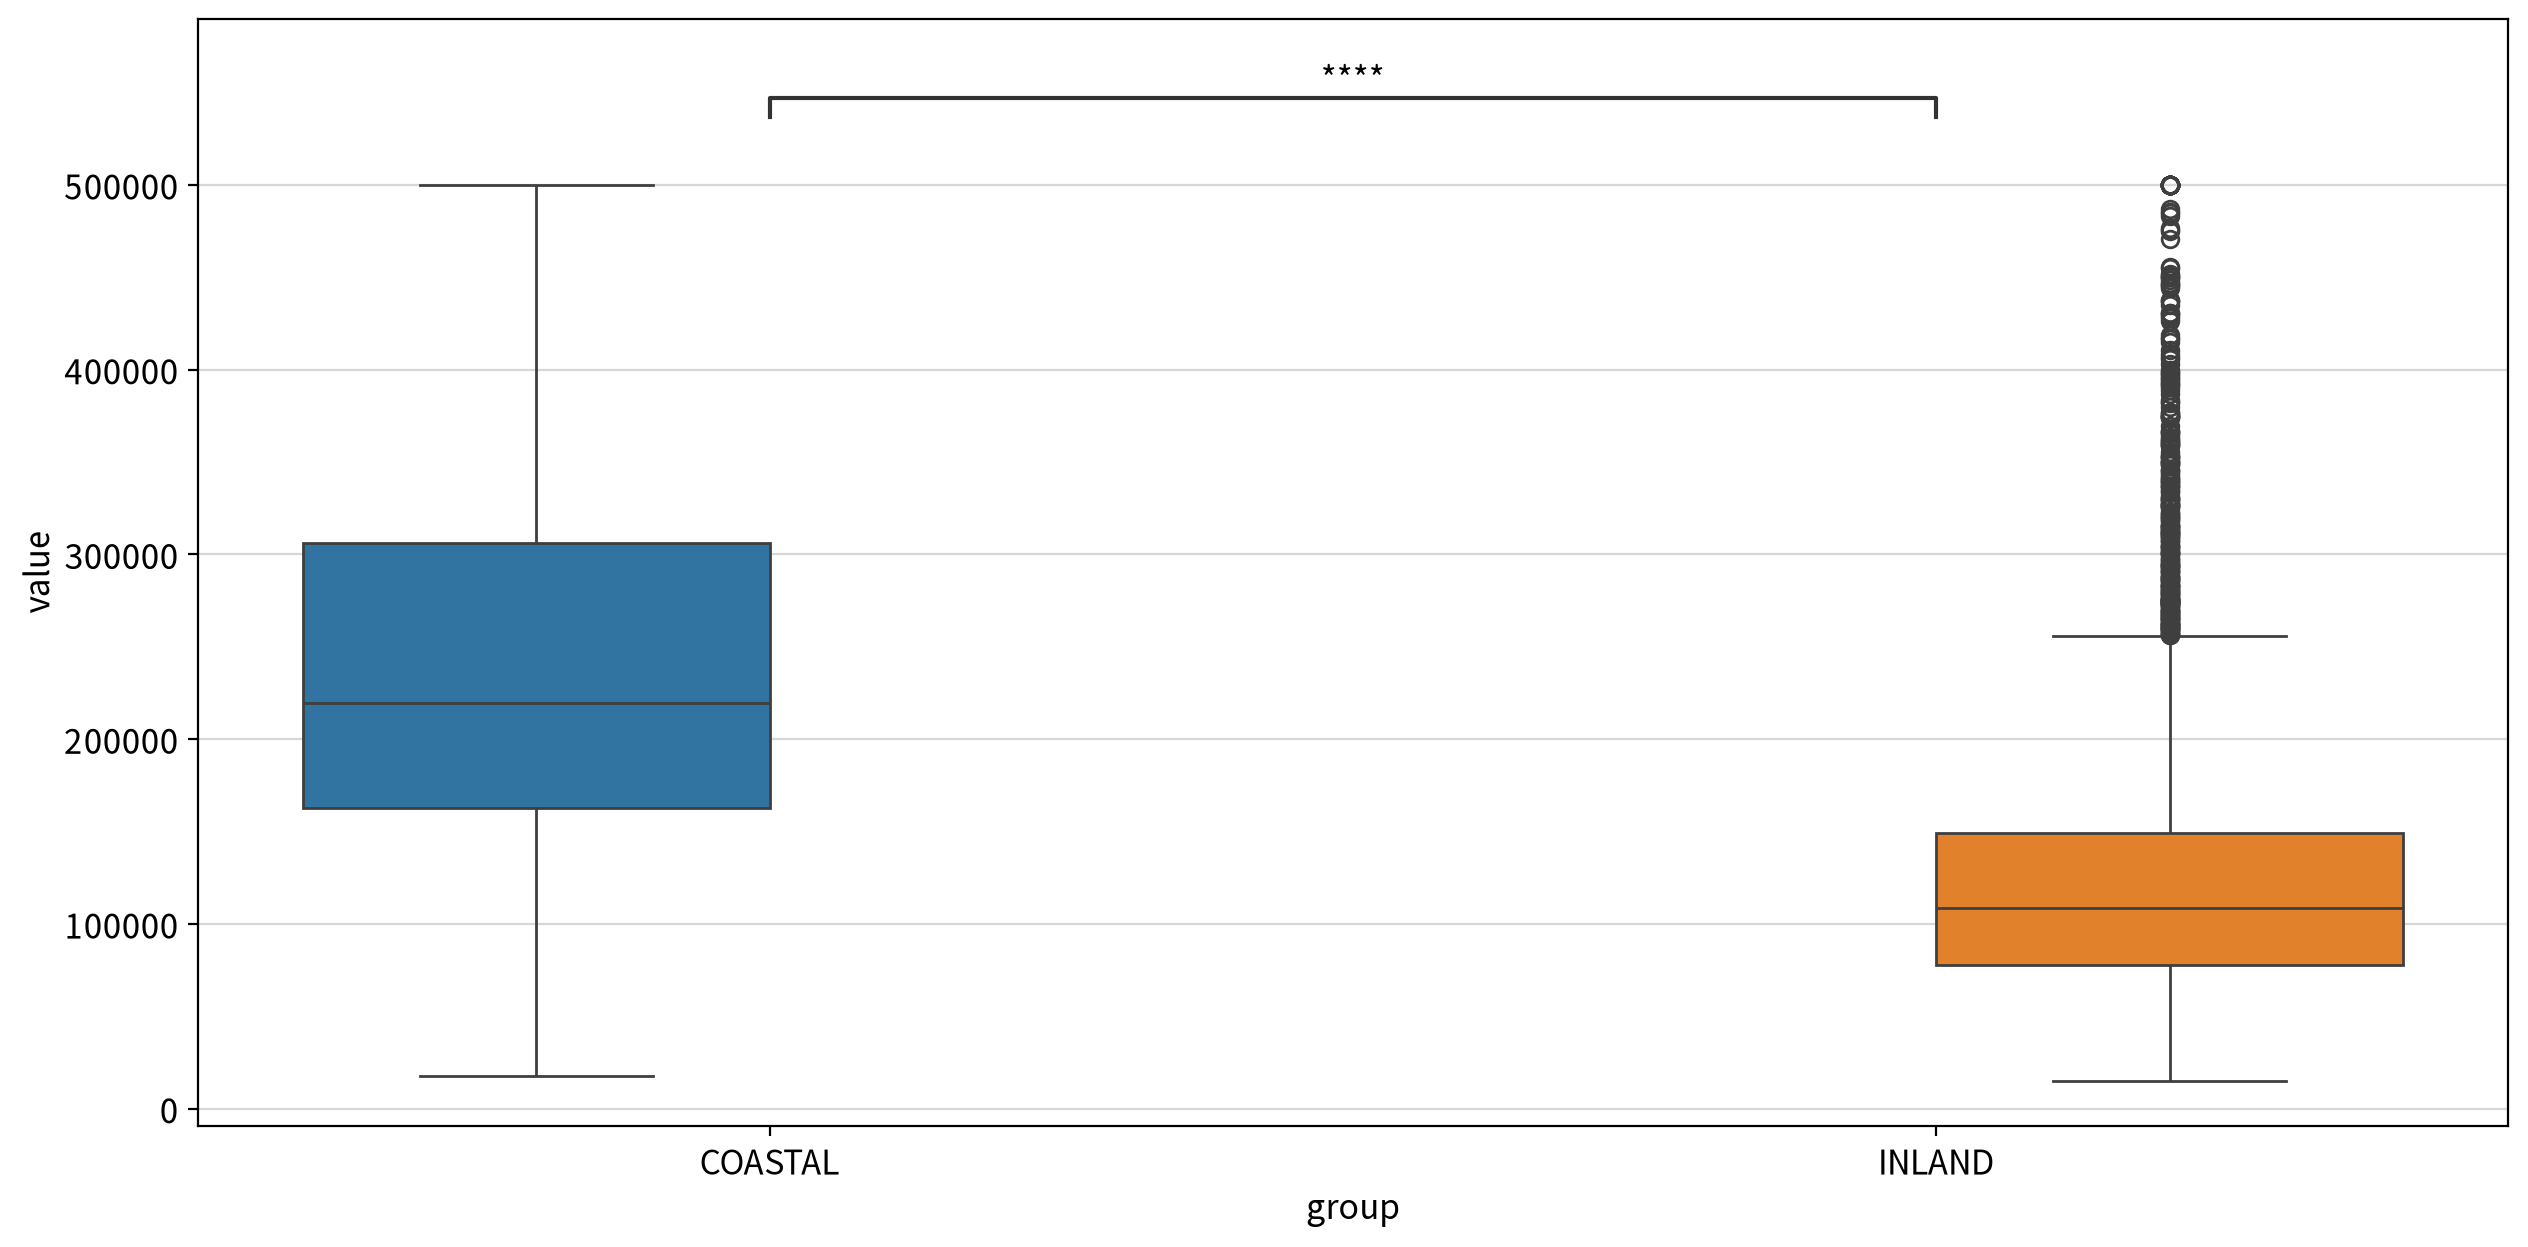

statistic  p-value  significant  \
test                alternative                                      
Mann-Whitney U test two-sided   77038278.500    0.000         True   
                    less        77038278.500    1.000        False   
                    greater     77038278.500    0.000         True   

                                             result  
test                alternative                      
Mann-Whitney U test two-sided    COASTAL =/= INLAND  
                    less          COASTAL >= INLAND  
                    greater        COASTAL > INLAND

In [28]:
for n in derived_nominal:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) ==2:
        # 빈 줄 출력용 
        print()

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))        
        

### 8. ANOVA (x:3집단이상 범주형 파생변수 -> y:종속변수)
앞에서 만든 공간정보 special_cluster가 대상이다 

In [29]:
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다. 
    if len(df[n].unique())>=3:
        print() # 빈 줄 출력용 

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # 분산분석 
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정 
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### -> special_cluster(위경도 기반 공간 군집) -> median_house_value

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,special_cluster,4,5508.155,2299.156,0.000,0.126,Medium


비교한 조합 쌍: 10개
유의한 쌍: 10개
평균 차이가 가장 큰 쌍: (0) vs (1)-> 차이 136984.354, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (1) vs (2)-> 차이 5907.012, 효과크기 Negligible, p-value 0.013


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,93638.609,230622.962,-136984.354,1643.444,-83.352,3961.218,0.000,-1.277,True,Large
1,Games-Howell,0,2,93638.609,224715.951,-131077.342,1802.992,-72.700,4815.611,0.000,-1.201,True,Large
2,Games-Howell,0,3,93638.609,177071.846,-83433.237,2347.525,-35.541,3095.476,0.000,-1.004,True,Large
3,Games-Howell,0,4,93638.609,121984.265,-28345.656,2429.515,-11.667,2529.102,0.000,-0.373,True,Small
4,Games-Howell,1,2,230622.962,224715.951,5907.012,1857.209,3.181,14257.849,0.013,0.052,True,Negligible
5,Games-Howell,1,3,230622.962,177071.846,53551.117,2389.418,22.412,3857.101,0.000,0.489,True,Small
6,Games-Howell,1,4,230622.962,121984.265,108638.697,2470.018,43.983,2998.000,0.000,0.995,True,Large
7,Games-Howell,2,3,224715.951,177071.846,47644.105,2501.838,19.044,4450.040,0.000,0.427,True,Small
8,Games-Howell,2,4,224715.951,121984.265,102731.686,2578.926,39.835,3464.306,0.000,0.923,True,Large
9,Games-Howell,3,4,177071.846,121984.265,55087.581,2985.122,18.454,3895.262,0.000,0.584,True,Medium



### 8. ANOVA (x: 3집단 이상 범주형 파생변수 → y: 종속변수) (결과 확인)
▶ special_cluster(위경도 기반 공간 군집) → median_house_value

| test | Source | ddof1 | ddof2 | F | p_unc | np2 | effect_size |
|---|---|---|---|---|---|---|---|
| 0 | welch_anova | special_cluster | 4 | 5508.155 | 2299.156 | 0.000 | 0.126 | Medium |

비교집단 조합 수: 10개
유의한 쌍: 10개
평균 차이가 가장 큰 쌍: (0) vs (1) → 차이 136984.354, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (1) vs (2) → 차이 5907.012, 효과크기 Negligible, p-value 0.013

| test | A | B | mean_A | mean_B | diff | se | T | df | pval | hedges | significant | effect_size |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Games-Howell | 0 | 1 | 93638.609 | 230622.962 | -136984.354 | 1643.444 | -83.352 | 3961.218 | 0.000 | -1.277 | True | Large |
| Games-Howell | 0 | 2 | 93638.609 | 177071.846 | -83433.237 | 1802.992 | -72.700 | 4815.611 | 0.000 | -1.201 | True | Large |
| Games-Howell | 0 | 3 | 93638.609 | 121984.265 | -28345.656 | 2347.525 | -35.541 | 3095.476 | 0.000 | -1.004 | True | Large |
| Games-Howell | 0 | 4 | 93638.609 | 121984.265 | -28345.656 | 2429.915 | -11.667 | 2529.102 | 0.000 | -0.373 | True | Small |
| Games-Howell | 1 | 2 | 230622.962 | 177071.846 | 53551.117 | 2389.418 | 22.412 | 14257.849 | 0.013 | 0.489 | True | Negligible |
| Games-Howell | 1 | 3 | 230622.962 | 121984.265 | 108638.697 | 2470.018 | 43.983 | 2998.000 | 0.000 | 0.995 | True | Small |
| Games-Howell | 2 | 3 | 177071.846 | 121984.265 | 47644.105 | 2501.838 | 19.034 | 4450.040 | 0.000 | 0.427 | True | Small |
| Games-Howell | 2 | 4 | 177071.846 | 121984.265 | 102731.686 | 2578.926 | 39.835 | 3466.306 | 0.000 | 0.923 | True | Large |
| Games-Howell | 3 | 4 | 121984.265 | 121984.265 | 55087.581 | 2985.122 | 18.454 | 3895.262 | 0.000 | 0.584 | True | Medium |

**유의하며 효과크기도 충분**
- Welch F=2,299.2 (p<0.001), np2=0.126(Medium)
- 좌표 두 개만 가지고 만든 단일 변수 집값 분산의 12.6%를 설명한다.

**사후검정 결과 10쌍이 모두 유의**
- 5개 군집이 서로 다른 가격대를 형성하고 있다는 의미
- Moran's I(0.790)가 실체를 가졌다. 인접한 주택끼리 가격이 비슷하다는 진단이 5개의 구체적인 시장 권역으로 번역됐고, 그 권역 구분이 통계적으로 확인됐다.

> EDA의 총량 4종(상호 ρ≥0.90) 보다는 나아졌지만 중복이 사라진 것은 아니다.
> 5종을 만들었어도 재료는 여전히 5개 원본 변수이므로, 어느 조합이든 분자나 분모를 공유한다.


### 9. 연속형 파생변수 간 상관분석 
재료가 같은 변수끼리는 겹칠 수 밖에 없다. 어느 정도인지 확인해 둔다. 

In [30]:
corr = my_stats.multi_correlation(df, columns=derived_continuous,plot=False)    
my_stats.correlation_summary(corr)

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
rooms_per_person,1.000,0.662,-0.542,-0.675,0.737
rooms_per_household,0.662,1.000,-0.888,0.018,0.536
bedrooms_per_room,-0.542,-0.888,1.000,-0.080,-0.599
population_per_household,-0.675,0.018,-0.080,1.000,-0.469
income_per_person,0.737,0.536,-0.599,-0.469,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms_per_room,rooms_per_household,-0.888,1,rooms_per_household
rooms_per_household,bedrooms_per_room,-0.888,1,bedrooms_per_room
income_per_person,rooms_per_person,0.737,1,rooms_per_person
rooms_per_person,income_per_person,0.737,1,income_per_person
population_per_household,rooms_per_person,-0.675,0,-



### □ 파생 변수 중 채택한 변수

| 채택 | 변수 | 검정방법 | 효과 | 비대칭 / 공선성 | 근거 |
|---|---|---|---|---|---|
| 채택 | income_per_person | Spearman | ρ=+0.722 (강함) | 우편향(+1.46)/log · O | 데이터셋 유일한 Strong. |
| 채택 | ocean_area | Mann-Whitney U | 평균차 120,172$ | 해당 없음·X | 5범주를 2범주로 줄이고도 EDA 수준의 집단 격차 유지 |
| 채택 | rooms_per_person | Spearman | ρ=+0.400 (보통) | 극단 우편향(+17.76)/log · O | 규모 축 대표. 원본 total_rooms(+0.205)의 2배 |
| 채택 | bedrooms_per_room | Spearman | ρ=−0.332 (보통) | 우편향(+2.25)/log · O | 파생 중 분포가 가장 안정. 총량으로 못 보던 음의 관계 |
| 채택 | special_cluster | Welch ANOVA | η²ₚ=0.126 | 해당 없음·△(V=0.411, 보완) | 내륙 내부를 η²ₚ=0.170(Large)으로 갈라내 ocean_area가 못 하던 구분 담당 |
| 후보 | is_age_capped | Mann-Whitney U | 평균차 73,051$ | 해당 없음·미점검 | housing_median_age(ρ=+0.075)가 못 잡던 신호. 6.2%로 검정력 충분 |
| 후보 | rooms_per_household | Spearman | ρ=+0.263 (약함) | 극단 우편향(+20.68)/log · O | bedrooms_per_room과 중복이 심해 둘 중 하나는 채택해야 함. VIF로 판단 |
| 후보 | population_per_household | Spearman | ρ=−0.256 (약함) | 최악(+97.16)/log · O | 설명력 최약이면서 분포도 최악. 우선 제거 후보 |
| 보류 | is_income_capped | Mann-Whitney U | 평균차 281,451$ | 해당 없음·미점검 | 차이는 크지만 n=50(0.2%) 추정 안정성이 낮아 투입 여부 재판단 필요 |

---

## # 종합 판단 (2/2)

### □ 원본 변수 중 제거할 변수
◎ 파생변수와 원본변수를 함께 모델링에 투입하면 정보가 중복되기 때문에 모델 성능이 지나치게 높게 나온다.
◎ 그러므로 원본 변수와 파생 변수 중에서 효과 강도가 더 높은 변수만 채택해야 한다.

| 제외 대상 | 이유 |
|---|---|
| total_rooms · total_bedrooms · population · households | 비율형 4종의 재료 |
| median_income | income_per_person의 재료. 파생 변수가 ρ=+0.722로 원본(+0.677)보다 효과 강도가 크다 |
| ocean_proximity | ocean_area 2범주로 병합됨 |
| longitude · latitude | 공간 정보는 special_cluster가 대신한다 |


## #07. 파생변수 데이터셋 저장 
### 1. 투입 변수 정리 

In [31]:
# 모형에 투입할 변수 (원본 1종 + 연속형 파생 5종 + 범주형 파생 4종)
feature_cols = [
    "housing_median_age", # 유지된 원본
    "rooms_per_person", # 연속형 파생변수
    "rooms_per_household", # 연속형 파생변수
    "bedrooms_per_room", # 연속형 파생변수
    "population_per_household", # 연속형 파생변수
    "income_per_person", # 연속형 파생변수
    "is_age_capped", # 범주형 파생 
    "is_income_capped", # 범주형 파생
    "ocean_area", # 범주형 파생 
    "special_cluster", # 공간정보 
]

print("투입 변수: ", len(feature_cols), "종\n")
print("투입 변수 목록: ", feature_cols)

투입 변수:  10 종

투입 변수 목록:  ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


### 2. 파생변수 데이터셋 저장 
로그 변환, 라벨링을 적용하기 전, 원 단위 그대로의 상태를 먼저 남긴다. 

In [32]:
# 저장 대상 = 투입변수 + 종속변수 
save_cols = feature_cols + [target]
print(save_cols)

# 변환할 변수만 추출
df_derived = df[save_cols]

# 범주형 변수 타입 변환 
df_derived = my_qtcheck.set_type(df_derived, as_category=["is_age_capped", 
                    "is_income_capped", "ocean_area", "special_cluster"])   

# 저장 
df_derived.to_excel("california_housing_features.xlsx", index=False)
print("저장 완료: ", df_derived.shape)

['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster', 'median_house_value']
<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age        20433 non-null  int64   
 1   rooms_per_person          20433 non-null  float64 
 2   rooms_per_household       20433 non-null  float64 
 3   bedrooms_per_room         20433 non-null  float64 
 4   population_per_household  20433 non-null  float64 
 5   income_per_person         20433 non-null  float64 
 6   is_age_capped             20433 non-null  category
 7   is_income_capped          20433 non-null  category
 8   ocean_area                20433 non-null  category
 9   special_cluster           20433 non-null  category
 1


## # 연속형 파생 5종 — 전부 유의, 강도는 두 배로

### □ 원본에 적용한 잣대를 그대로 적용 — Spearman 5종 모두 p=0.000

| 변수 | Spearman ρ | 강도 | 왜도 | 이상치 | 조치 |
|---|---|---|---|---|---|
| income_per_person | +0.722 | Strong | +1.46 | 616건(3.0%) | 그대로 |
| rooms_per_person | +0.400 | Moderate | +17.76 | 399건(2.0%) | 로그 변환 |
| bedrooms_per_room | −0.332 | Moderate | +2.25 | 582건(2.8%) | 로그 변환 |
| rooms_per_household | +0.263 | Weak | +20.68 | 508건(2.5%) | 로그 변환 |
| population_per_household | −0.256 | Weak | +97.16 | 709건(3.5%) | 로그 변환 |

**EDA 대비 — 약함이 아닌 변수 1종 → 3종**
- EDA는 6종 중 median_income(+0.677) 하나뿐이었다
- income_per_person +0.722는 이 데이터셋 유일의 Strong

**비유의 변수가 정보를 얻었다**
- population은 단독 비유의(p=0.681)
- 분모로 들어간 파생 2종은 모두 유의

**유일한 음의 관계**
- bedrooms_per_room −0.332
- 침실 비율이 낮을수록 비싸다 — 총량 변수로는 볼 수 없던 관계

> 설명력은 올랐지만 분포는 나빠졌다 — 왜도 +97.16은 로그 변환으로 넘긴다

---

## #범주형 파생 4종 — 격차는 크기만으로 채택되지 않는다

### □ 2집단 3종은 T-Test, 5범주 1종은 Welch ANOVA — 전부 유의, 판정은 갈린다

| 변수 | 구성 | 검정 | 효과 | 판정 |
|---|---|---|---|---|
| ocean_area | COASTAL 68.2% / INLAND 31.8% | T-Test | 평균차 120,172$ (245,069 vs 124,897) | 채택 |
| special_cluster | 5범주·최빈 42.7%/최소 4.8% | Welch ANOVA | np2=0.126(Medium)→통제 후 0.162(Large) | 채택 |
| is_age_capped | 1: 6.2% / 0: 93.8% | T-Test | 평균차 73,051$ (275,393 vs 202,342) | 채택 |
| is_income_capped | 1: 0.2%(50건) / 0: 99.8% | T-Test | 평균차 281,451$ (487,627 vs 206,176) | 보류 |

**병합해도 잃은 것이 없다**
- 5범주를 2범주로 줄인 뒤에도 EDA 수준의 집단 격차 유지
- COASTAL 245,069$가 병합 전 해안권 3종 평균 범위(240,268~259,279$) 안

**연속형이 못 잡던 신호**
- housing_median_age의 상관은 ρ=+0.075로 거의 없었다
- "52년으로 잘릴 만큼 오래된 동네"라는 표시가 7만$ 이상의 차이를 가른다

**보류 사유 — 크기가 아니라 표본**
- 평균차 28만$는 최대지만 n=50(0.2%)
- 그 차이를 50건으로 추정했다는 사실이 위험 — EDA의 ISLAND 5건과 같은 성격

> 공간 군집은 ocean_area와 겹치지 않는다 — 통제 후 Large 유지, 내륙 내부를 np2=0.170으로 갈라낸다

# 3-5. 로그변환, 라벨링 

## #08. 로그 변환 및 데이터 라벨링 
### 1. 변환 대상 확인 
기술통계량 표에서 로그변환 필요성 여부만 확인한다. 

In [33]:
feature_desc = my_qtcheck.numerical_summary(df_derived)
feature_desc['log_need'].T

housing_median_age          none
rooms_per_person             log
rooms_per_household          log
bedrooms_per_room            log
population_per_household     log
income_per_person            log
median_house_value           log
Name: log_need, dtype: str

### 2. 로그 변환 대상 추출 

In [34]:
# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x) : ", log_cols)
print("log(1+X) : ", log1p_cols)
print("반사 후 log : ", reflect_cols)

log(x) :  ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'median_house_value']
log(1+X) :  []
반사 후 log :  []


### 3. 독립변수 및 종속변수 로그 변환 


In [36]:
df_log = my_prep.log_transform(df_derived, 
                               log_columns=log_cols, 
                               log1p_columns=log1p_cols, 
                               reflect_columns=reflect_cols)

컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
rooms_per_person우측 꼬리     log(x)                exp(y)                  17.76 -> -0.73
rooms_per_household우측 꼬리     log(x)                exp(y)                   20.68 -> 0.88
bedrooms_per_room우측 꼬리     log(x)                exp(y)                    2.25 -> 0.54
population_per_household우측 꼬리     log(x)                exp(y)                   97.15 -> 2.14
income_per_person우측 꼬리     log(x)                exp(y)                   1.46 -> -0.55
median_house_value우측 꼬리     log(x)                exp(y)                   0.98 -> -0.17


### 4. 범주형 라벨링 

In [37]:
# 라벨링 대상 : category 타입인 범주형 파생변수
# -> 절단 플래그 2종은 이미 0/1 정수이므로 대상이 아니다. 
label_cols = ["ocean_area", "special_cluster"]

df_label = my_prep.labeling(df_log, columns=label_cols)

df_label[label_cols].head()

ocean_area (1종) : COASTAL=0
ocean_area (2종) : COASTAL=0, INLAND=1
special_cluster (1종) : 0=0
special_cluster (2종) : 0=0, 1=1
special_cluster (3종) : 0=0, 1=1, 2=2
special_cluster (4종) : 0=0, 1=1, 2=2, 3=3
special_cluster (5종) : 0=0, 1=1, 2=2, 3=3, 4=4


,ocean_area,special_cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


### 5. 최종 데이터셋 저장 

In [39]:
df_label.to_excel("california_housing_feature_log_labelled.xlsx", 
                  index=False)
print("저장 완료 : ", df_label.shape)
df_label.head()

저장 완료 :  (20433, 11)


,housing_median_age,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person,is_age_capped,is_income_capped,ocean_area,special_cluster,median_house_value
0,41,1.005,1.944,-1.920,0.938,1.181,0,0,0,2,13.023
1,21,1.084,1.831,-1.859,0.747,1.370,0,0,0,2,12.790
2,52,1.084,2.115,-2.044,1.030,0.952,1,0,0,2,12.772
3,52,0.826,1.761,-1.690,0.935,0.795,1,0,0,2,12.741
4,52,1.058,1.838,-1.760,0.780,0.567,1,0,0,2,12.743
